In [50]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [51]:
ls

'!round1 testing'/                  charts/
'Gemini Confidence Testing.ipynb'   charts_all_images/
 _baseline_gemini_2.5_flash/        charts_one_photo_testing.ipynb
 _best_gemini_2.5_flash/            dataset_metadata.csv
 _cdrl_gemini_2.5_flash/            distortion_images/
 _cove_gemini_2.5_flash/            gemini_beached_analysis.csv
 _far_gemini_2.5_flash/             hurt_animal_dataset_images/
 _metadata_gemini_2.5_flash/        hurt_animal_dataset_images_filtered/
 _ssot_gemini_2.5_flash/            hurt_dataset_metadata.csv
 animal_dataset_images/


In [52]:
# Output folder for charts
OUTPUT_FOLDER = "charts"

Path(OUTPUT_FOLDER).mkdir(exist_ok=True)


# Confidence Scores

In [53]:
def create_charts_hist(file_path):
    df = pd.read_csv(file_path)

    # Ensure probability column is numeric
    df["top1_prob"] = pd.to_numeric(df["top1_prob"], errors="coerce")

    #for testing
    acceptable_matches = {
        #sea turtles
        ("caretta caretta", "caretta caretta"),
        ("caretta caretta", "chelonia mydas"),
        ("caretta caretta", "mydas"),
        ("delphinus delphis", "delphinus capensis"),
        ("delphinus delphis", "delphis"),
        ("delphinus delphis", "lagenorhynchus albirostris"),
        ("delphinus delphis", "phocoena phocoena"),
        ("canis familiaris", "familiaris"),
        ("canis familiaris", "canis lupus familiaris"),
    }
    
    # Normalize
    actual = df["actual_species"].astype(str).str.lower().str.strip()
    pred = df["top1_species"].astype(str).str.lower().str.strip()
    
    # Accuracy check
    df["accurate"] = [
        (a == p) or ((a, p) in acceptable_matches)
        for a, p in zip(actual, pred)
    ]

    # Remove missing rows
    df = df.dropna(subset=["top1_prob", "distortion_level"])

    # Base filename
    stem = file_path.replace('_distribution_results.csv', '')
    species = df['actual_name'].drop_duplicates().tolist()[0]

    # =====================================================
    # 1. HISTOGRAM
    # =====================================================

    plt.figure(figsize=(10, 6))

    #distortion_levels = sorted(df["distortion_level"].unique())
    distortion_levels = [0, 1, 3, 5]
    # SAME bins for all histograms
    bins = np.linspace(
        df["top1_prob"].min(),
        df["top1_prob"].max(),
        25
    )

    # Different colors automatically from seaborn palette
    colors = sns.color_palette("tab10", len(distortion_levels))

    for color, level in zip(colors, distortion_levels):

        subset = df[df["distortion_level"] == level]

        plt.hist(
            subset["top1_prob"],
            bins=bins,
            alpha=0.5,
            label=f"Distortion {level}",
            color=color,
            edgecolor="black"
        )

    plt.xlabel("Top-1 Probability")
    plt.ylabel("Count")
    plt.title(f"Distribution of Top-1 Probability\n{stem} - {species}")

    plt.legend(title="Distortion Level")

    hist_output = Path(OUTPUT_FOLDER) / f"{stem}_histogram.png"

    #plt.savefig(hist_output, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()

    # =====================================================
    # 2. DUAL-AXIS LINE CHART
    # =====================================================

    # summary = (
    #     df.groupby("distortion_level")
    #     .agg(
    #         avg_top1_prob=("top1_prob", "mean"),
    #         accuracy=("accurate", "mean")
    #     )
    #     .reset_index()
    #     .sort_values("distortion_level")
    # )

    # fig, ax1 = plt.subplots(figsize=(10, 6))

    # # LEFT AXIS
    # line1 = ax1.plot(
    #     summary["distortion_level"],
    #     summary["avg_top1_prob"],
    #     marker="o",
    #     linewidth=2,
    #     color="blue",
    #     label="Average Top-1 Probability"
    # )

    # ax1.set_xlabel("Distortion Level")
    # ax1.set_ylabel("Average Top-1 Probability", color="blue")
    # ax1.tick_params(axis="y", labelcolor="blue")
    
    # # Force Left Axis Range (0 - 100)
    # ax1.set_ylim(0, 100)

    # # RIGHT AXIS
    # ax2 = ax1.twinx()

    # line2 = ax2.plot(
    #     summary["distortion_level"],
    #     summary["accuracy"],
    #     marker="s",
    #     linewidth=2,
    #     color="red",
    #     label="Accuracy"
    # )

    # ax2.set_ylabel("Accuracy", color="red")
    # ax2.tick_params(axis="y", labelcolor="red")
    
    # # Force Right Axis Range (0 - 1)
    # ax2.set_ylim(0, 1)

    # # Combined legend
    # lines = line1 + line2
    # labels = [line.get_label() for line in lines]

    # ax1.legend(lines, labels, loc="best")

    # plt.title(f"Average Top-1 Probability and Accuracy\n{stem} - {species}")

    # line_output = Path(OUTPUT_FOLDER) / f"{stem}_dual_axis.png"

    # #plt.savefig(line_output, bbox_inches="tight", dpi=300)
    # plt.show()
    # plt.close()

    # print(f"Saved:")
    # print(f"  {hist_output}")
    # print(f"  {line_output}")

In [55]:
def create_charts_line(file_path):
    df = pd.read_csv(file_path)

    # Ensure probability column is numeric
    df["top1_prob"] = pd.to_numeric(df["top1_prob"], errors="coerce")

    #for testing
    acceptable_matches = {
        #sea turtles
        ("caretta caretta", "caretta caretta"),
        ("caretta caretta", "chelonia mydas"),
        ("caretta caretta", "mydas"),
        ("delphinus delphis", "delphinus capensis"),
        ("delphinus delphis", "delphis"),
        ("delphinus delphis", "lagenorhynchus albirostris"),
        ("delphinus delphis", "phocoena phocoena"),
        ("canis familiaris", "familiaris"),
        ("canis familiaris", "canis lupus familiaris"),
    }
    
    # Normalize
    actual = df["actual_species"].astype(str).str.lower().str.strip()
    pred = df["top1_species"].astype(str).str.lower().str.strip()
    
    # Accuracy check
    df["accurate"] = [
        (a == p) or ((a, p) in acceptable_matches)
        for a, p in zip(actual, pred)
    ]

    # Remove missing rows
    df = df.dropna(subset=["top1_prob", "distortion_level"])

    # Base filename
    stem = file_path.replace('_distribution_results.csv', '')
    species = df['actual_name'].drop_duplicates().tolist()[0]

    # # =====================================================
    # # 1. HISTOGRAM
    # # =====================================================

    # plt.figure(figsize=(10, 6))

    # #distortion_levels = sorted(df["distortion_level"].unique())
    # distortion_levels = [0, 1, 3, 5]
    # # SAME bins for all histograms
    # bins = np.linspace(
    #     df["top1_prob"].min(),
    #     df["top1_prob"].max(),
    #     25
    # )

    # # Different colors automatically from seaborn palette
    # colors = sns.color_palette("tab10", len(distortion_levels))

    # for color, level in zip(colors, distortion_levels):

    #     subset = df[df["distortion_level"] == level]

    #     plt.hist(
    #         subset["top1_prob"],
    #         bins=bins,
    #         alpha=0.5,
    #         label=f"Distortion {level}",
    #         color=color,
    #         edgecolor="black"
    #     )

    # plt.xlabel("Top-1 Probability")
    # plt.ylabel("Count")
    # plt.title(f"Distribution of Top-1 Probability\n{stem} - {species}")

    # plt.legend(title="Distortion Level")

    # hist_output = Path(OUTPUT_FOLDER) / f"{stem}_histogram.png"

    # #plt.savefig(hist_output, bbox_inches="tight", dpi=300)
    # plt.show()
    # plt.close()

    # =====================================================
    # 2. DUAL-AXIS LINE CHART
    # =====================================================

    summary = (
        df.groupby("distortion_level")
        .agg(
            avg_top1_prob=("top1_prob", "mean"),
            accuracy=("accurate", "mean")
        )
        .reset_index()
        .sort_values("distortion_level")
    )

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # LEFT AXIS
    line1 = ax1.plot(
        summary["distortion_level"],
        summary["avg_top1_prob"],
        marker="o",
        linewidth=2,
        color="blue",
        label="Average Top-1 Probability"
    )

    ax1.set_xlabel("Distortion Level")
    ax1.set_ylabel("Average Top-1 Probability", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    
    # Force Left Axis Range (0 - 100)
    ax1.set_ylim(0, 100)

    # RIGHT AXIS
    ax2 = ax1.twinx()

    line2 = ax2.plot(
        summary["distortion_level"],
        summary["accuracy"],
        marker="s",
        linewidth=2,
        color="red",
        label="Accuracy"
    )

    ax2.set_ylabel("Accuracy", color="red")
    ax2.tick_params(axis="y", labelcolor="red")
    
    # Force Right Axis Range (0 - 1)
    ax2.set_ylim(0, 1)

    # Combined legend
    lines = line1 + line2
    labels = [line.get_label() for line in lines]

    ax1.legend(lines, labels, loc="best")

    plt.title(f"Average Top-1 Probability and Accuracy\n{stem} - {species}")

    line_output = Path(OUTPUT_FOLDER) / f"{stem}_dual_axis.png"

    #plt.savefig(line_output, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()


In [59]:
def create_charts_accuracy(file_path):
    df = pd.read_csv(file_path)

    # Ensure probability column is numeric
    df["top1_prob"] = pd.to_numeric(df["top1_prob"], errors="coerce")

    #for testing
    acceptable_matches = {
        #sea turtles
        ("caretta caretta", "caretta caretta"),
        ("caretta caretta", "chelonia mydas"),
        ("caretta caretta", "mydas"),
        ("delphinus delphis", "delphinus capensis"),
        ("delphinus delphis", "delphis"),
        ("delphinus delphis", "lagenorhynchus albirostris"),
        ("delphinus delphis", "phocoena phocoena"),
        ("canis familiaris", "familiaris"),
        ("canis familiaris", "canis lupus familiaris"),
    }
    
    # Normalize
    actual = df["actual_species"].astype(str).str.lower().str.strip()
    pred = df["top1_species"].astype(str).str.lower().str.strip()
    
    # Accuracy check
    df["accurate"] = [
        (a == p) or ((a, p) in acceptable_matches)
        for a, p in zip(actual, pred)
    ]

    # Remove missing rows
    df = df.dropna(subset=["top1_prob", "distortion_level"])

    # Base filename
    stem = file_path.replace('_distribution_results.csv', '')
    species = df['actual_name'].drop_duplicates().tolist()[0]


    # =====================================================
    # Accuracy by decile
    # =====================================================

        # Convert accurate to int
    df['accurate'] = df['accurate'].astype(int)
    
    # Create bins
    df['prob_decile'] = pd.cut(df['top1_prob'], bins=range(0, 101, 10), labels=[f"{i}-{i+10}" for i in range(0, 100, 10)])
    
    # Calculate accuracy
    accuracy_by_decile = df.groupby('prob_decile', observed=False)['accurate'].mean()
    
    # Plot
    plt.figure(figsize=(10, 6))
    accuracy_by_decile.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.xlabel('Top1 Probability Decile (%)')
    plt.ylabel('Accuracy (Mean)')
    plt.title('Accuracy by Top1 Probability Decile')
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.title(f"Average Top-1 Accuracy by Confidence\n{stem} - {species}")

    plt.show()
    plt.close()


361231332
_baseline_gemini_2.5_flash


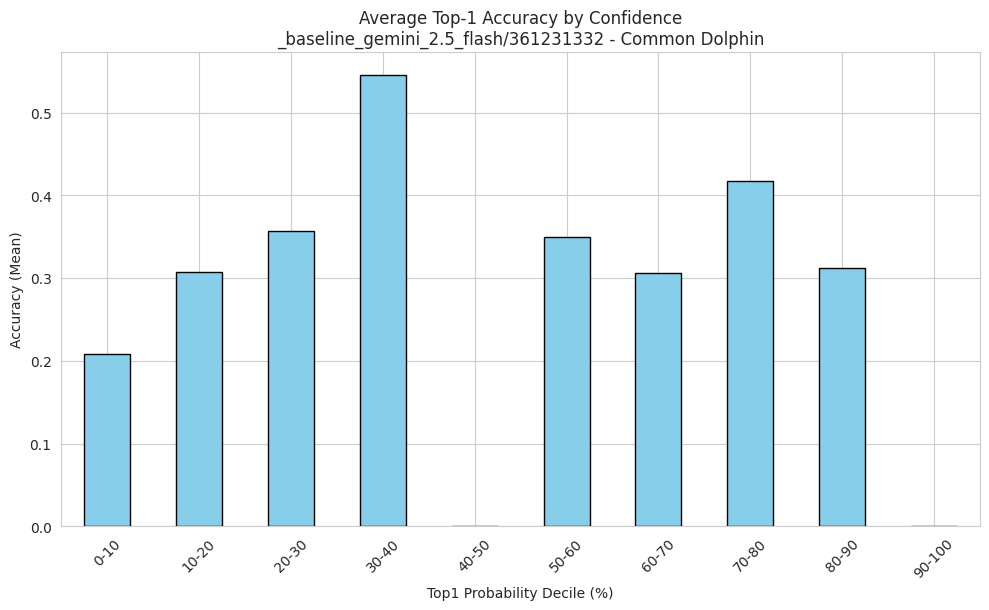





_metadata_gemini_2.5_flash


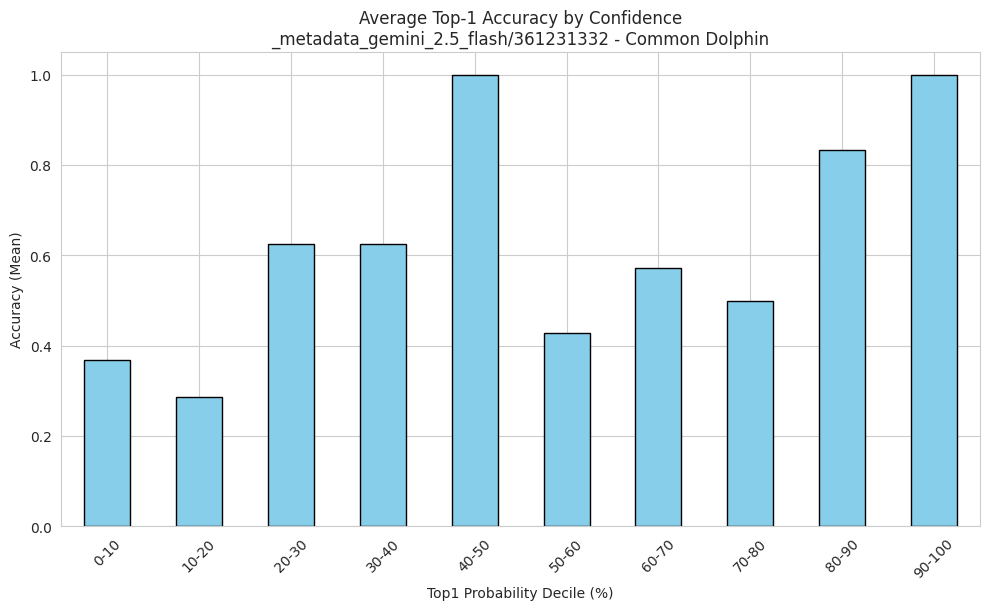





_ssot_gemini_2.5_flash


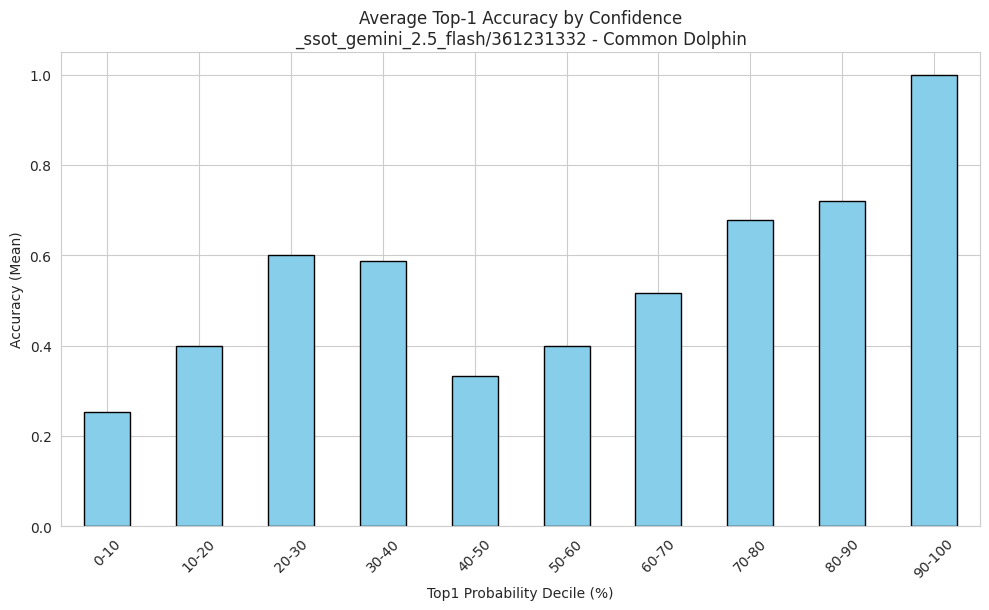





_cdrl_gemini_2.5_flash


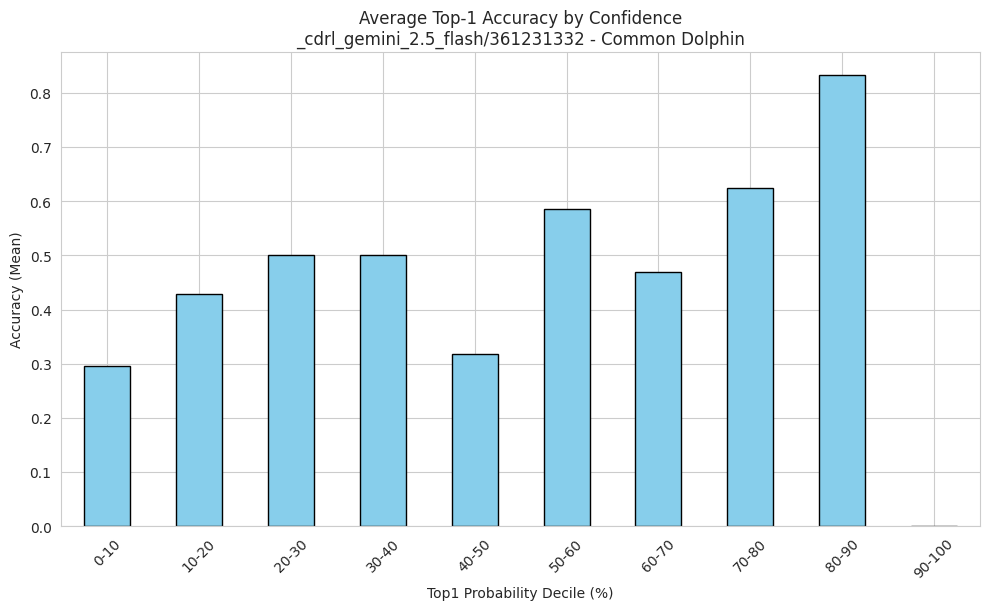





_far_gemini_2.5_flash


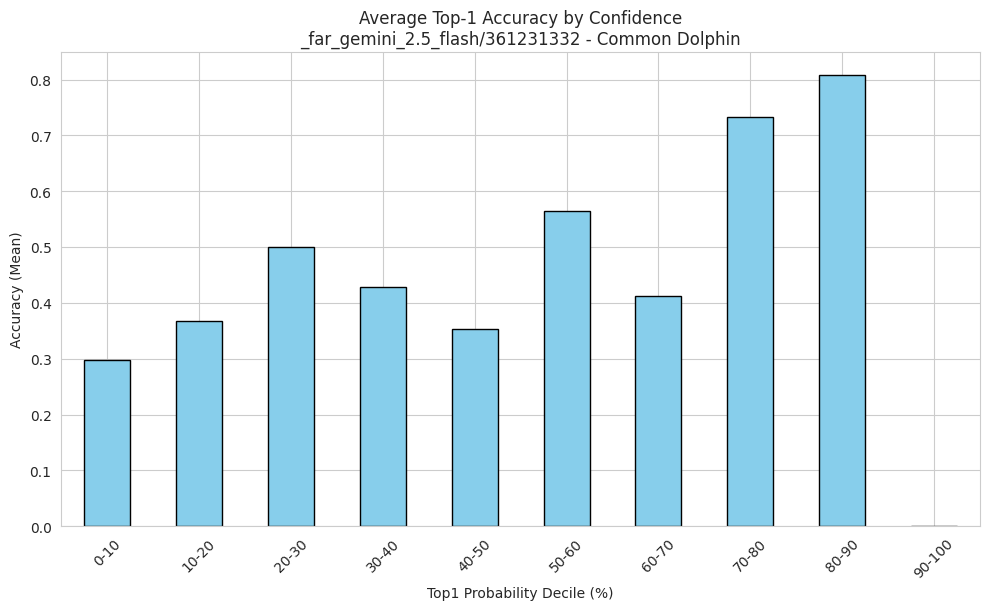





_cove_gemini_2.5_flash


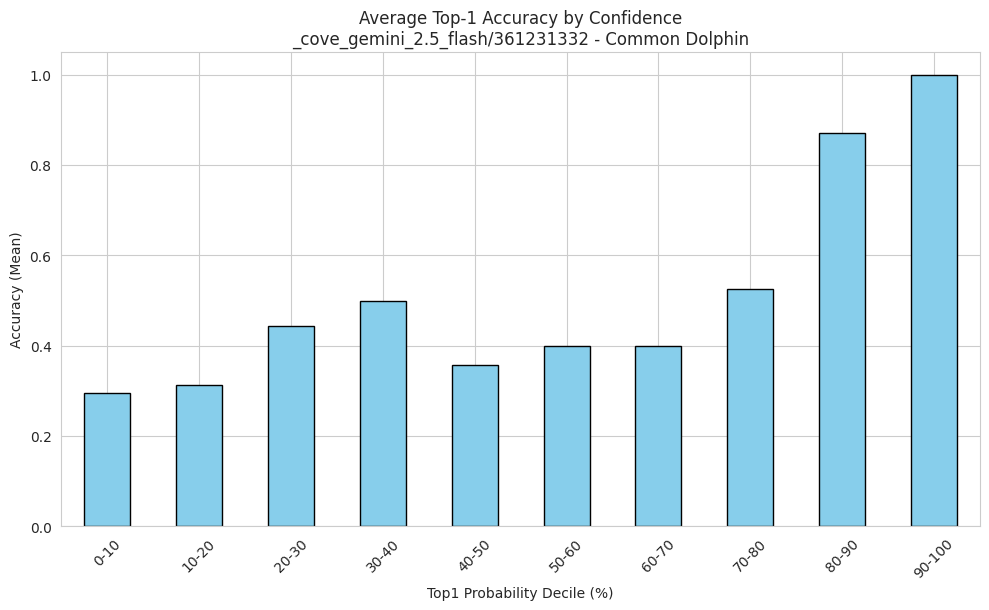





_best_gemini_2.5_flash


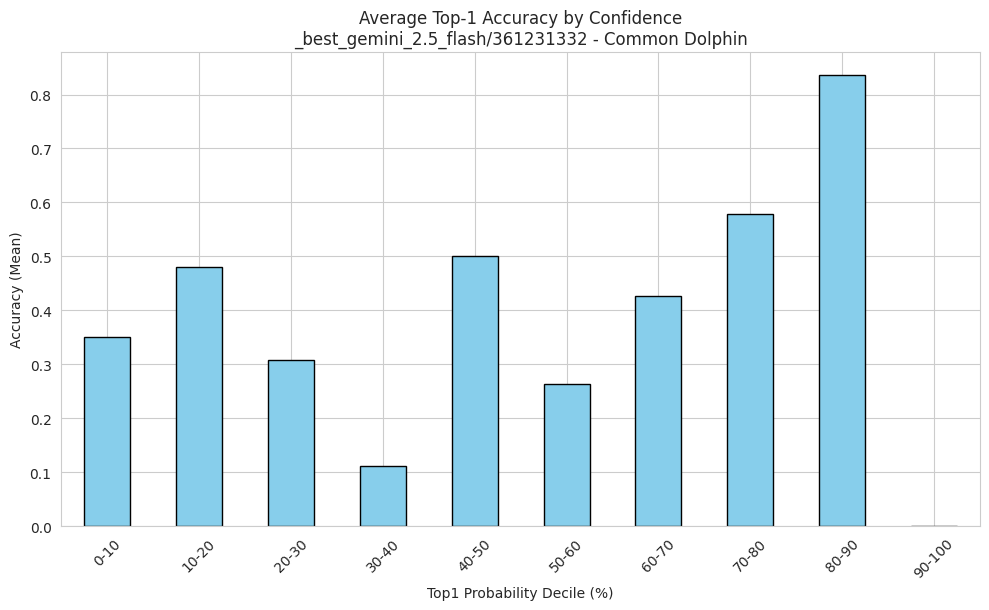





362234822
_baseline_gemini_2.5_flash


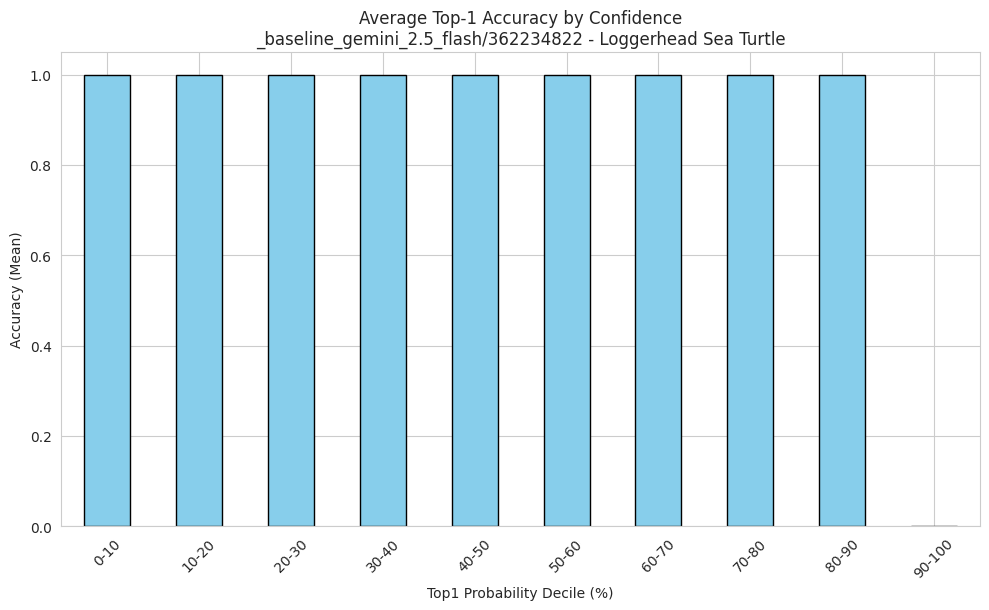





_metadata_gemini_2.5_flash


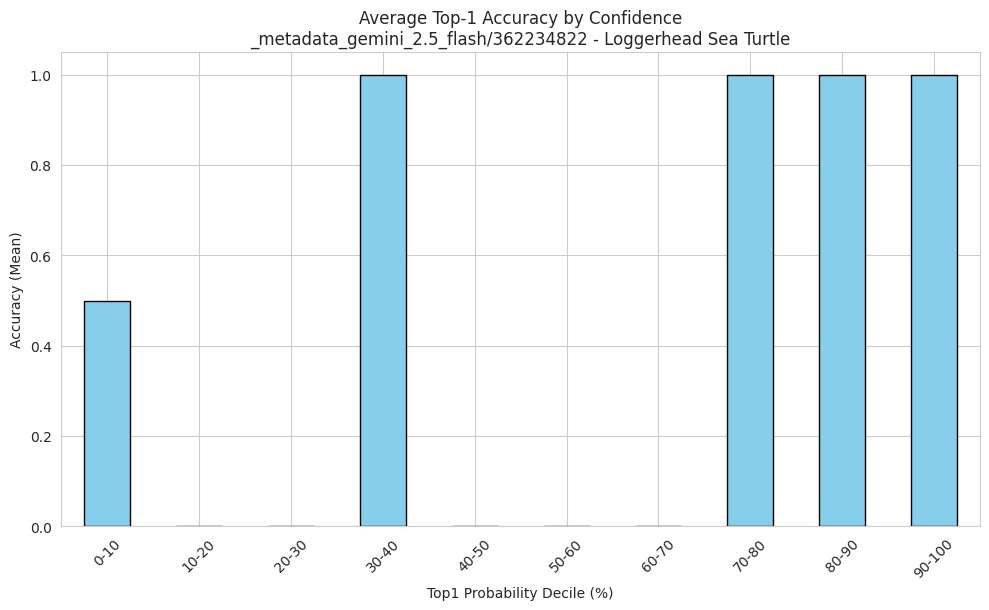





_ssot_gemini_2.5_flash


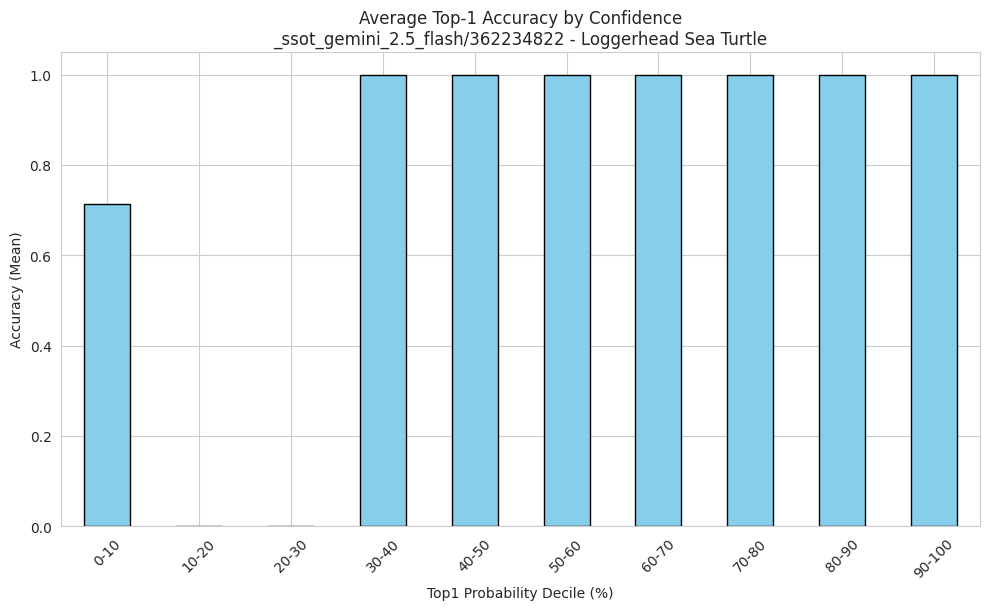





_cdrl_gemini_2.5_flash


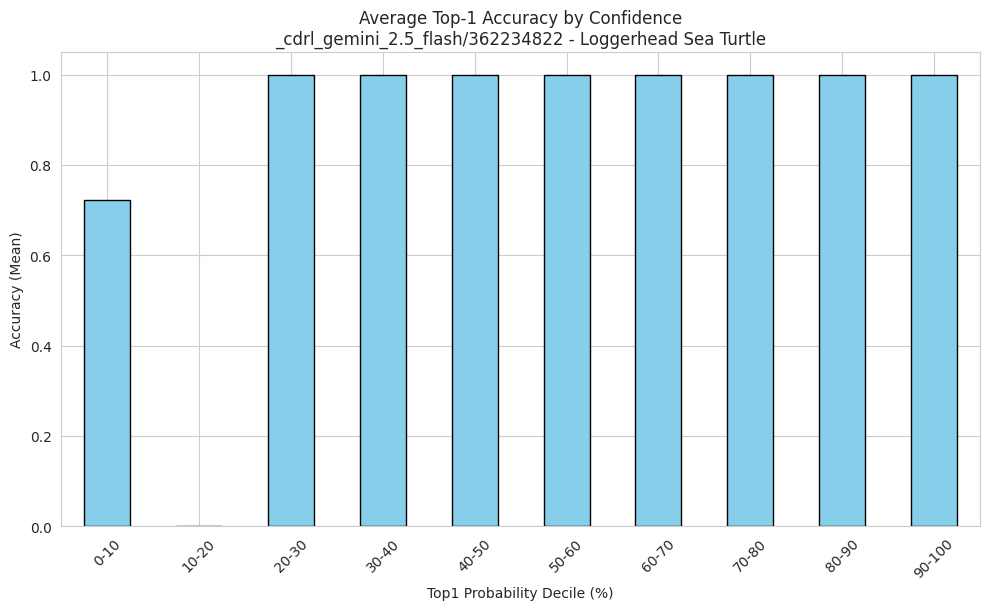





_far_gemini_2.5_flash


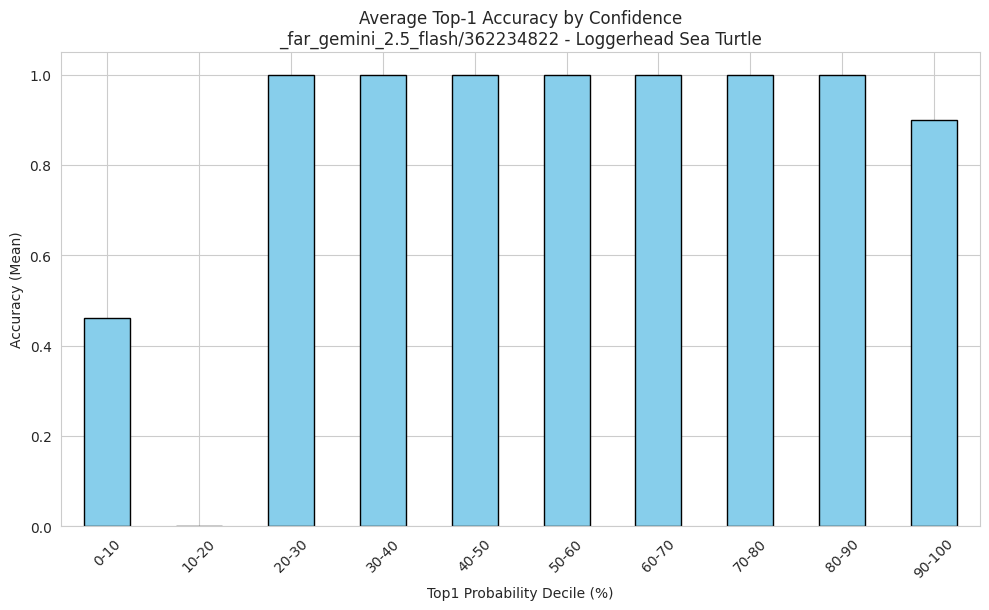





_cove_gemini_2.5_flash


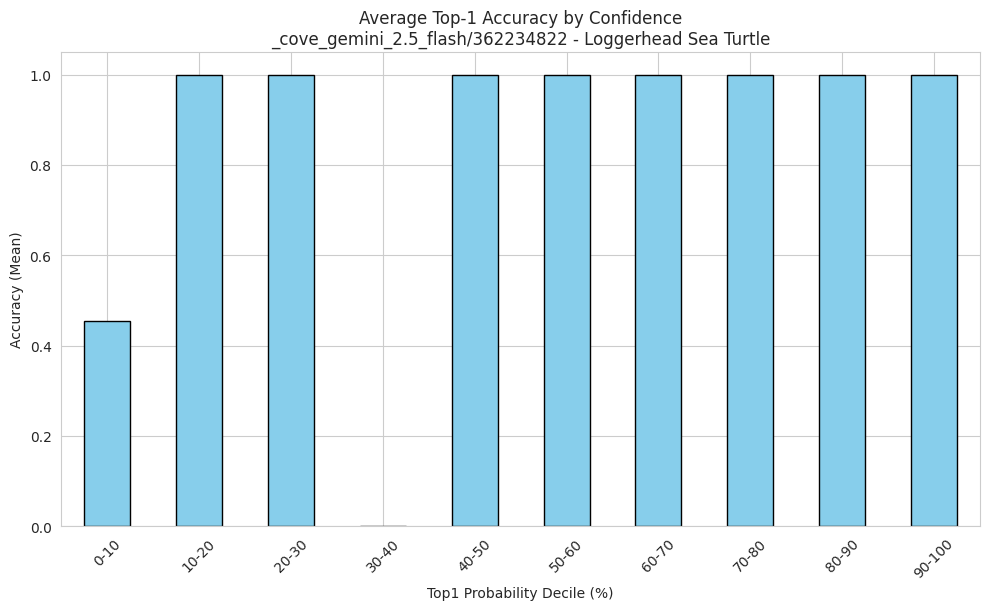





_best_gemini_2.5_flash


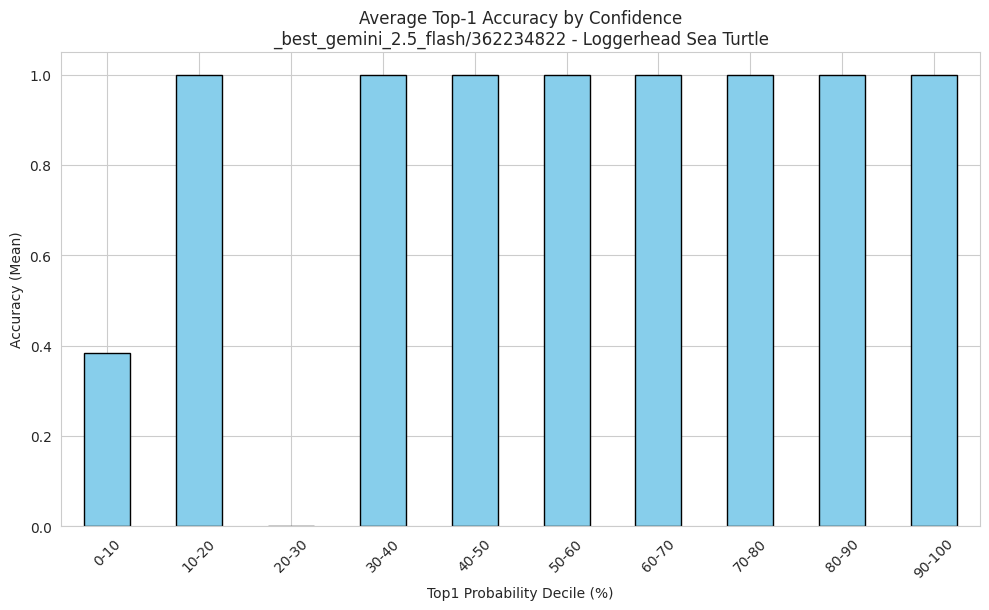





362471929
_baseline_gemini_2.5_flash


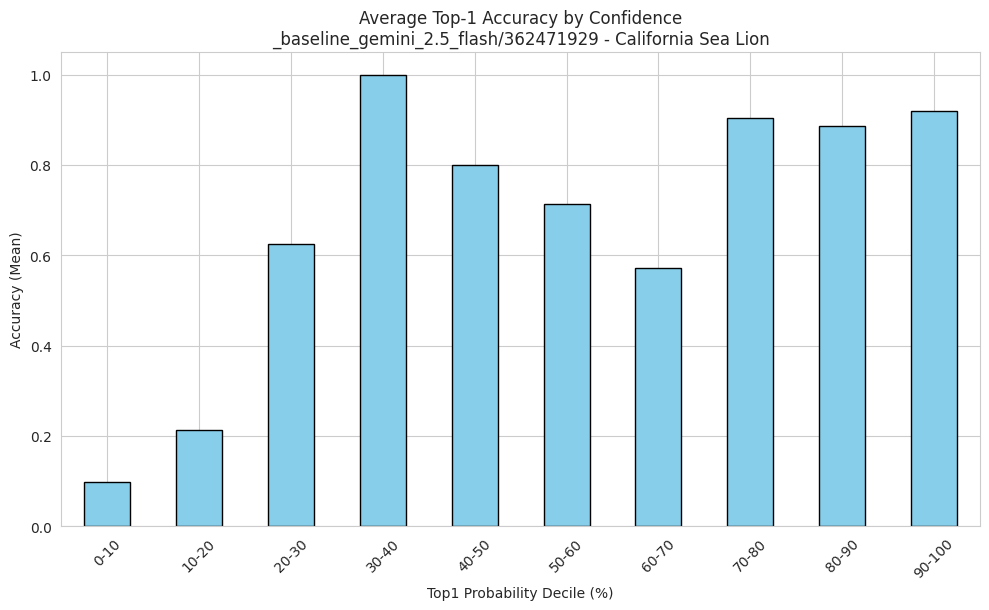





_metadata_gemini_2.5_flash


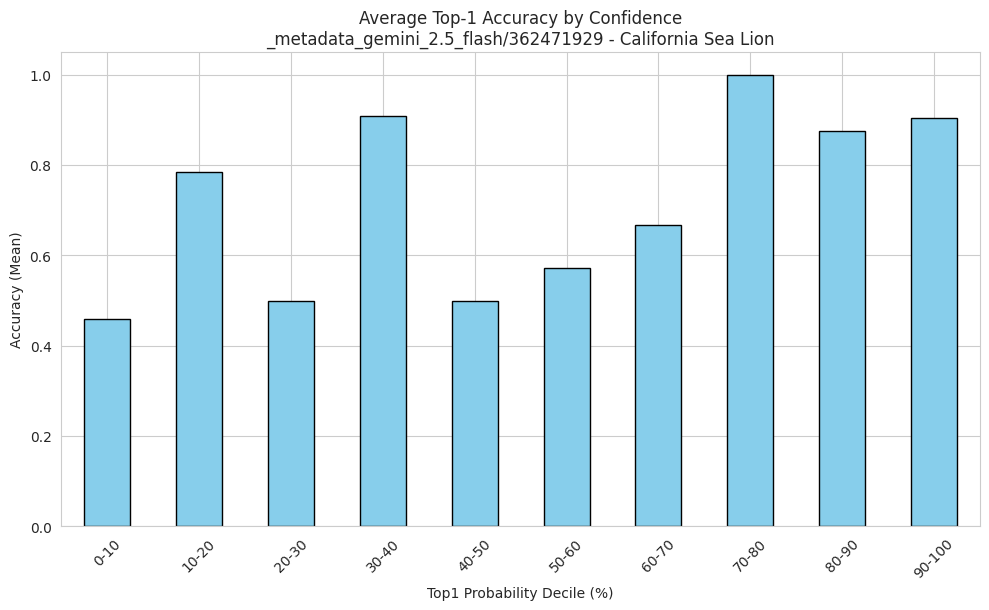





_ssot_gemini_2.5_flash


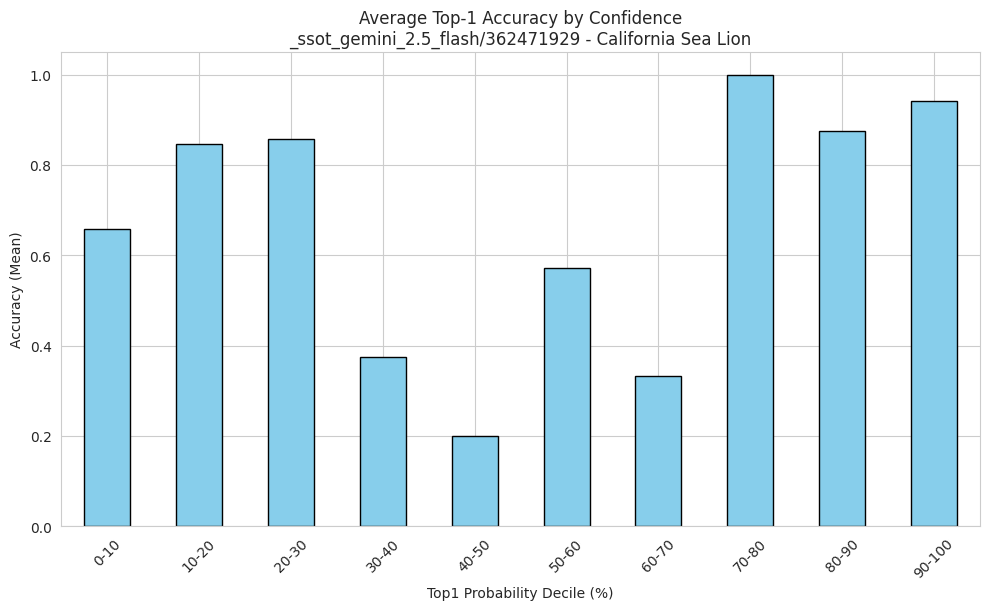





_cdrl_gemini_2.5_flash


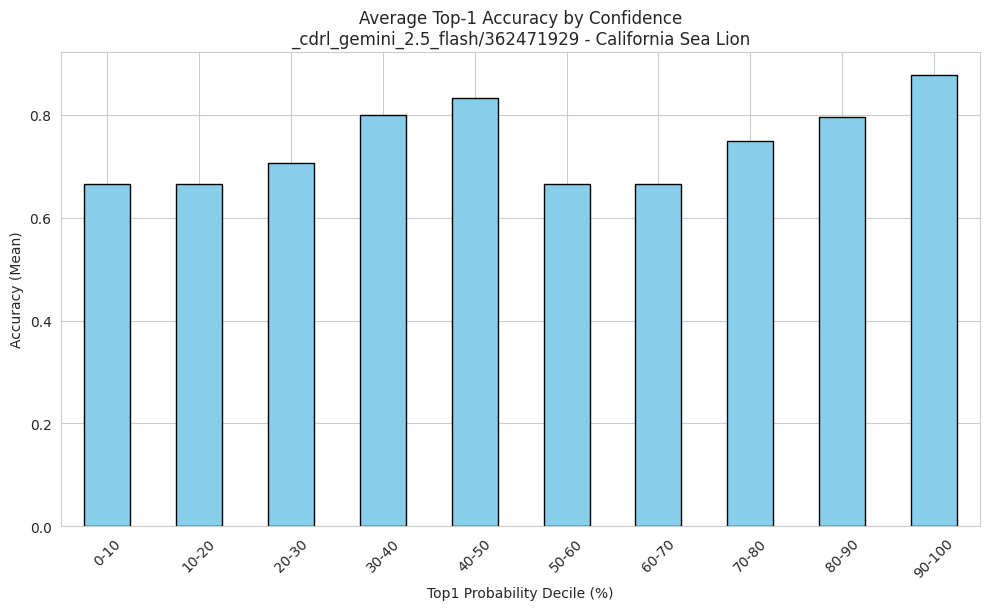





_far_gemini_2.5_flash


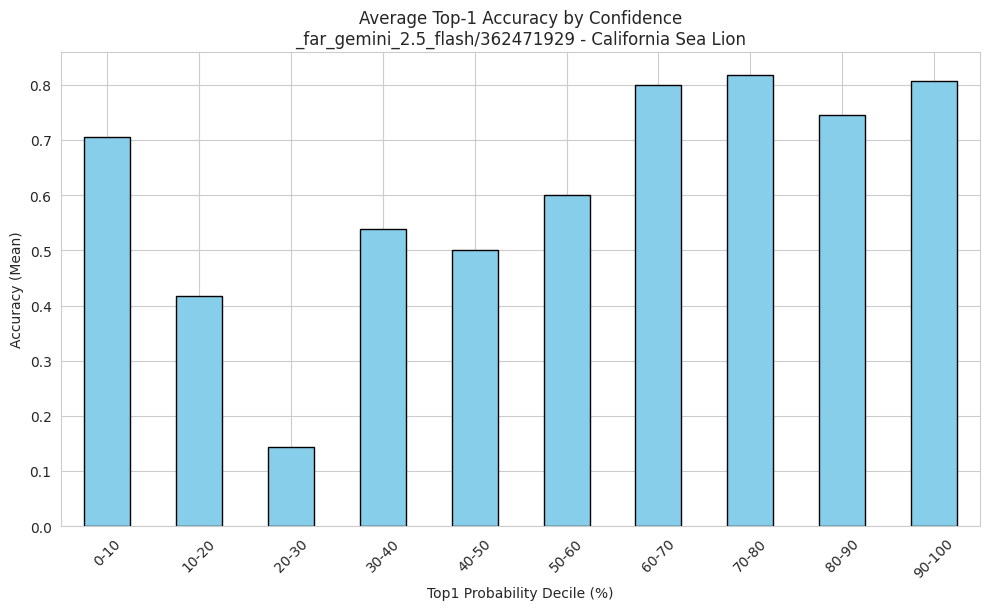





_cove_gemini_2.5_flash


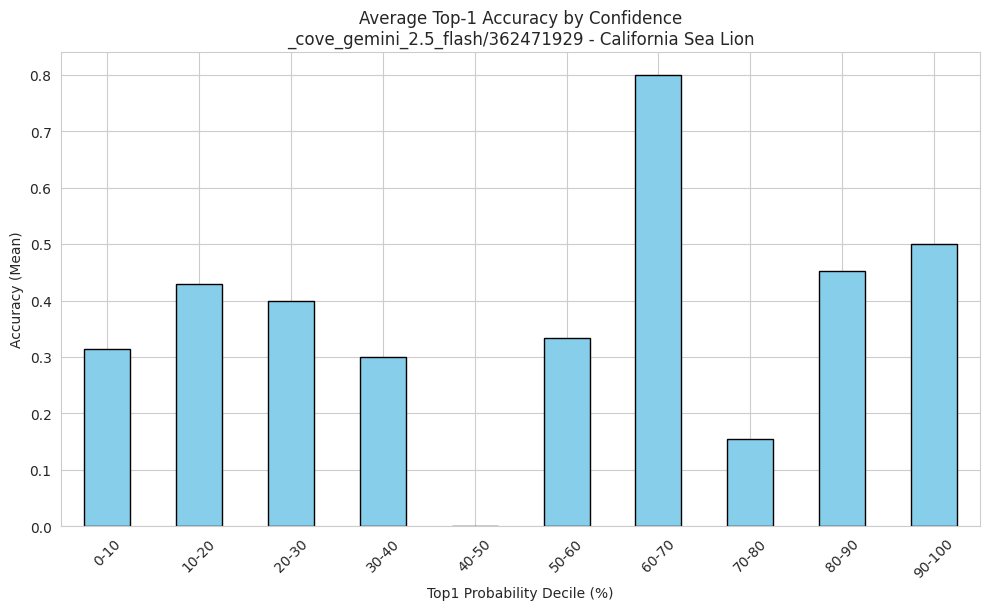





_best_gemini_2.5_flash


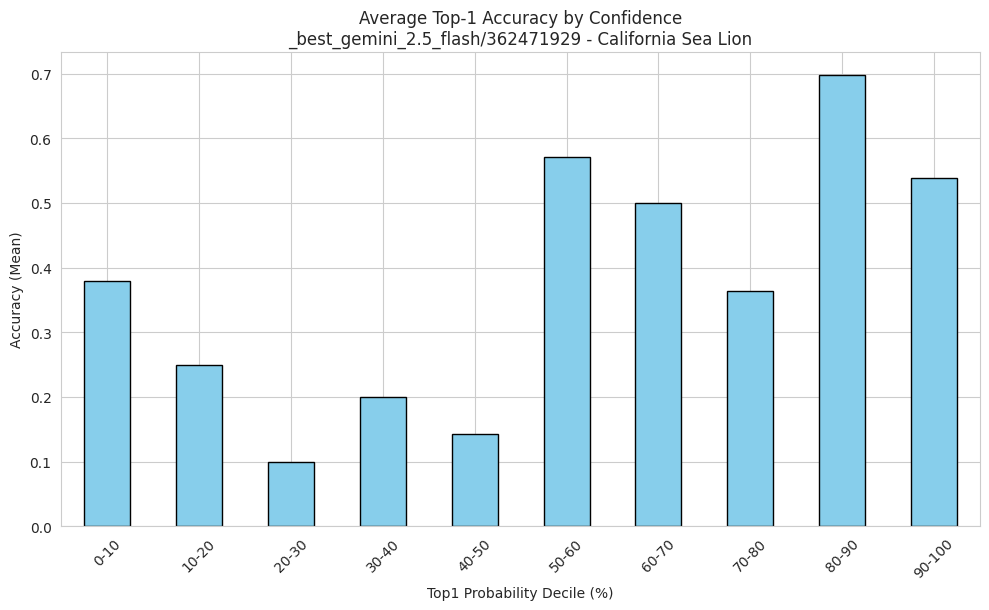





362424973
_baseline_gemini_2.5_flash


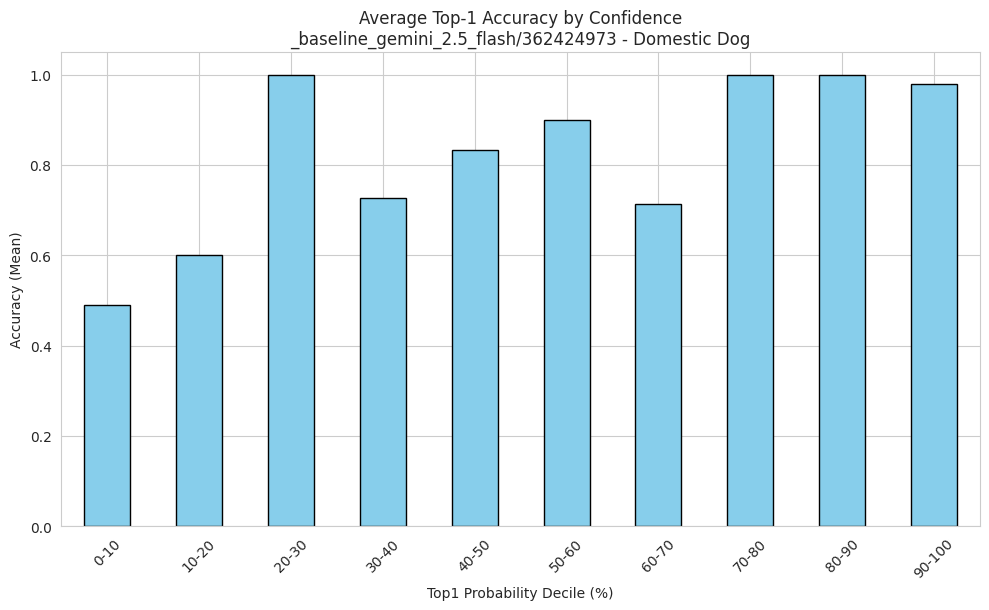





_metadata_gemini_2.5_flash


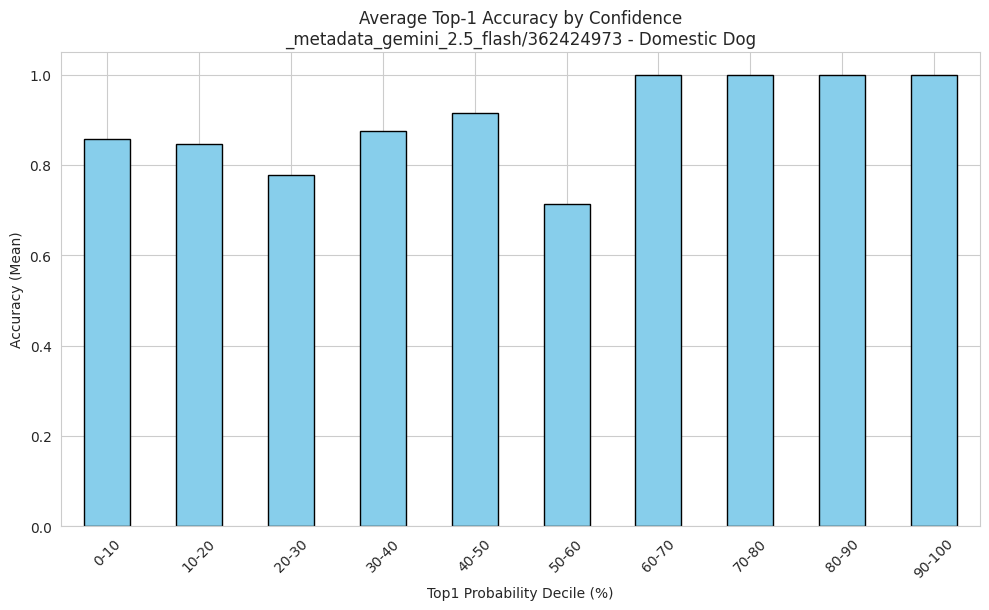





_ssot_gemini_2.5_flash


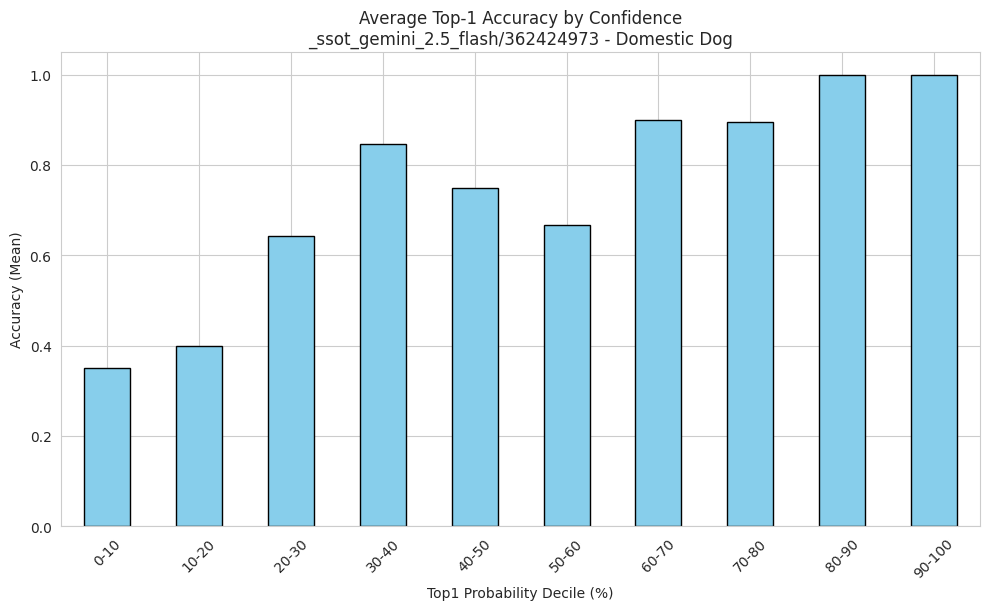





_cdrl_gemini_2.5_flash


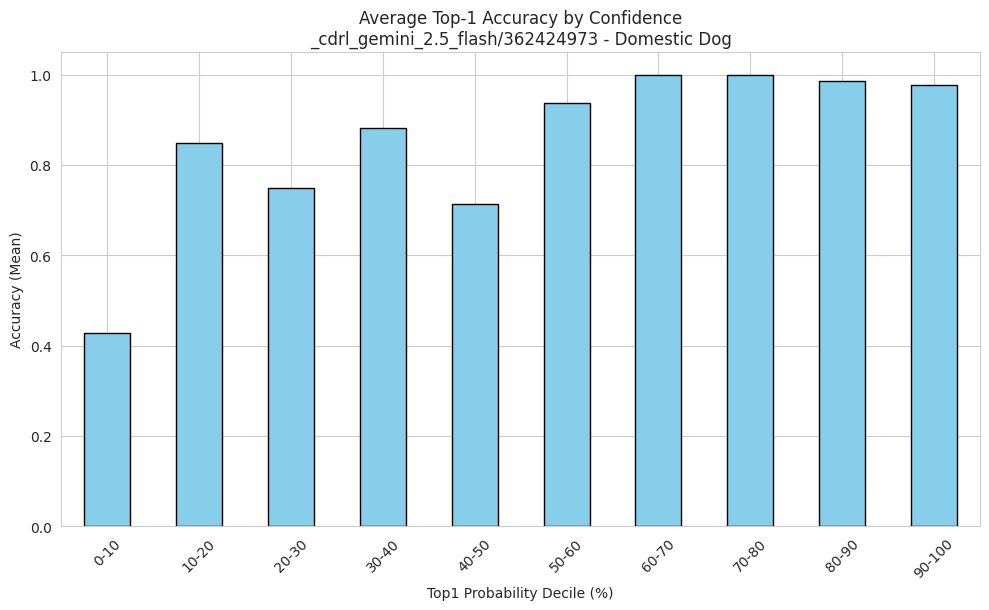





_far_gemini_2.5_flash


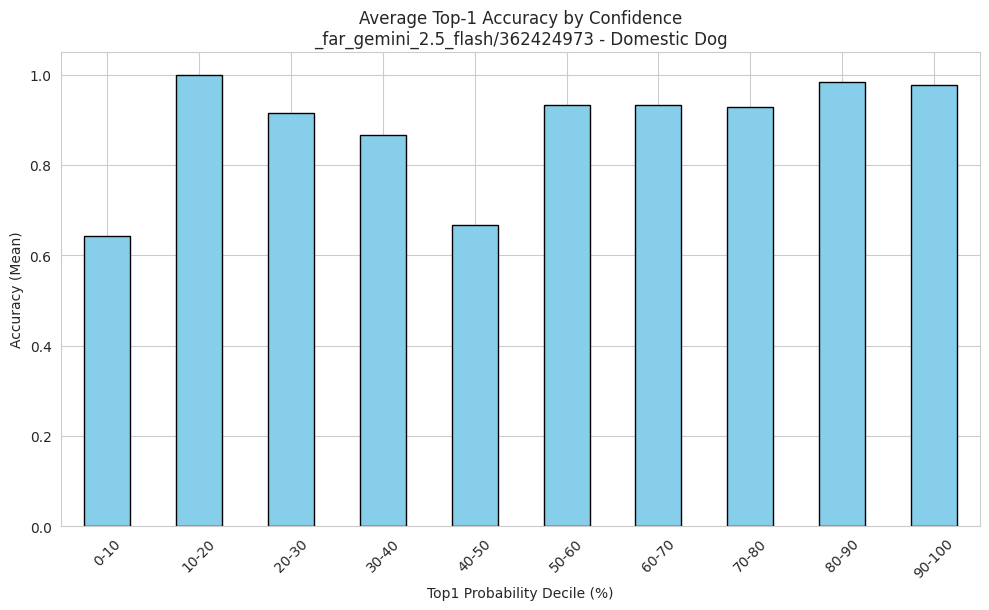





_cove_gemini_2.5_flash


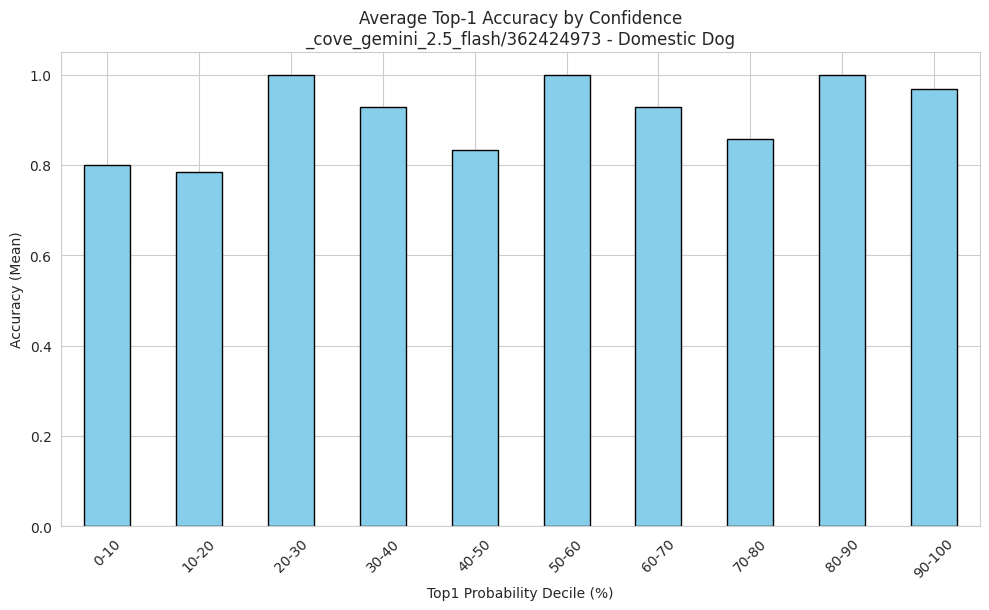





_best_gemini_2.5_flash


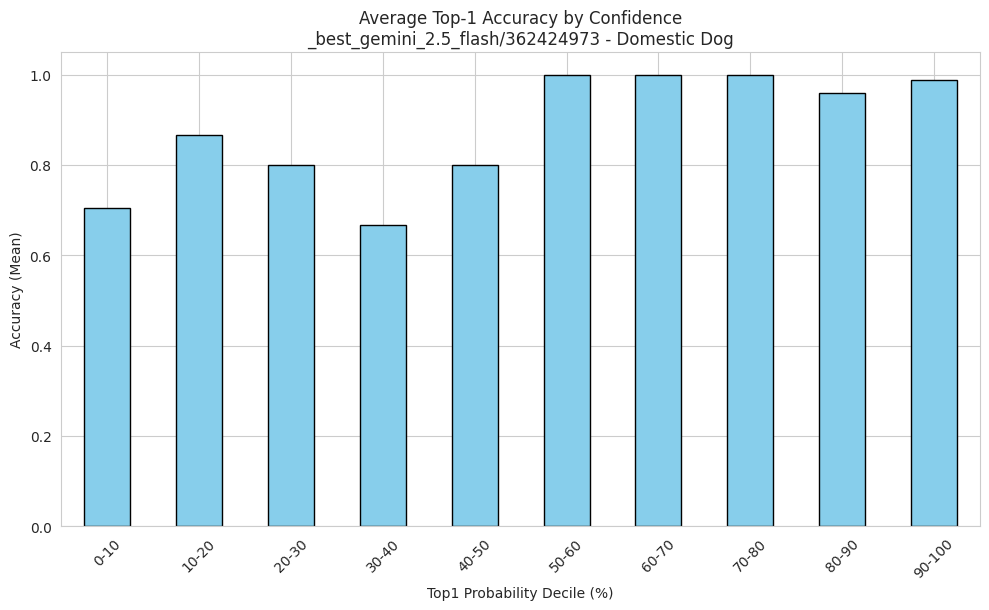





362588731
_baseline_gemini_2.5_flash


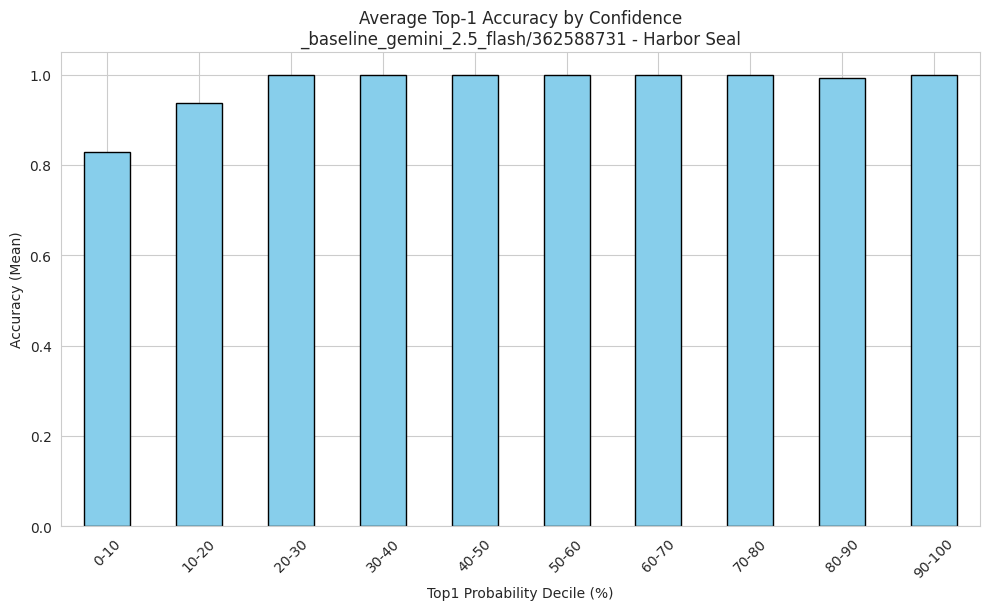





_metadata_gemini_2.5_flash


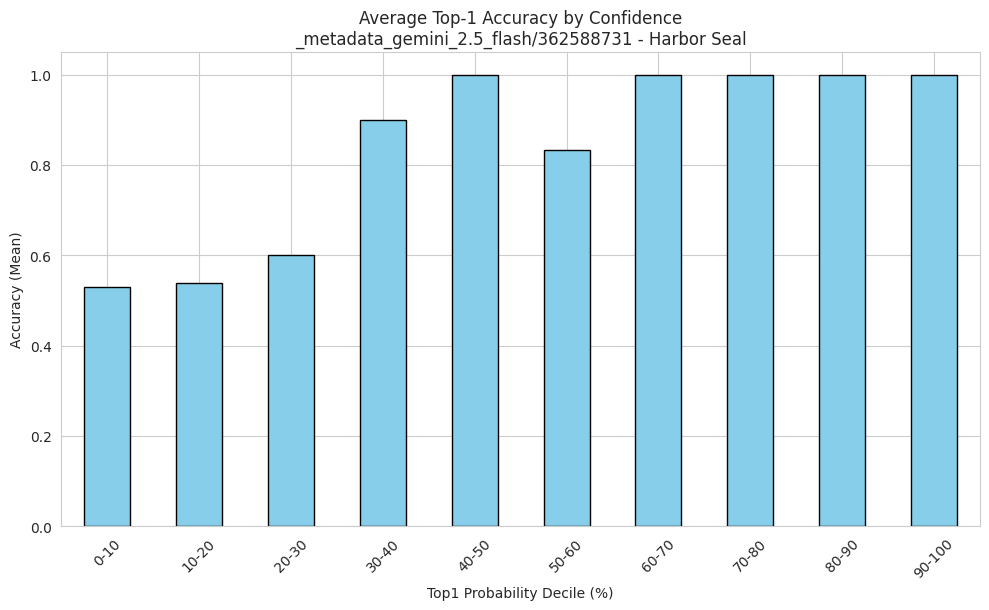





_ssot_gemini_2.5_flash


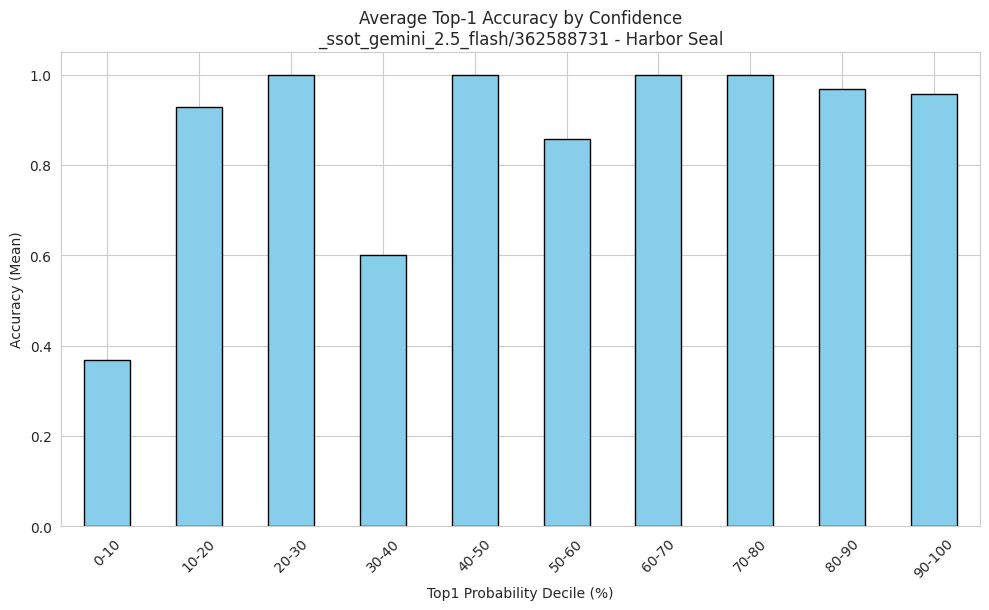





_cdrl_gemini_2.5_flash


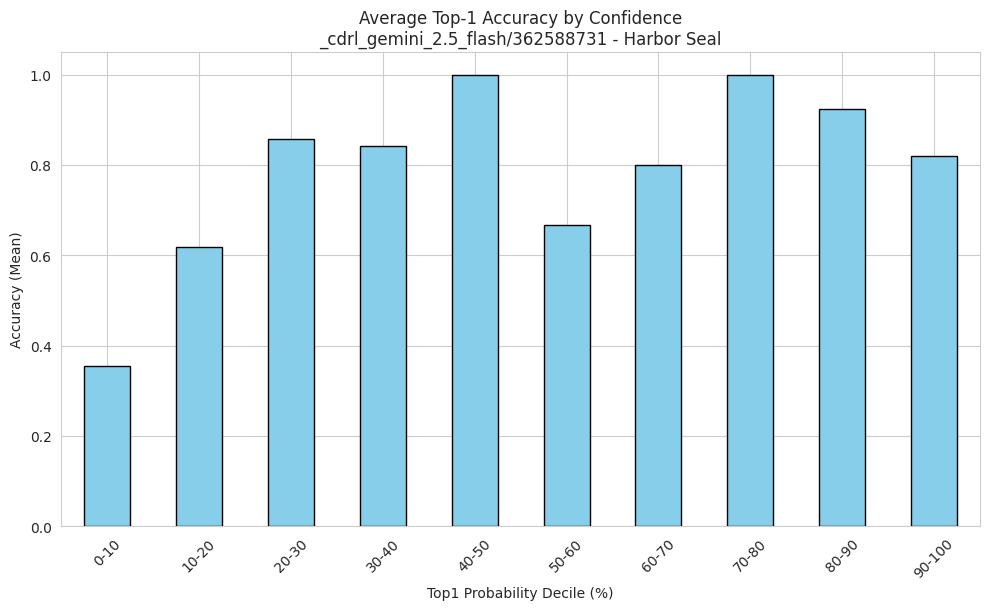





_far_gemini_2.5_flash


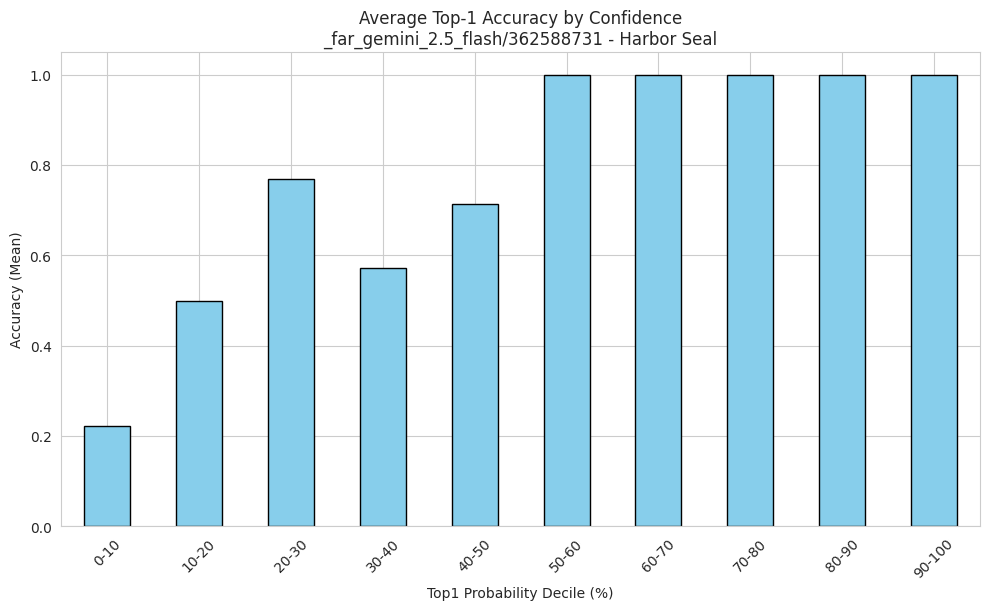





_cove_gemini_2.5_flash


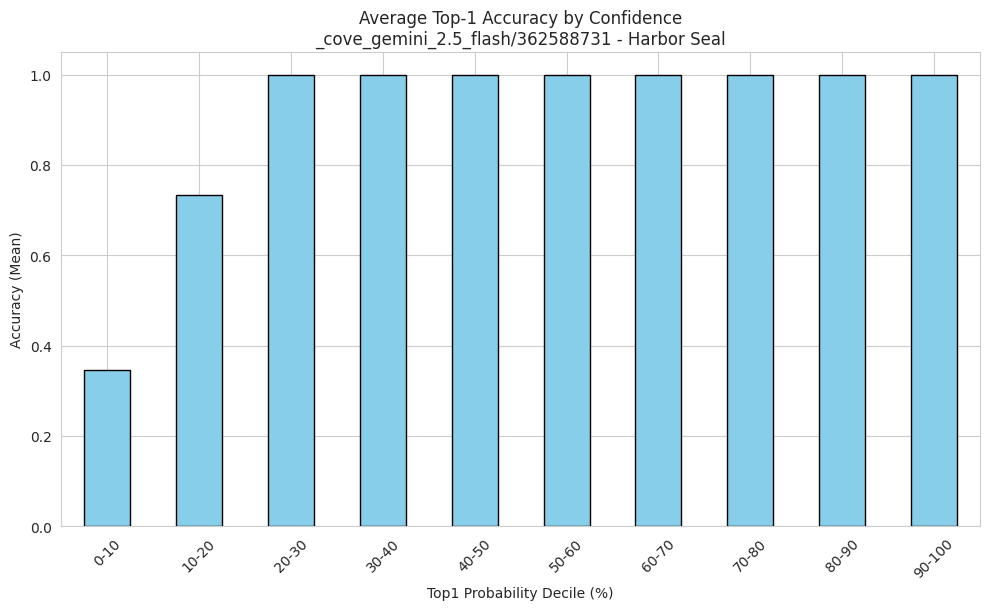





_best_gemini_2.5_flash


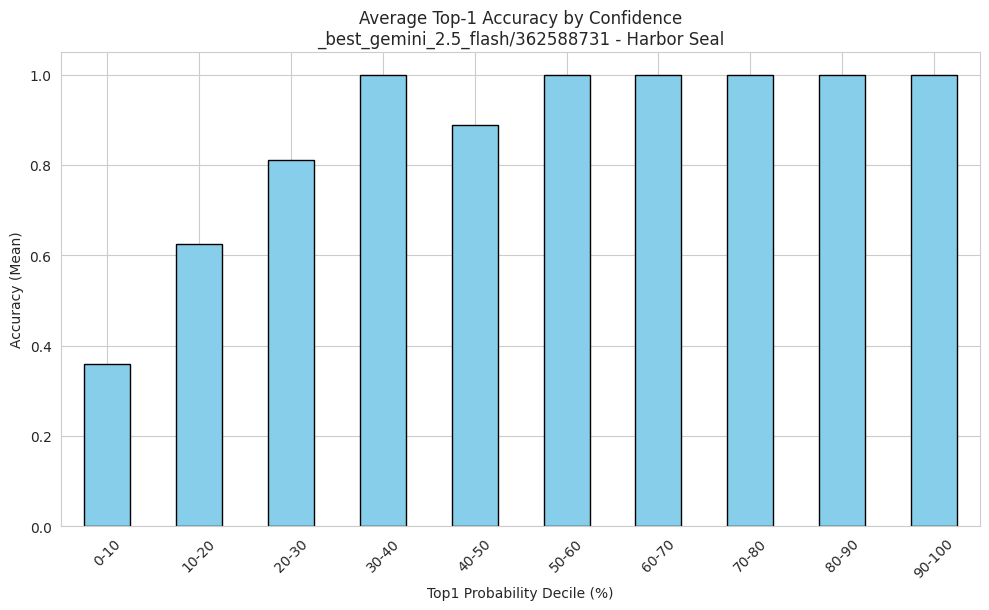

In [60]:
TARGET_IDS = [361231332, 362234822, 362471929, 362424973, 362588731]
folder_names = ['_baseline_gemini_2.5_flash', '_metadata_gemini_2.5_flash',  '_ssot_gemini_2.5_flash', '_cdrl_gemini_2.5_flash', '_far_gemini_2.5_flash', '_cove_gemini_2.5_flash', '_best_gemini_2.5_flash']
for i in TARGET_IDS:
    print(i)
    for folder in folder_names:
        print(folder)
        create_charts_accuracy(f'{folder}/{i}_distribution_results.csv')
        print('\n')
        print('\n')

361231332
_baseline_gemini_2.5_flash


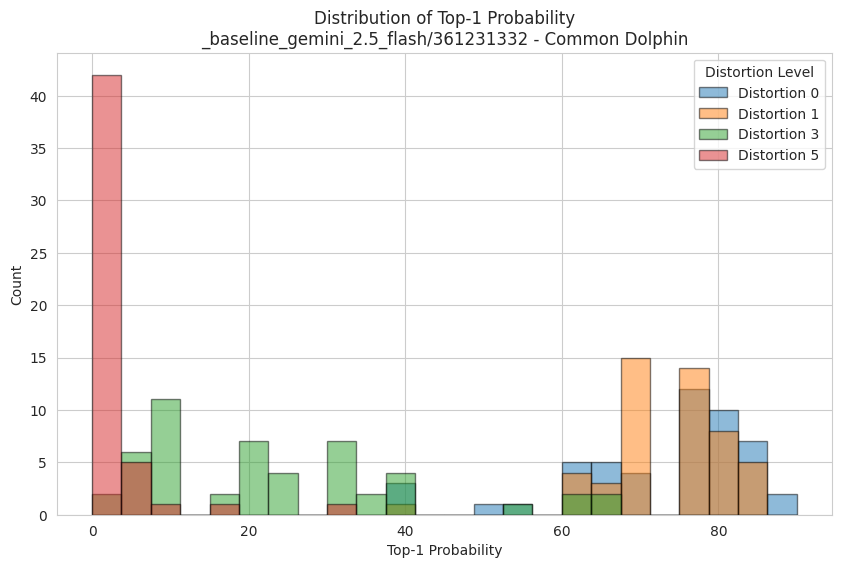





_metadata_gemini_2.5_flash


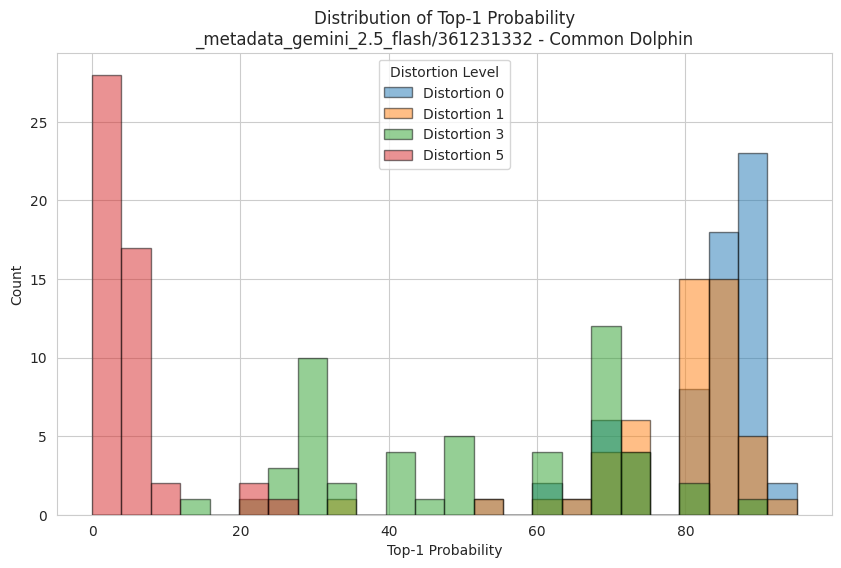





_ssot_gemini_2.5_flash


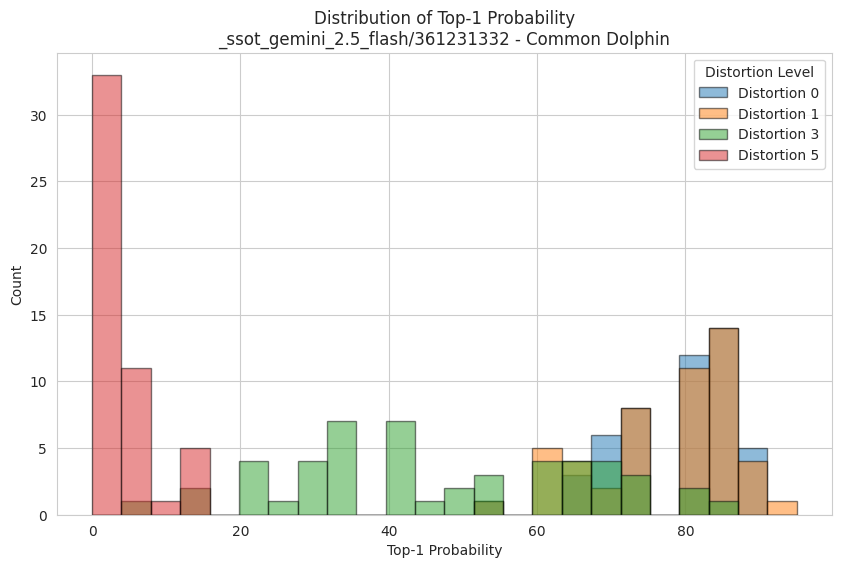





_cdrl_gemini_2.5_flash


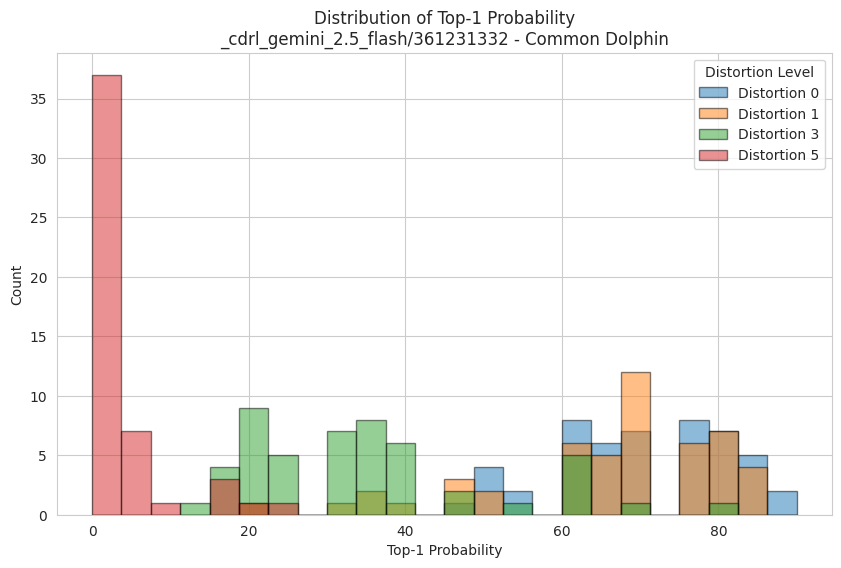





_far_gemini_2.5_flash


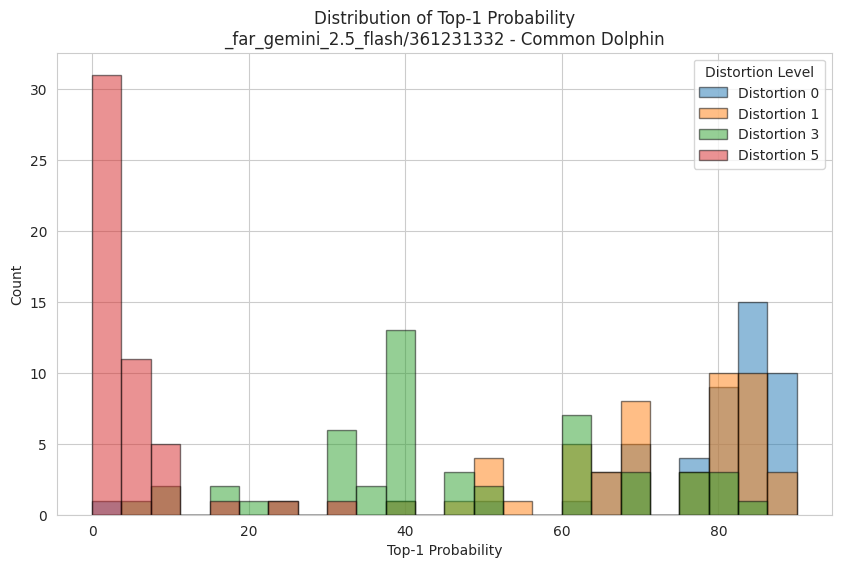





_cove_gemini_2.5_flash


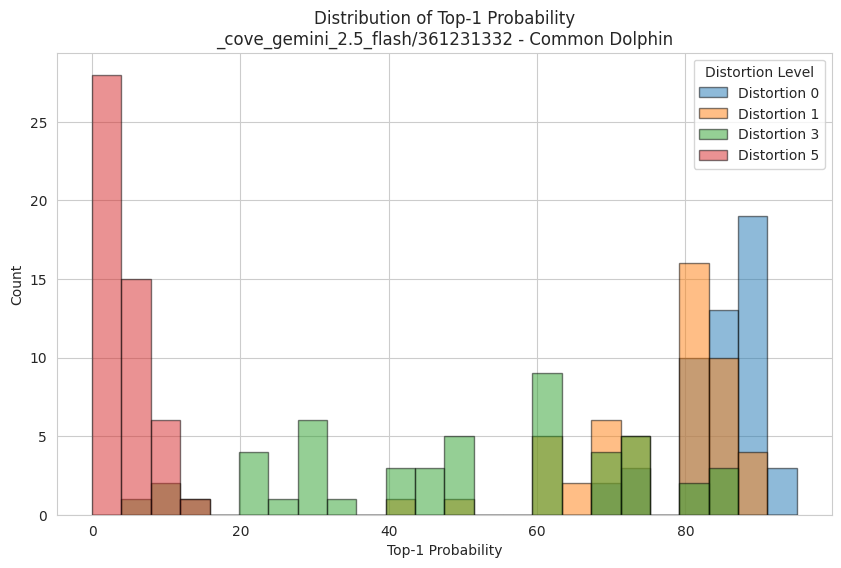





_best_gemini_2.5_flash


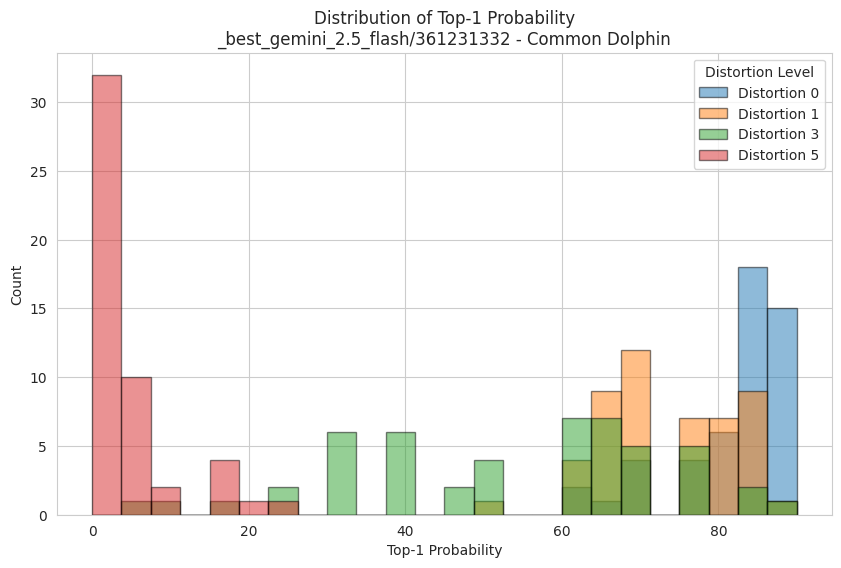





362234822
_baseline_gemini_2.5_flash


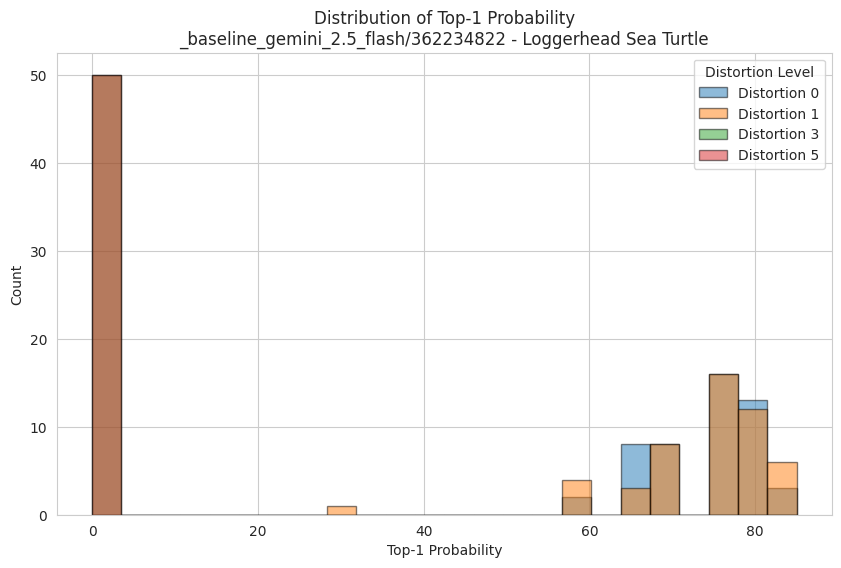





_metadata_gemini_2.5_flash


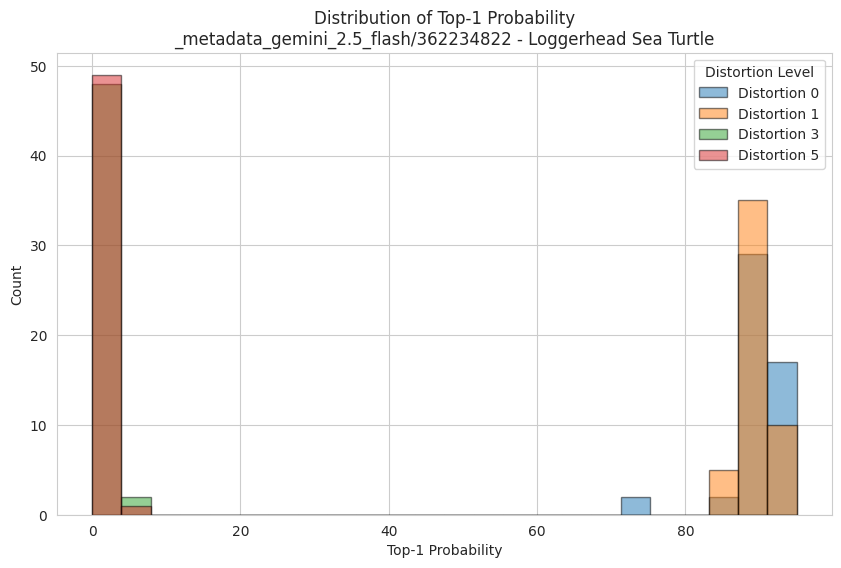





_ssot_gemini_2.5_flash


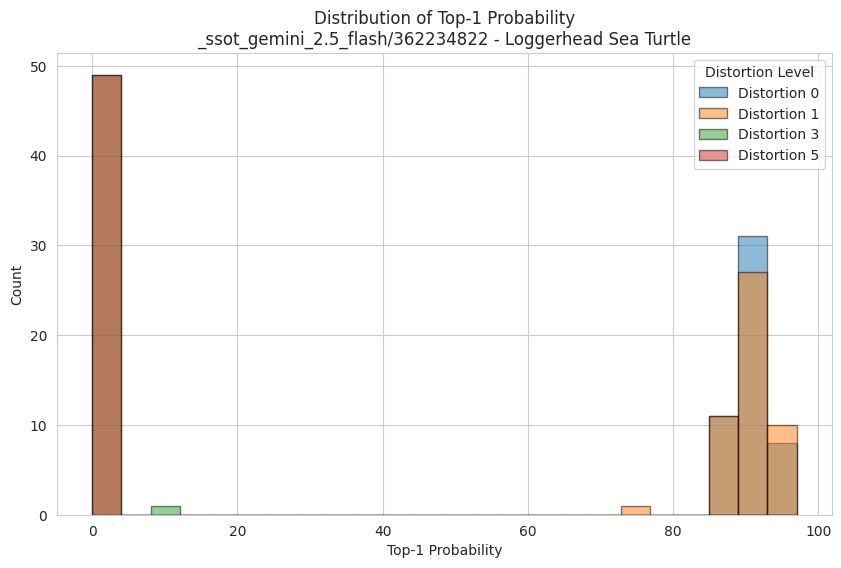





_cdrl_gemini_2.5_flash


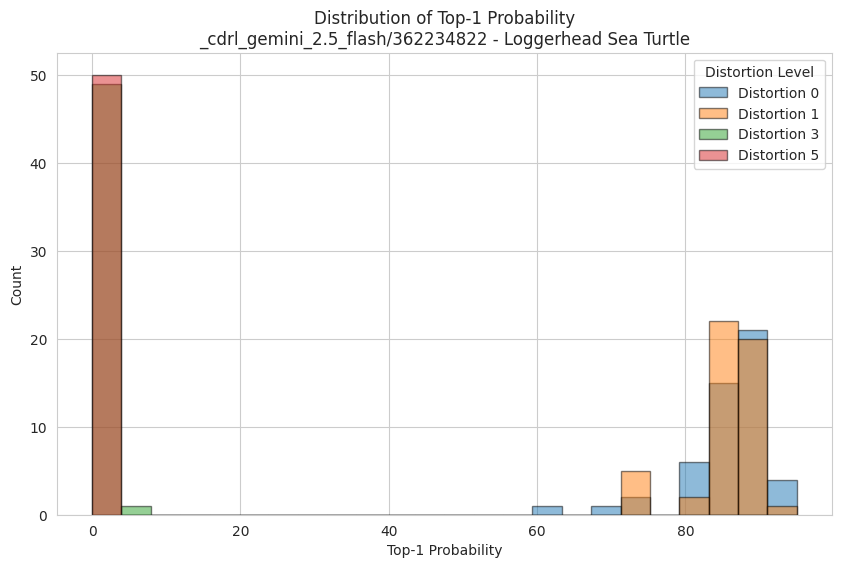





_far_gemini_2.5_flash


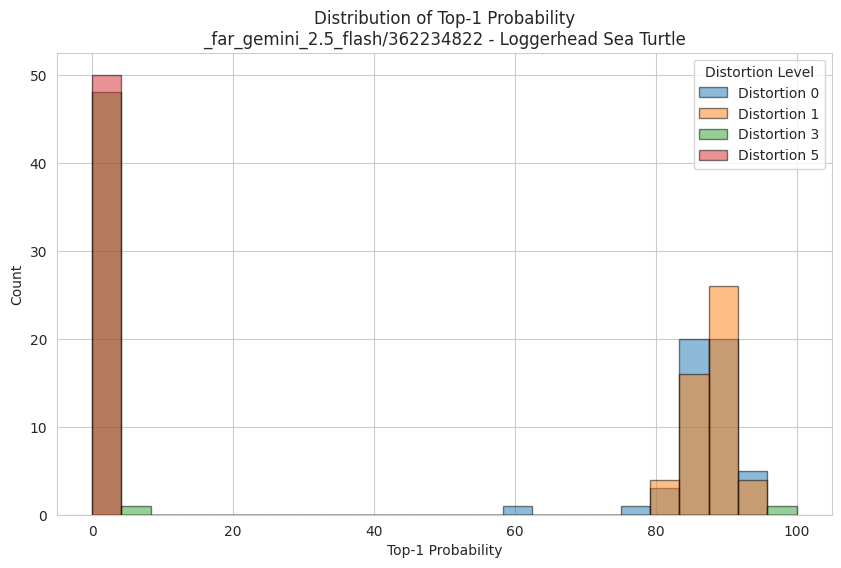





_cove_gemini_2.5_flash


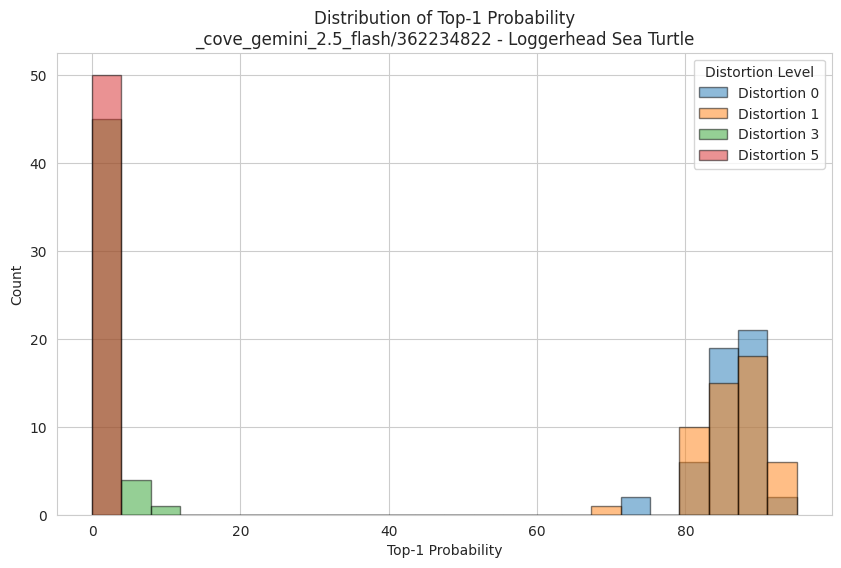





_best_gemini_2.5_flash


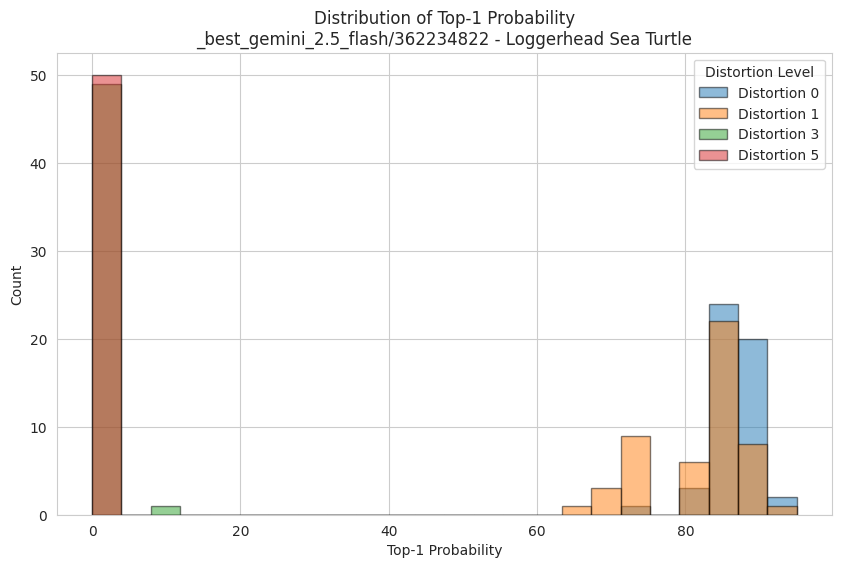





362471929
_baseline_gemini_2.5_flash


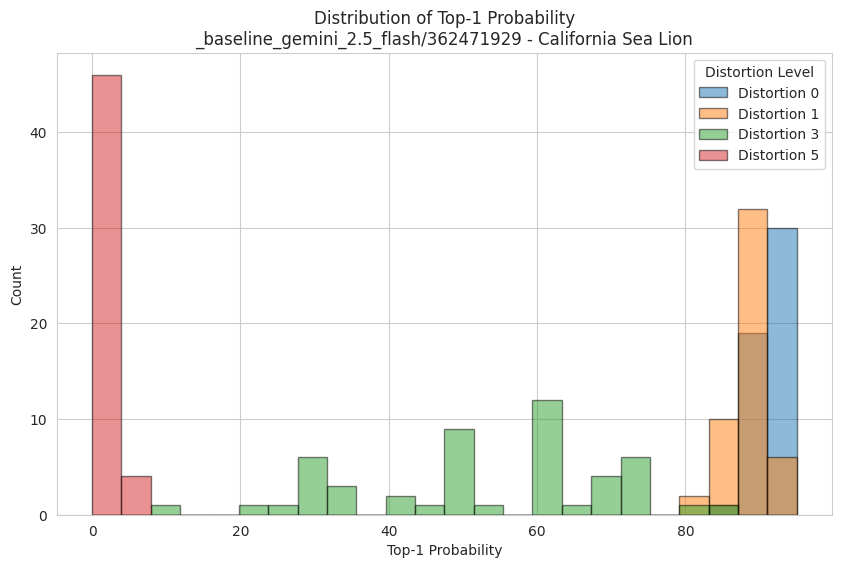





_metadata_gemini_2.5_flash


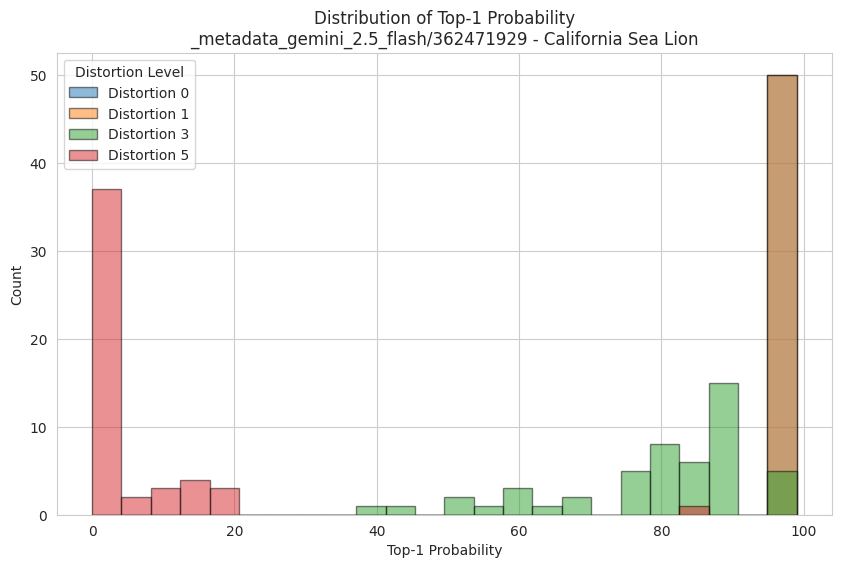





_ssot_gemini_2.5_flash


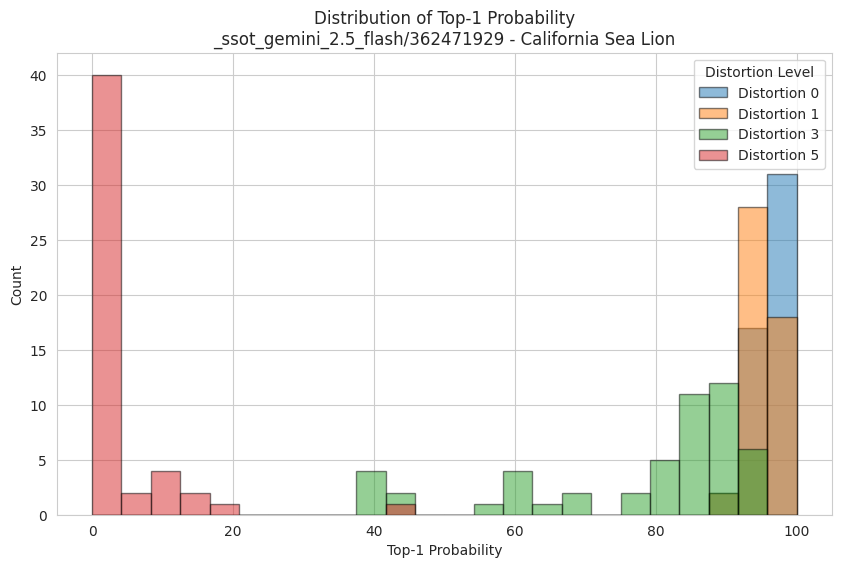





_cdrl_gemini_2.5_flash


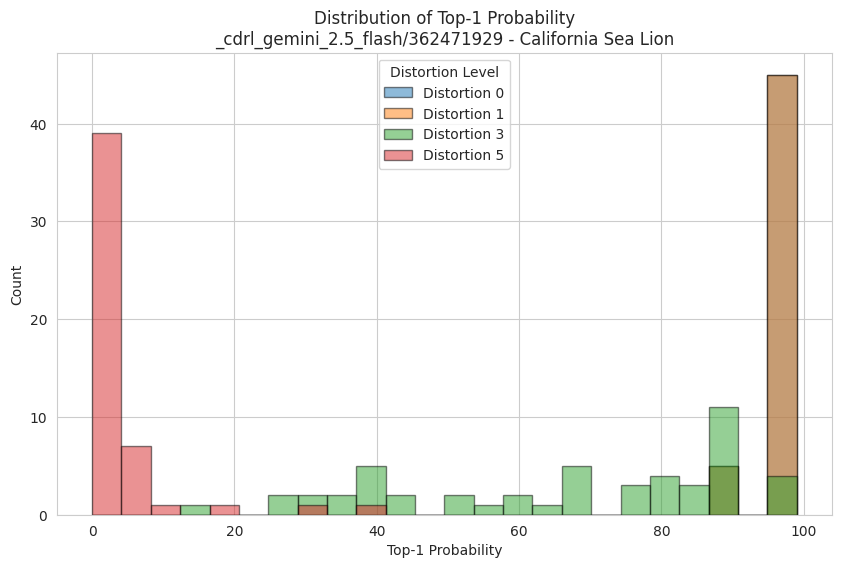





_far_gemini_2.5_flash


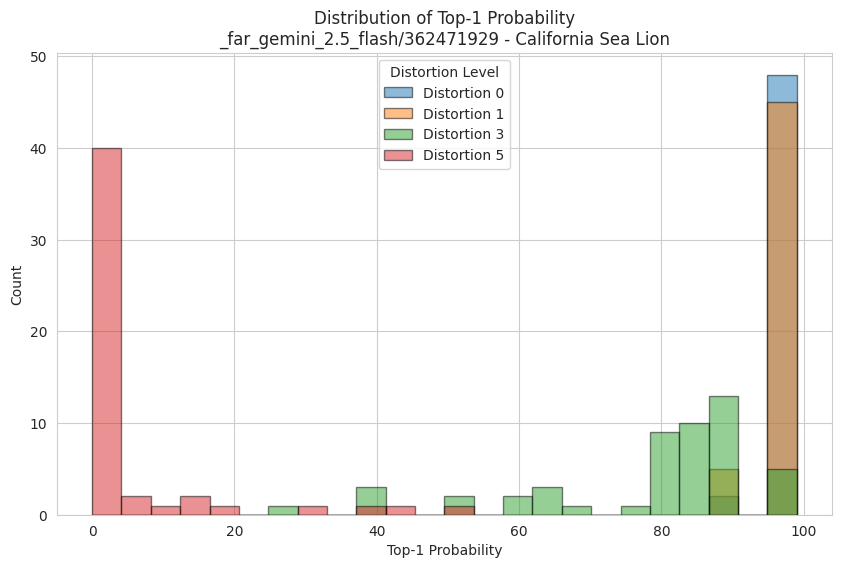





_cove_gemini_2.5_flash


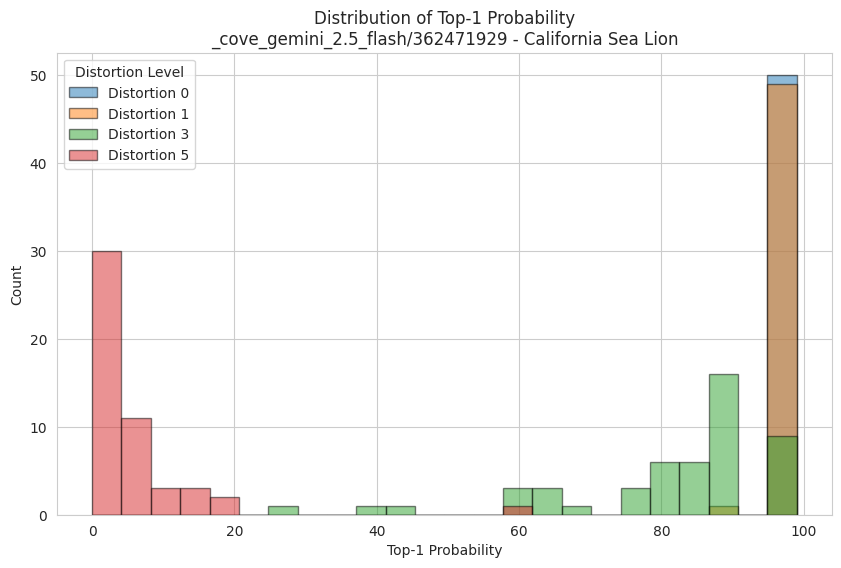





_best_gemini_2.5_flash


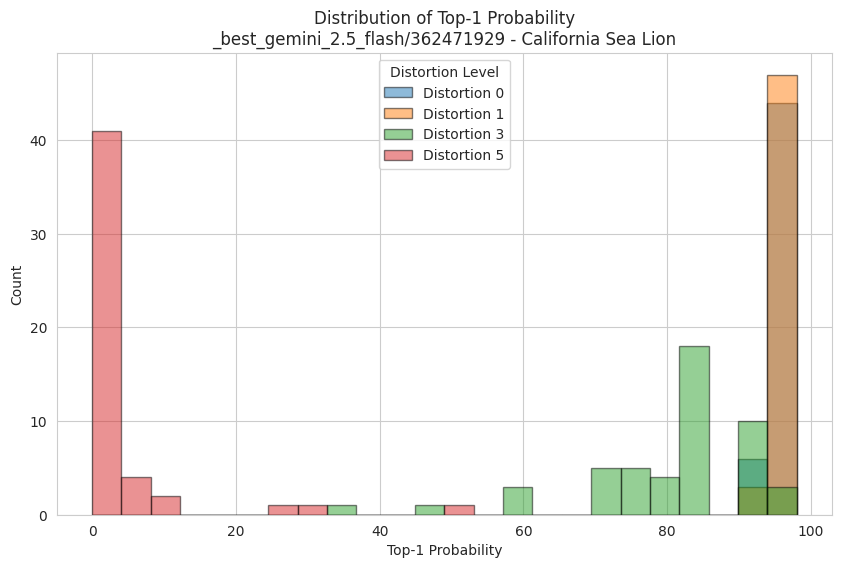





362424973
_baseline_gemini_2.5_flash


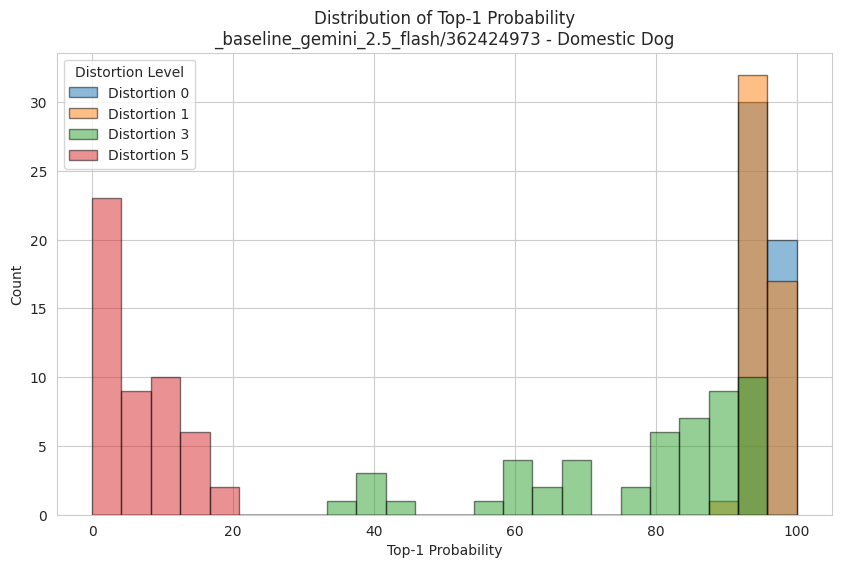





_metadata_gemini_2.5_flash


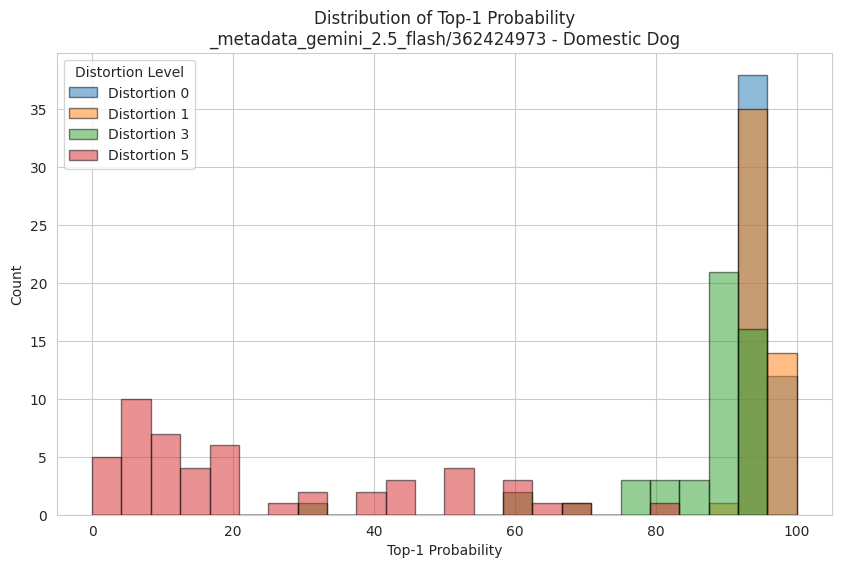





_ssot_gemini_2.5_flash


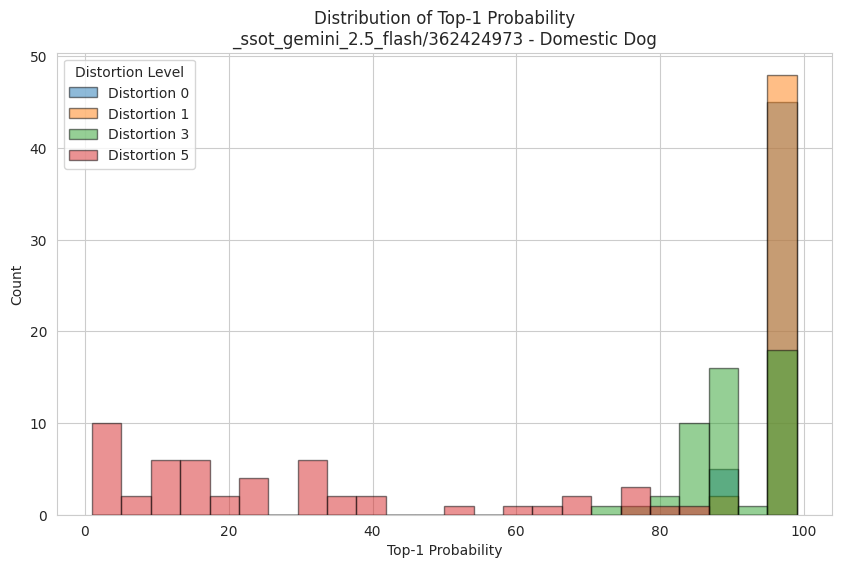





_cdrl_gemini_2.5_flash


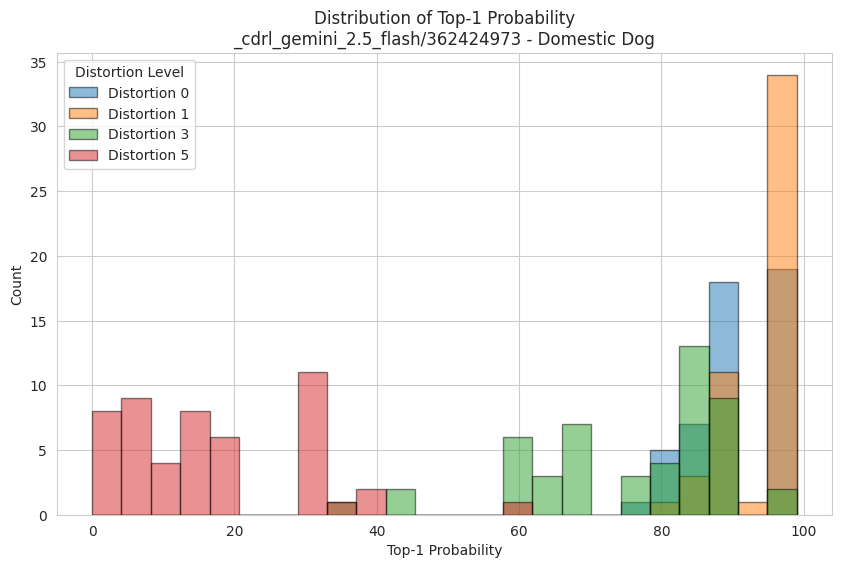





_far_gemini_2.5_flash


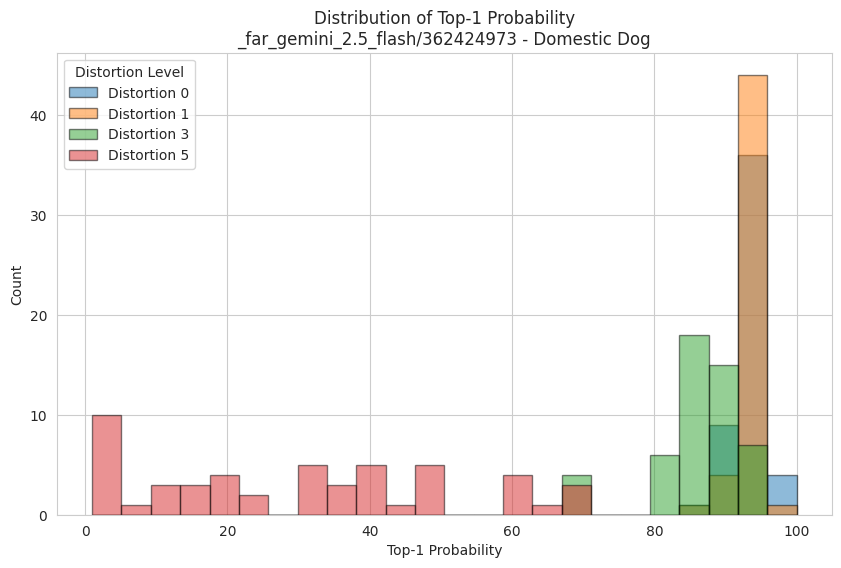





_cove_gemini_2.5_flash


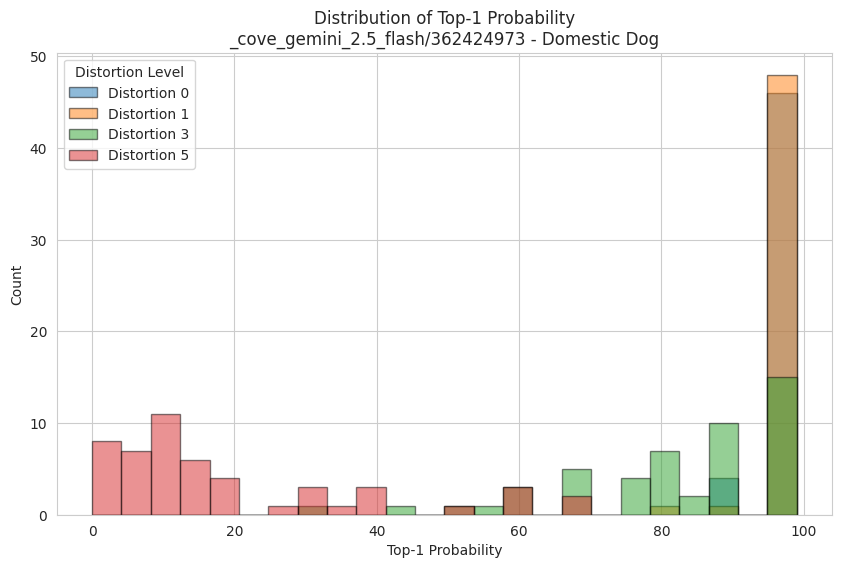





_best_gemini_2.5_flash


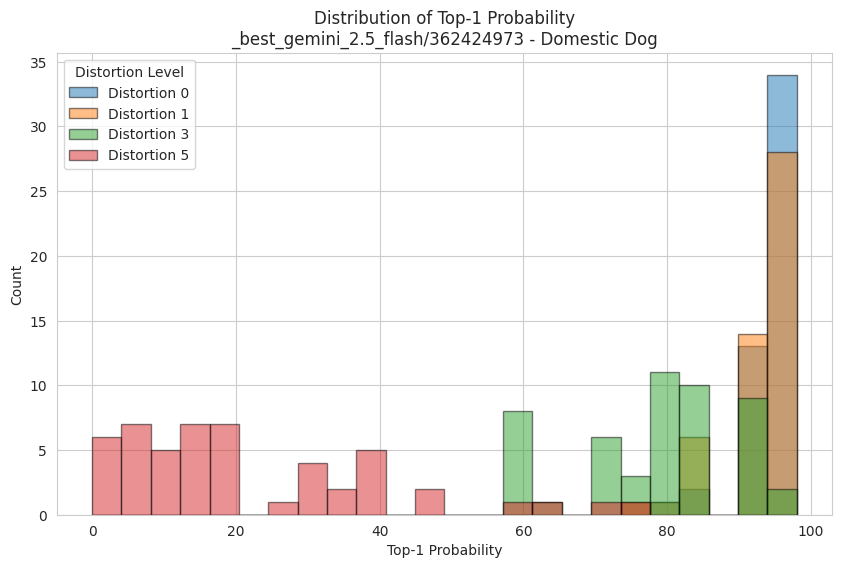





362588731
_baseline_gemini_2.5_flash


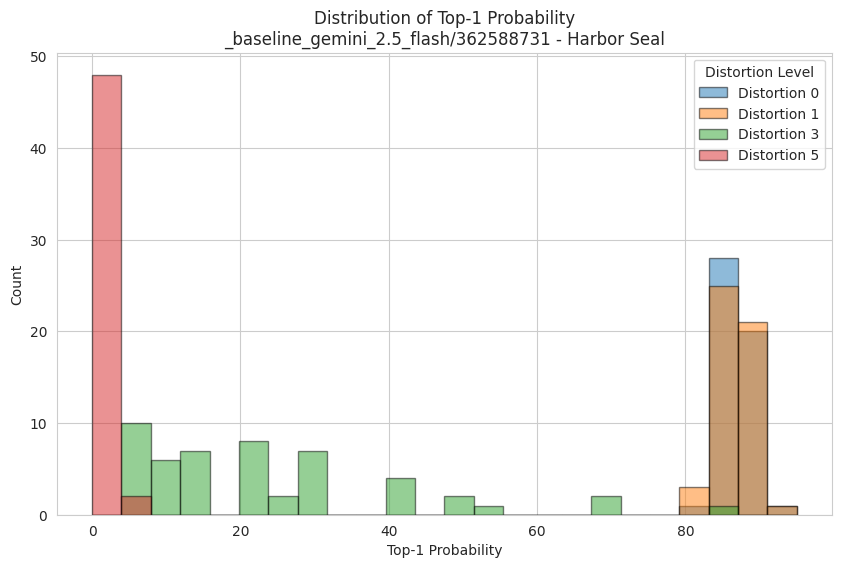





_metadata_gemini_2.5_flash


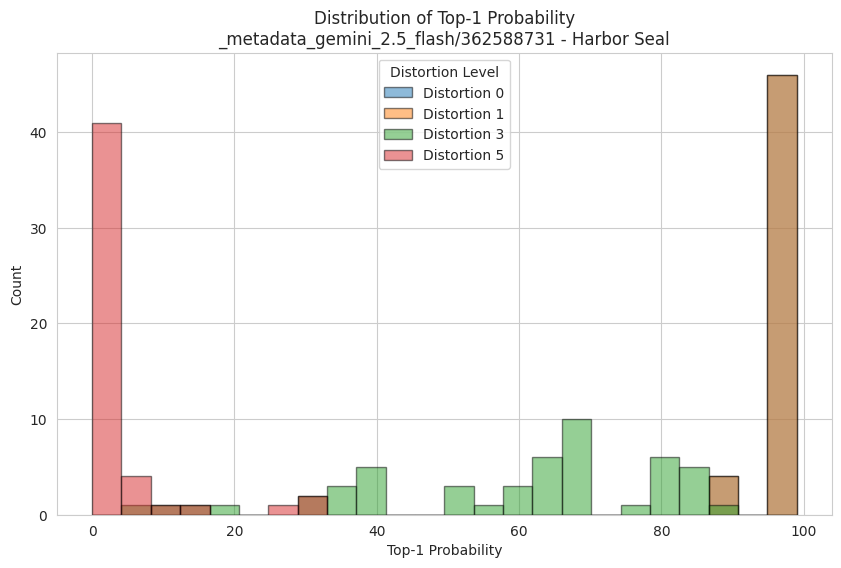





_ssot_gemini_2.5_flash


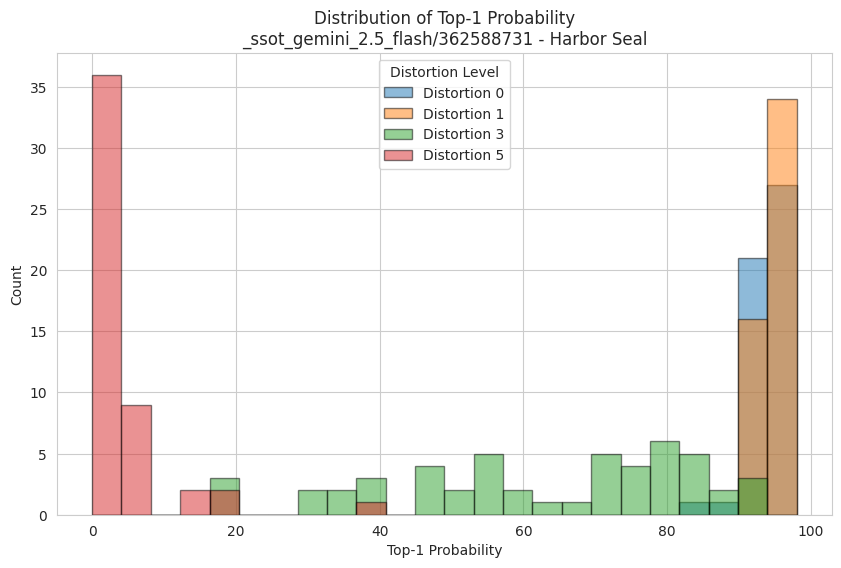





_cdrl_gemini_2.5_flash


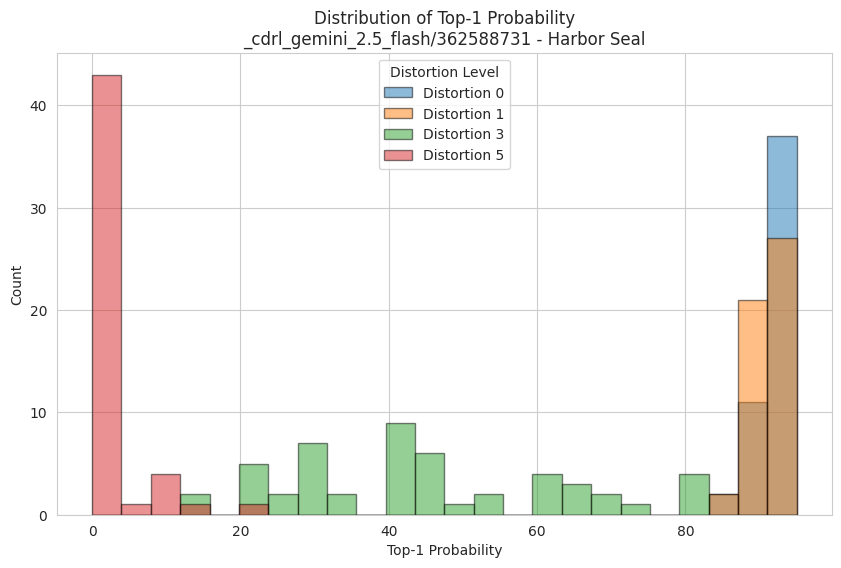





_far_gemini_2.5_flash


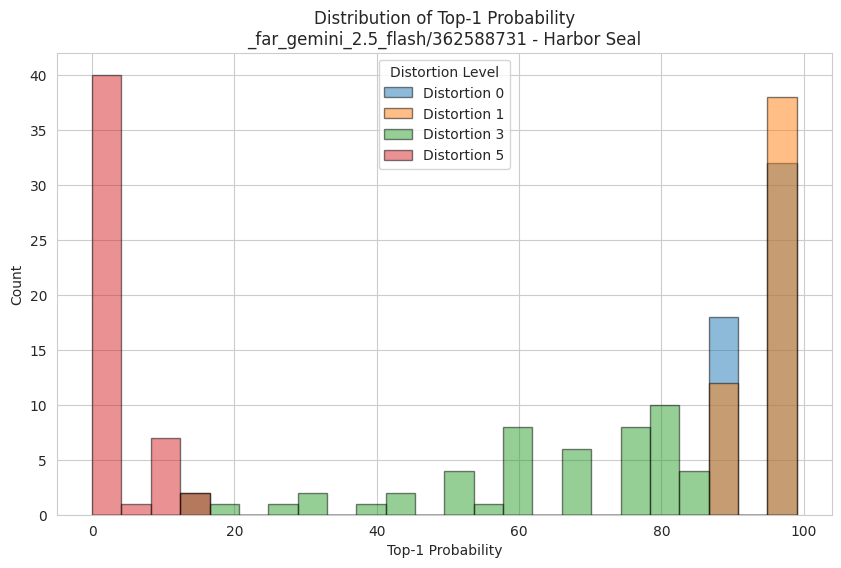





_cove_gemini_2.5_flash


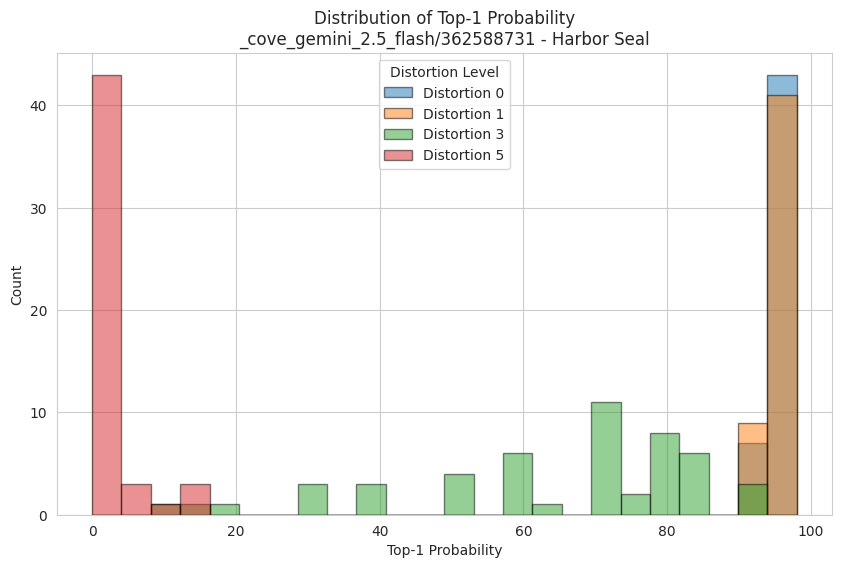





_best_gemini_2.5_flash


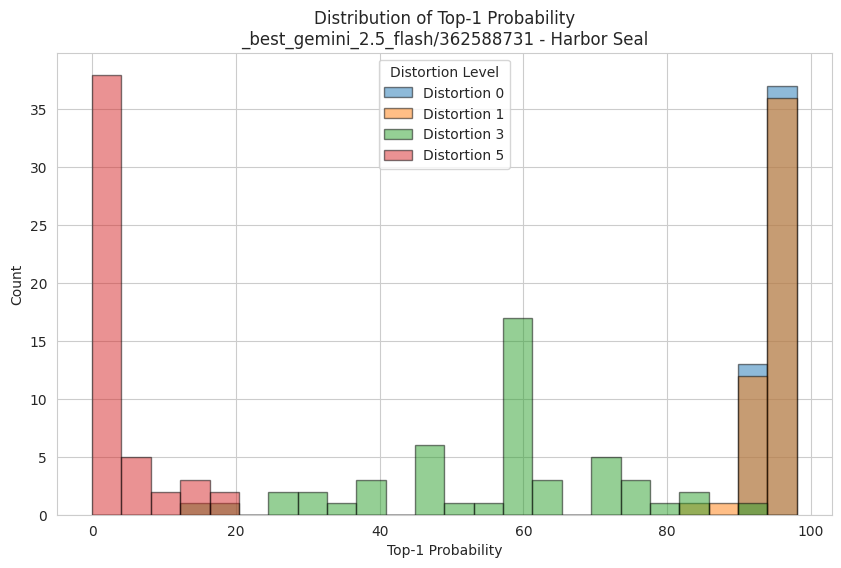

In [44]:
TARGET_IDS = [361231332, 362234822, 362471929, 362424973, 362588731]
folder_names = ['_baseline_gemini_2.5_flash', '_metadata_gemini_2.5_flash',  '_ssot_gemini_2.5_flash', '_cdrl_gemini_2.5_flash', '_far_gemini_2.5_flash', '_cove_gemini_2.5_flash', '_best_gemini_2.5_flash']
for i in TARGET_IDS:
    print(i)
    for folder in folder_names:
        print(folder)
        create_charts_hist(f'{folder}/{i}_distribution_results.csv')
        print('\n')
        print('\n')

361231332
_baseline_gemini_2.5_flash


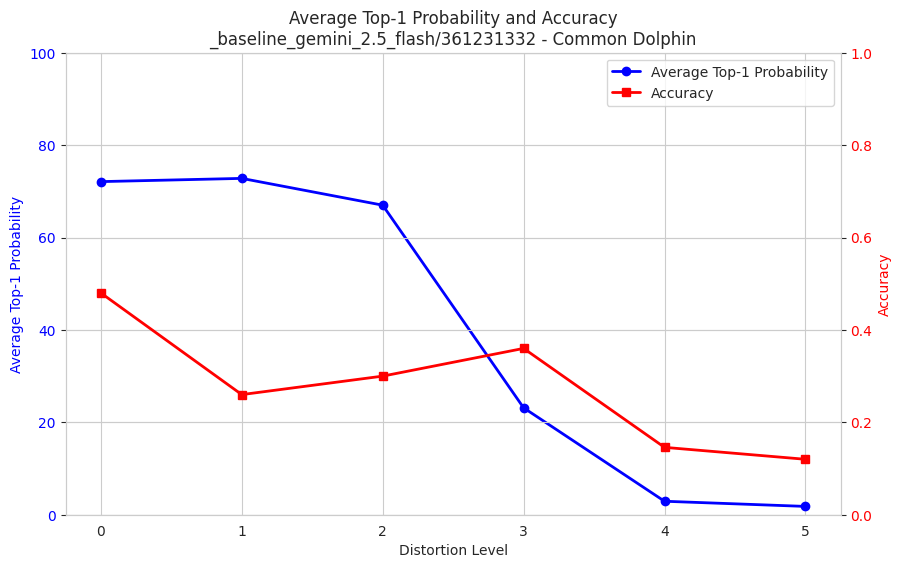





_metadata_gemini_2.5_flash


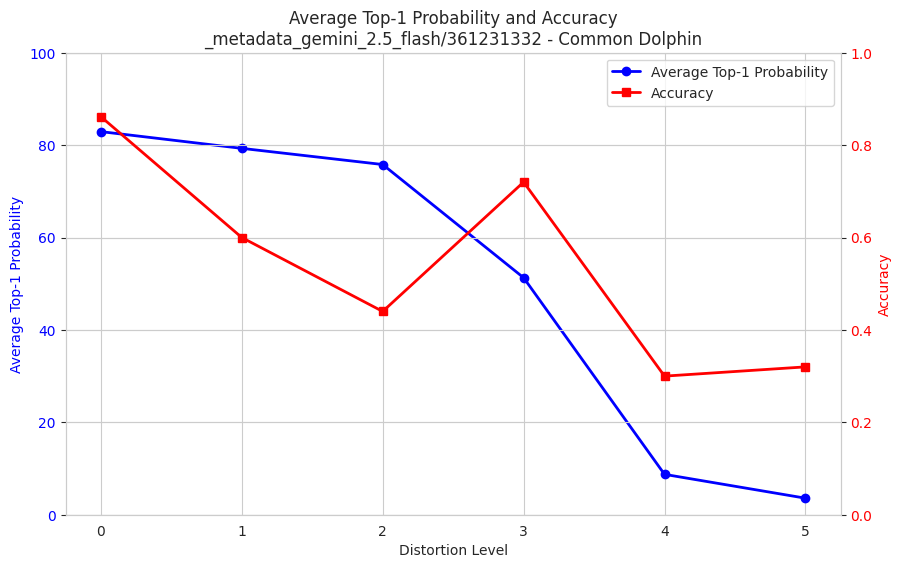





_ssot_gemini_2.5_flash


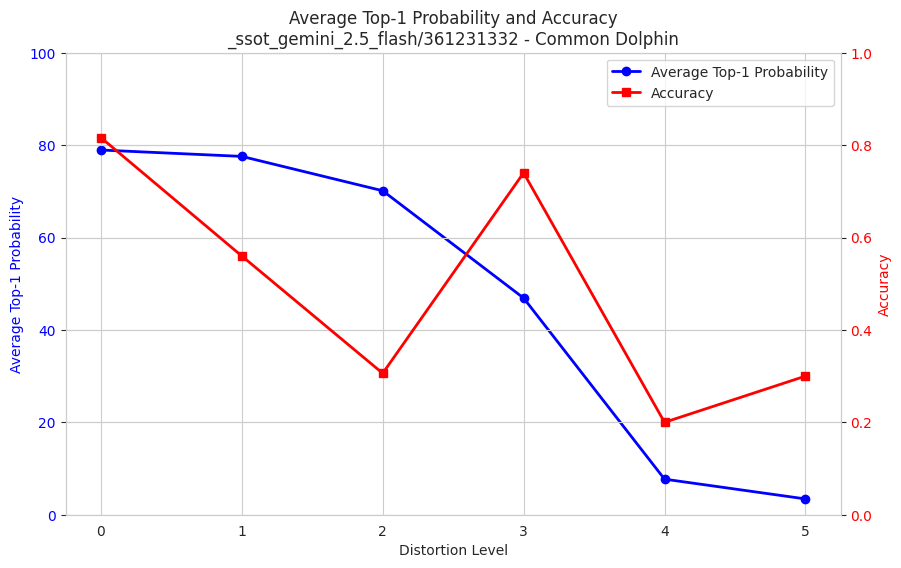





_cdrl_gemini_2.5_flash


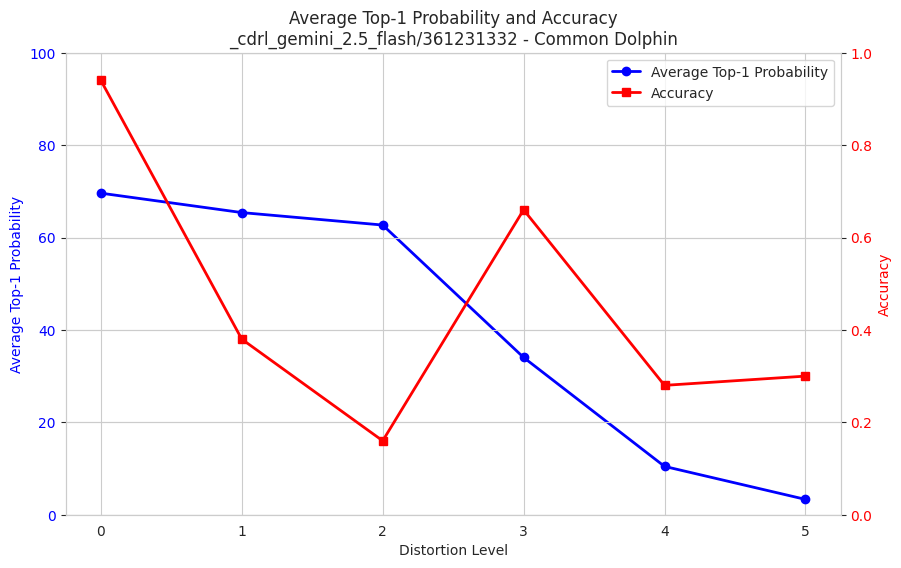





_far_gemini_2.5_flash


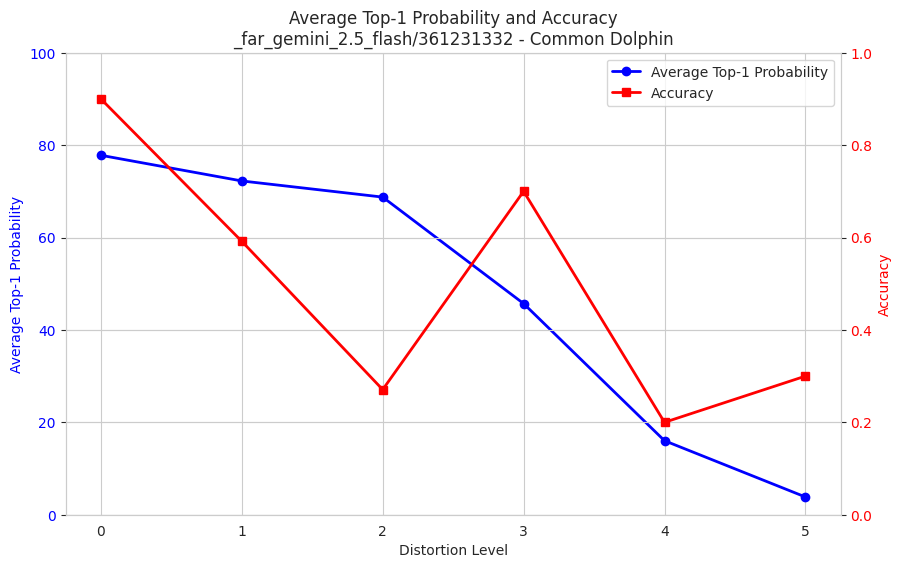





_cove_gemini_2.5_flash


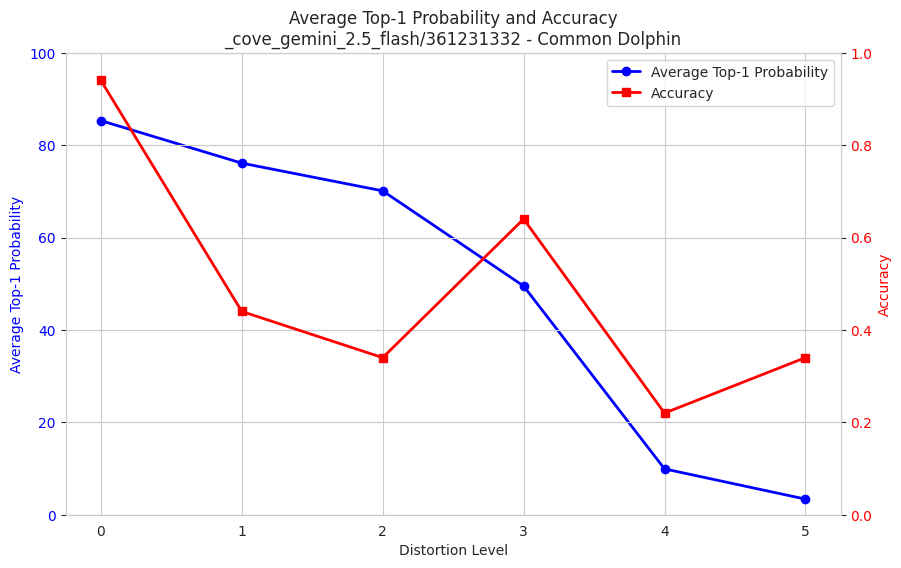





_best_gemini_2.5_flash


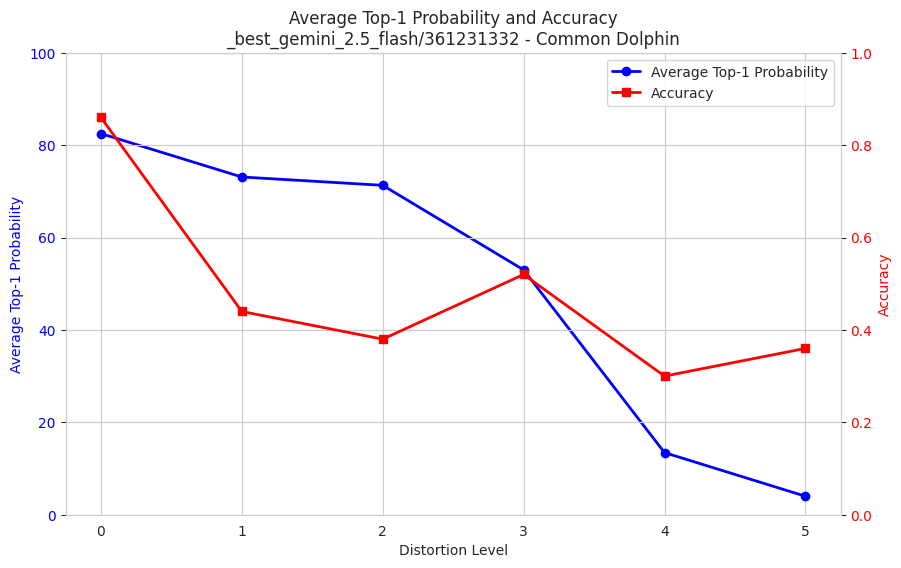





362234822
_baseline_gemini_2.5_flash


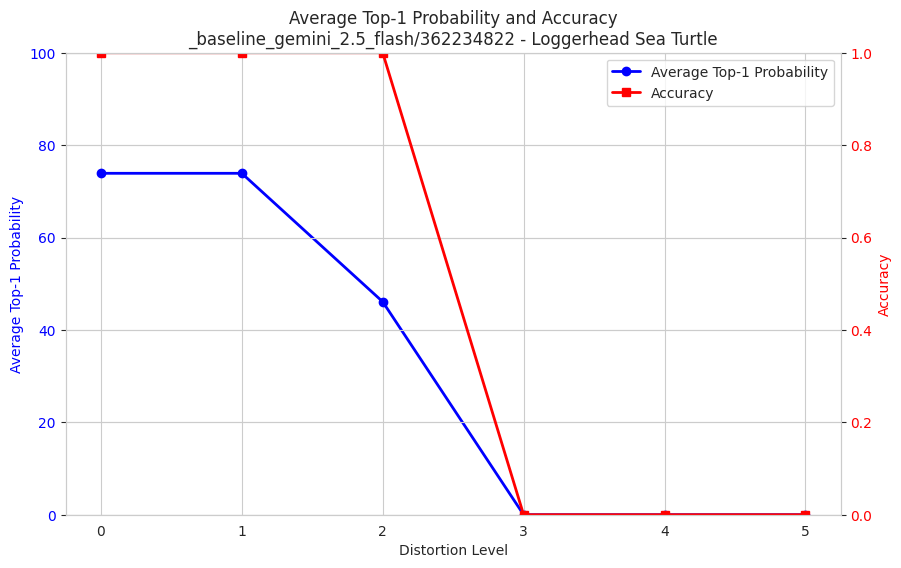





_metadata_gemini_2.5_flash


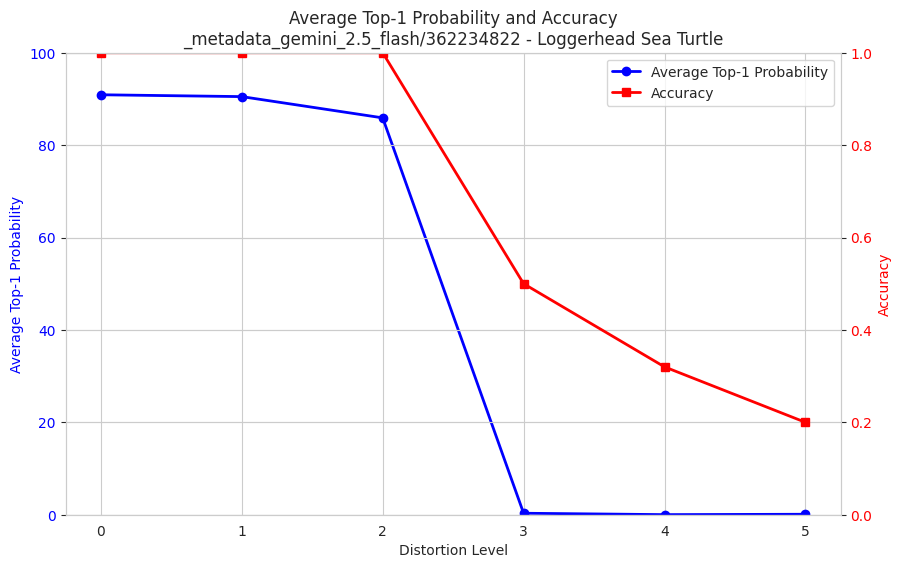





_ssot_gemini_2.5_flash


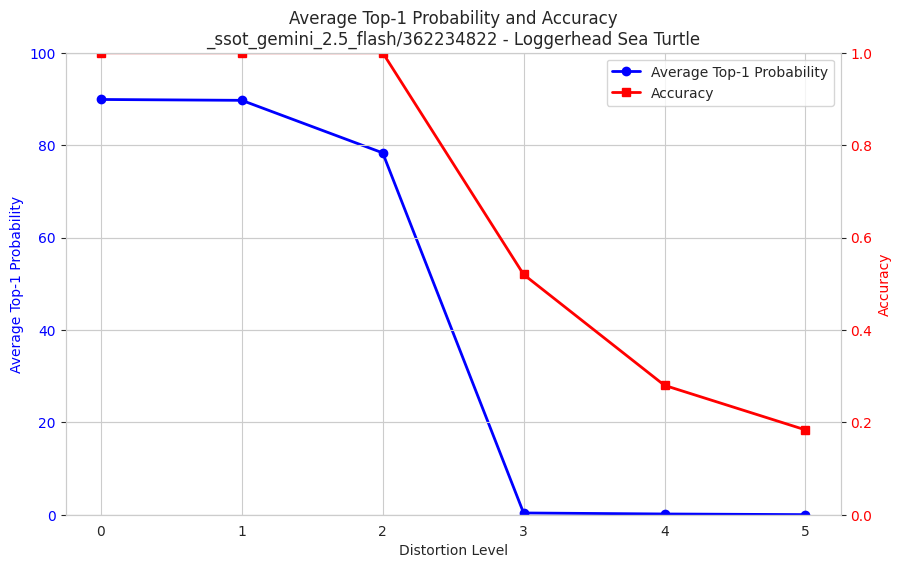





_cdrl_gemini_2.5_flash


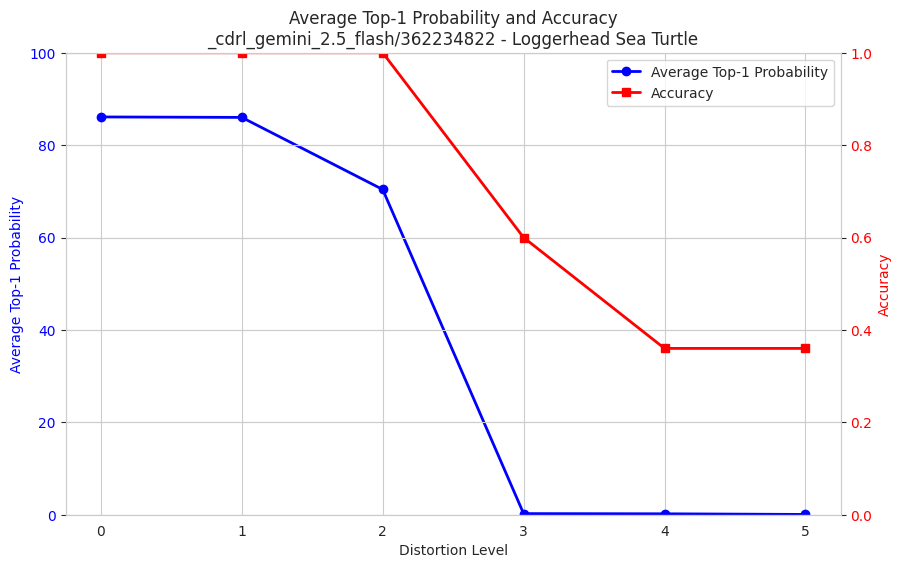





_far_gemini_2.5_flash


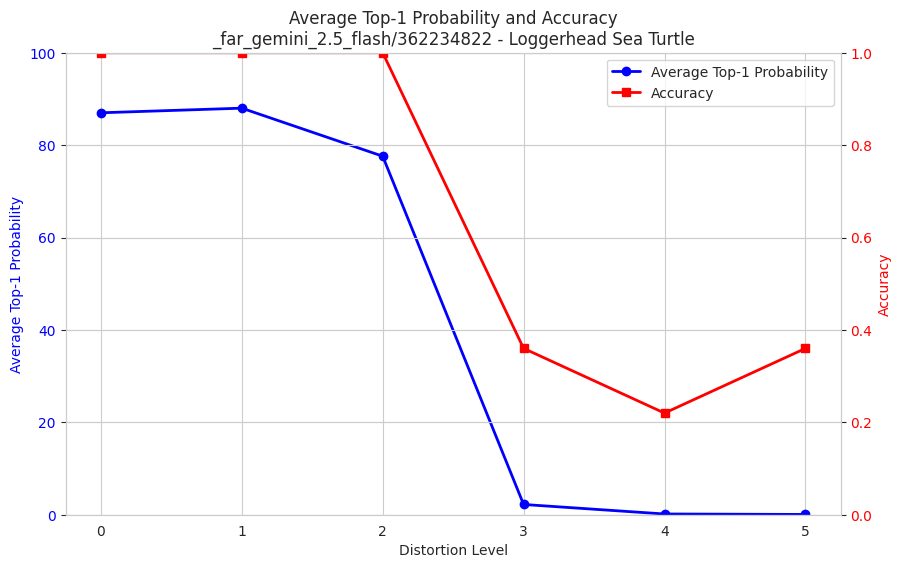





_cove_gemini_2.5_flash


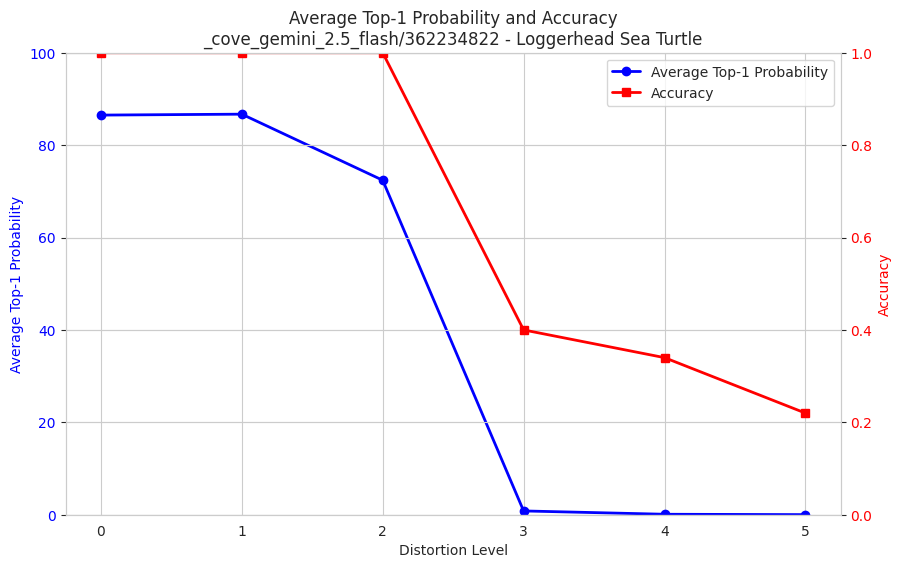





_best_gemini_2.5_flash


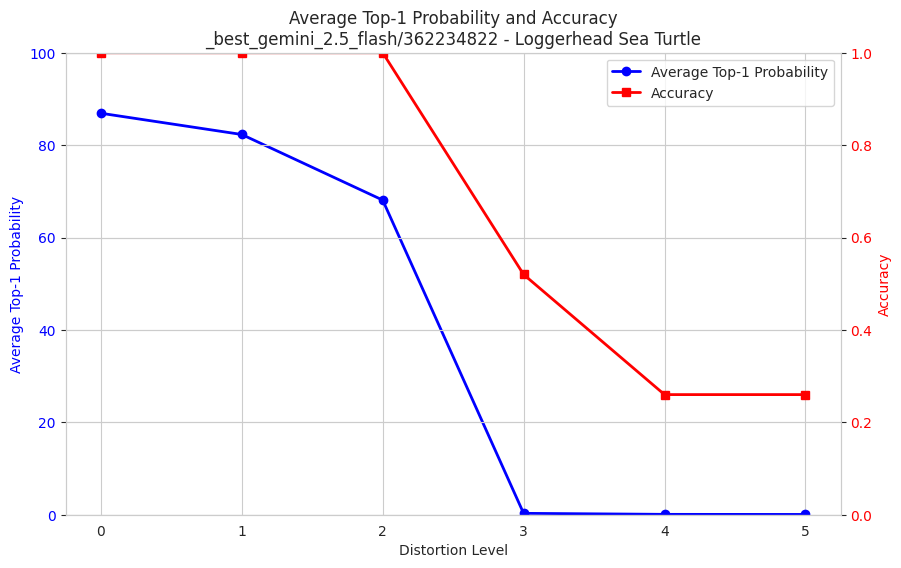





362471929
_baseline_gemini_2.5_flash


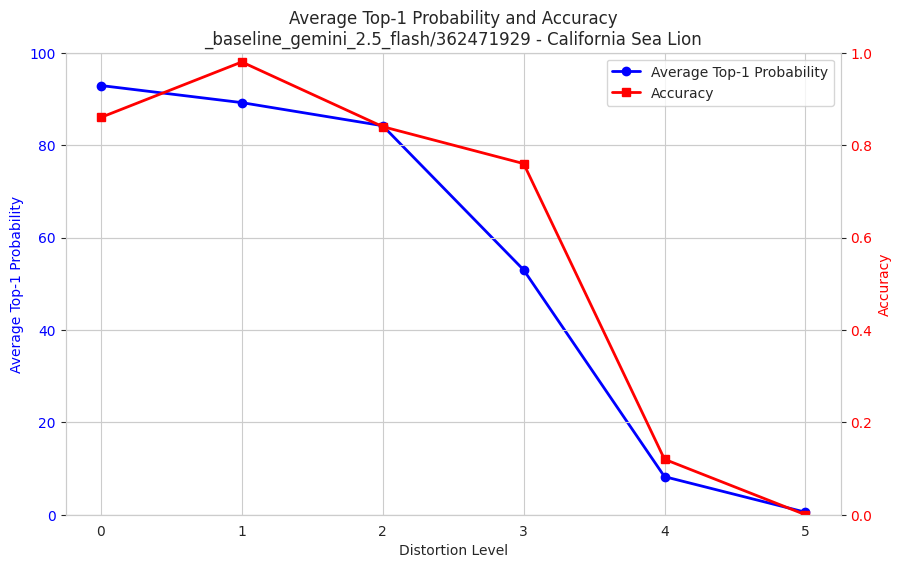





_metadata_gemini_2.5_flash


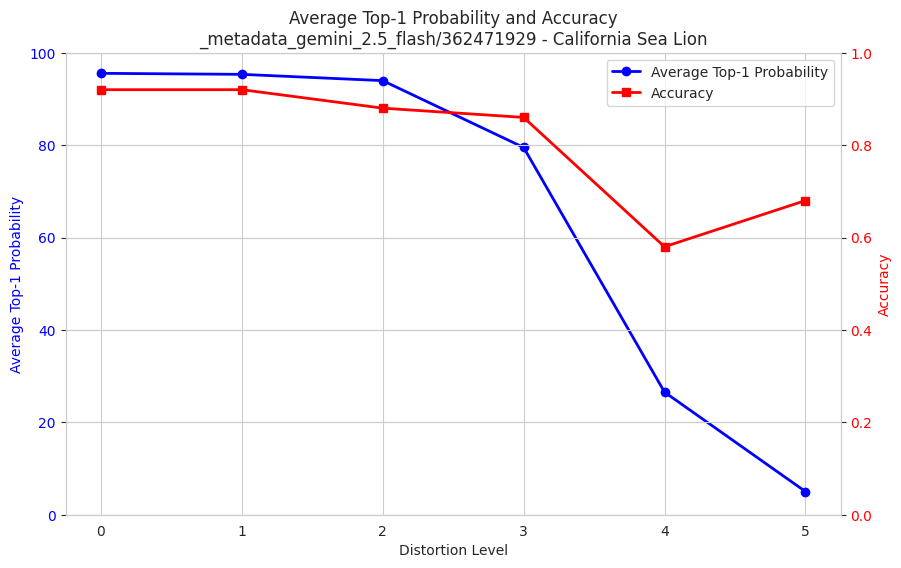





_ssot_gemini_2.5_flash


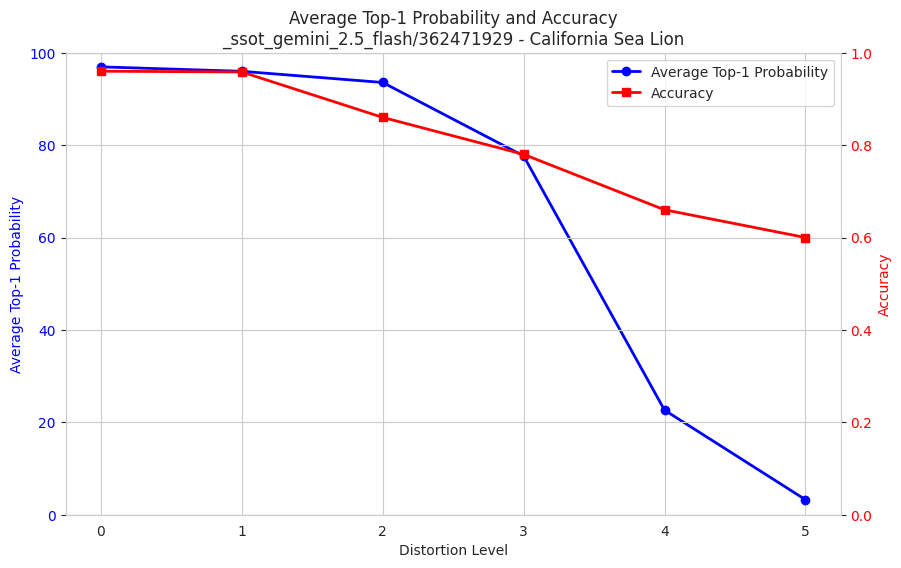





_cdrl_gemini_2.5_flash


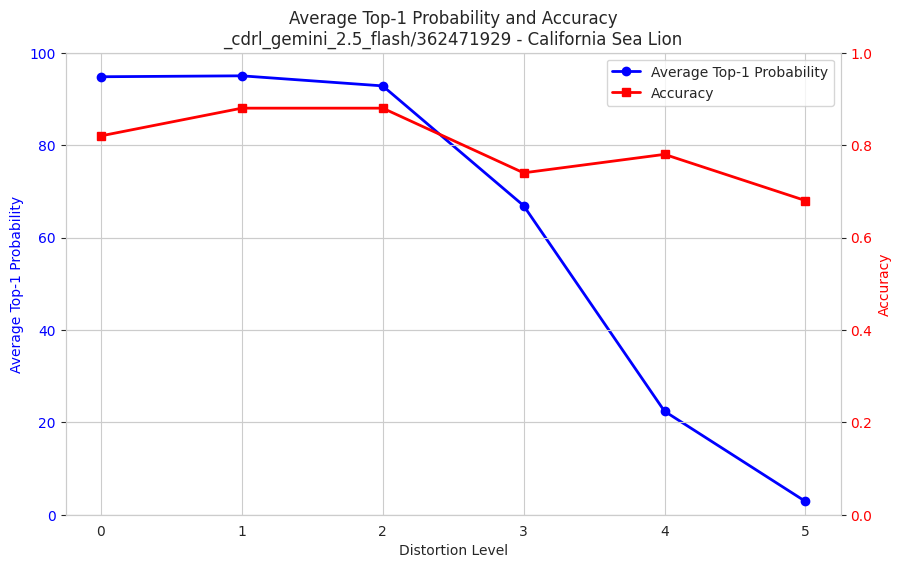





_far_gemini_2.5_flash


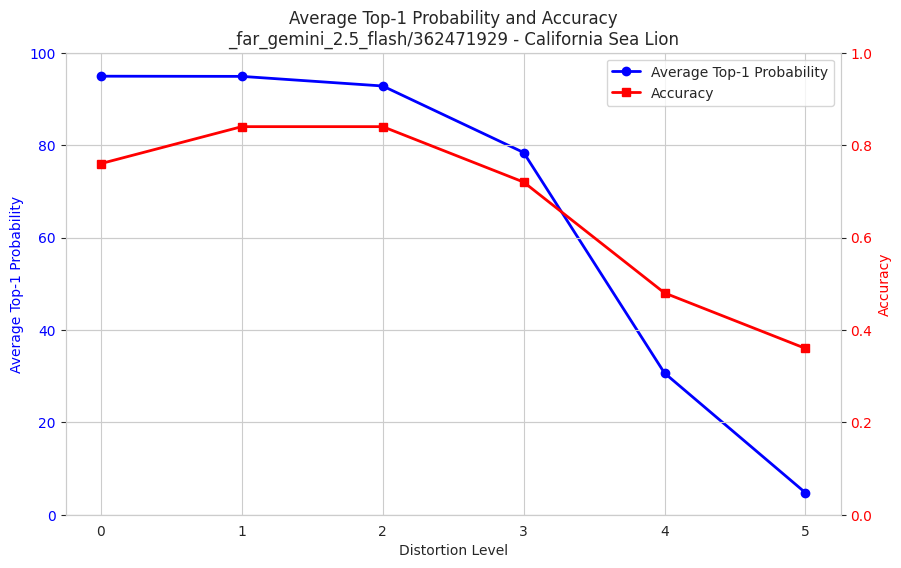





_cove_gemini_2.5_flash


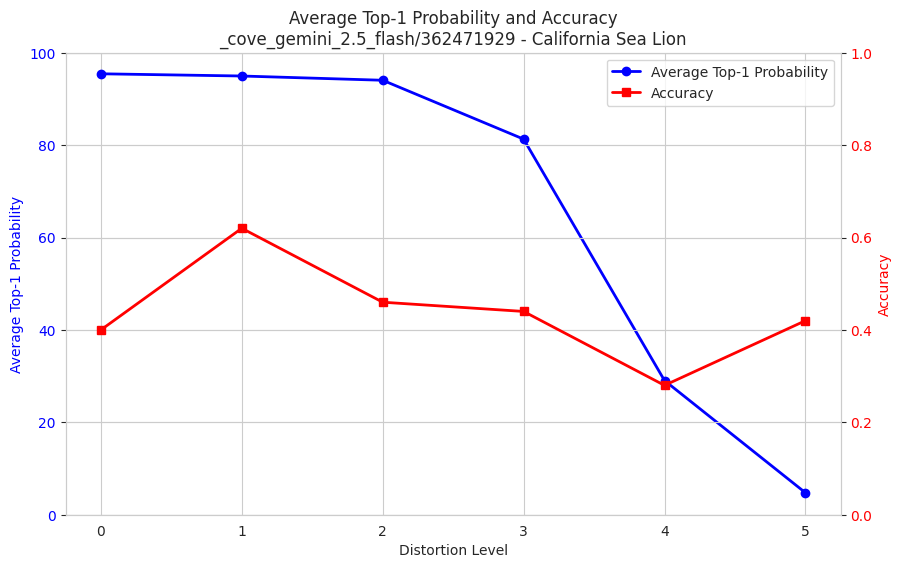





_best_gemini_2.5_flash


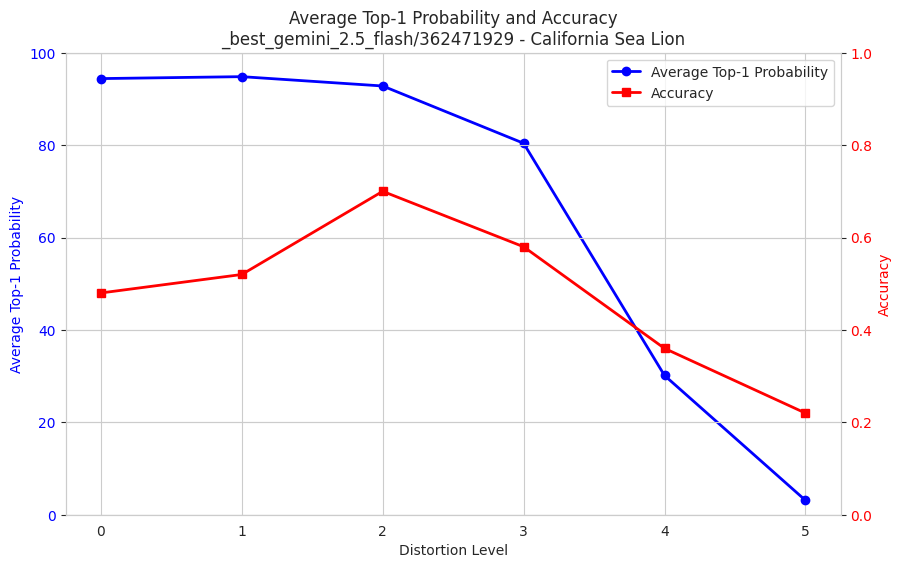





362424973
_baseline_gemini_2.5_flash


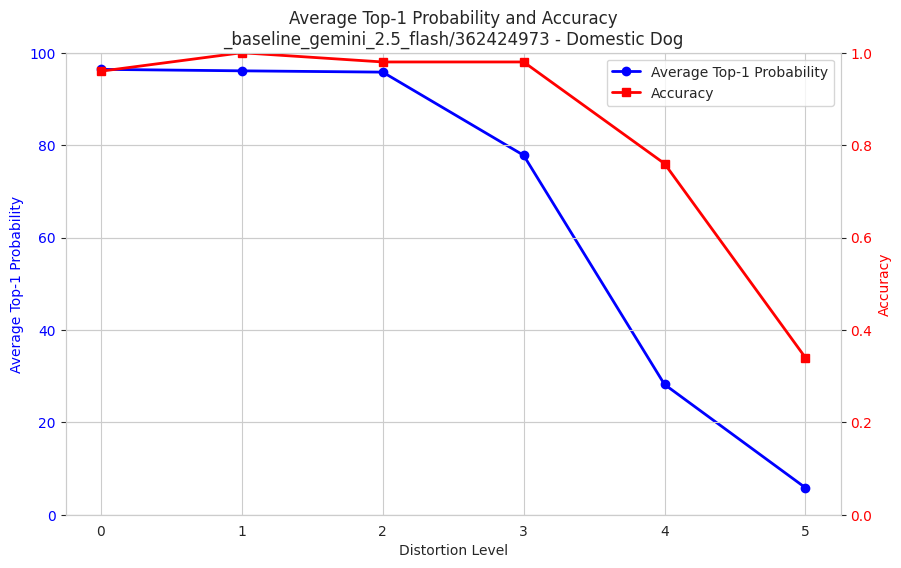





_metadata_gemini_2.5_flash


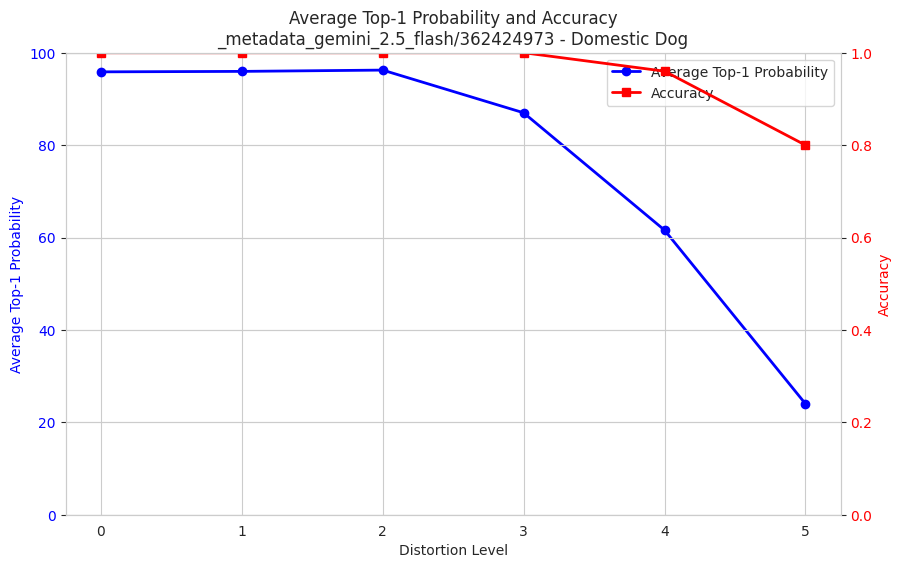





_ssot_gemini_2.5_flash


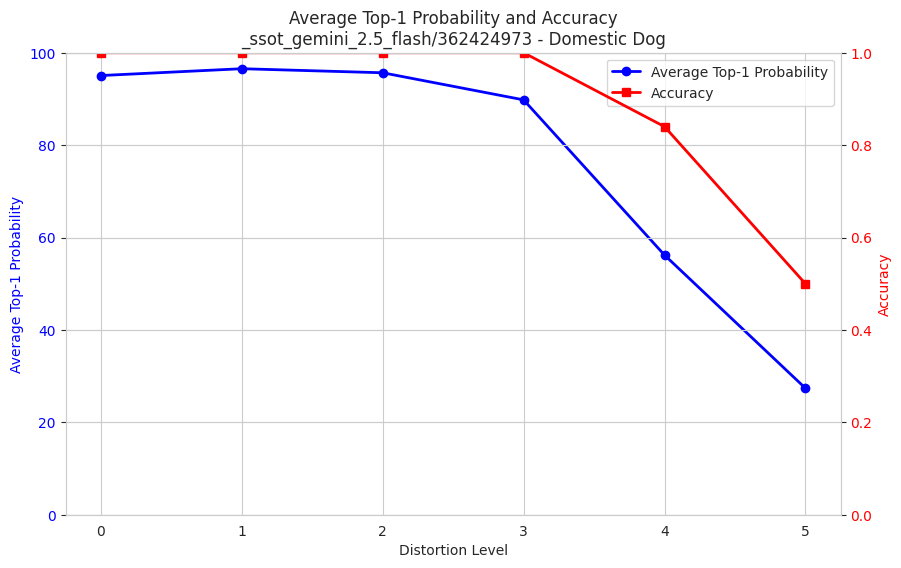





_cdrl_gemini_2.5_flash


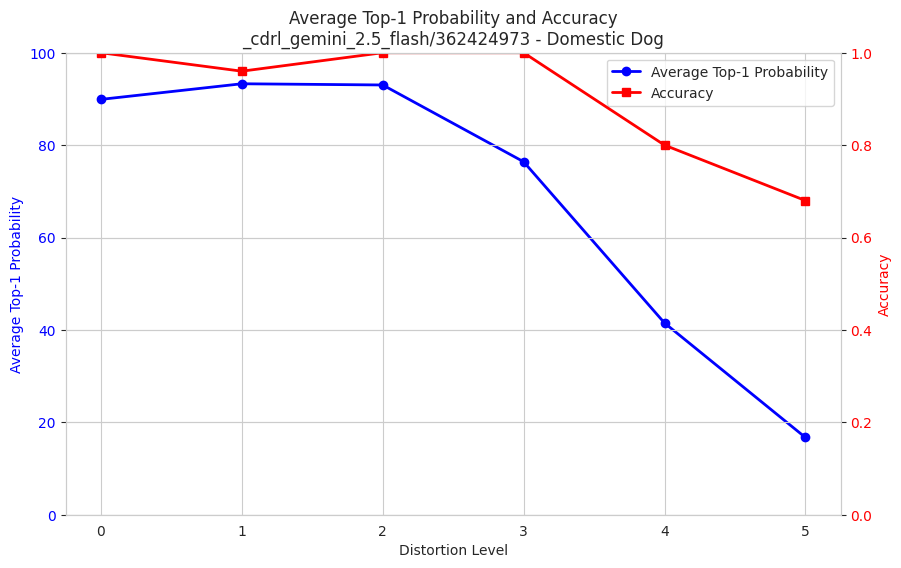





_far_gemini_2.5_flash


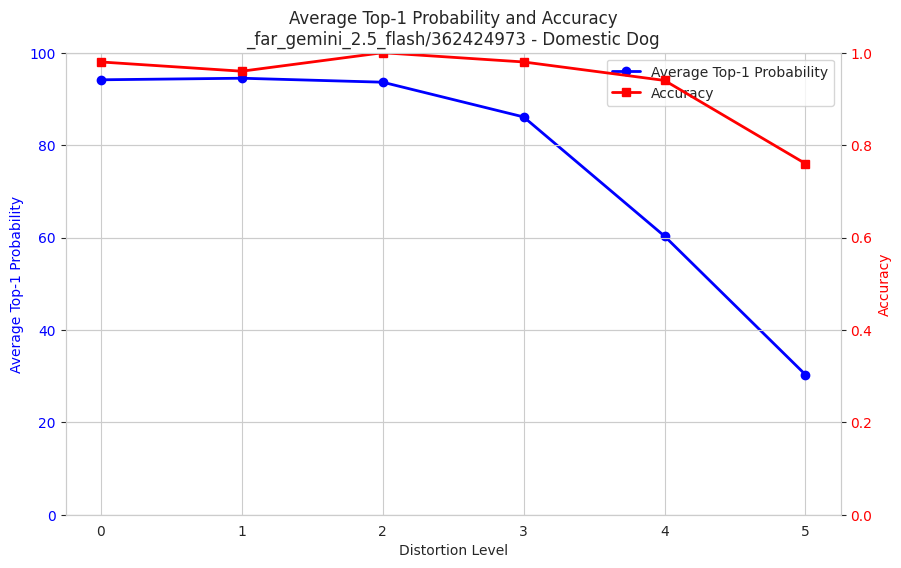





_cove_gemini_2.5_flash


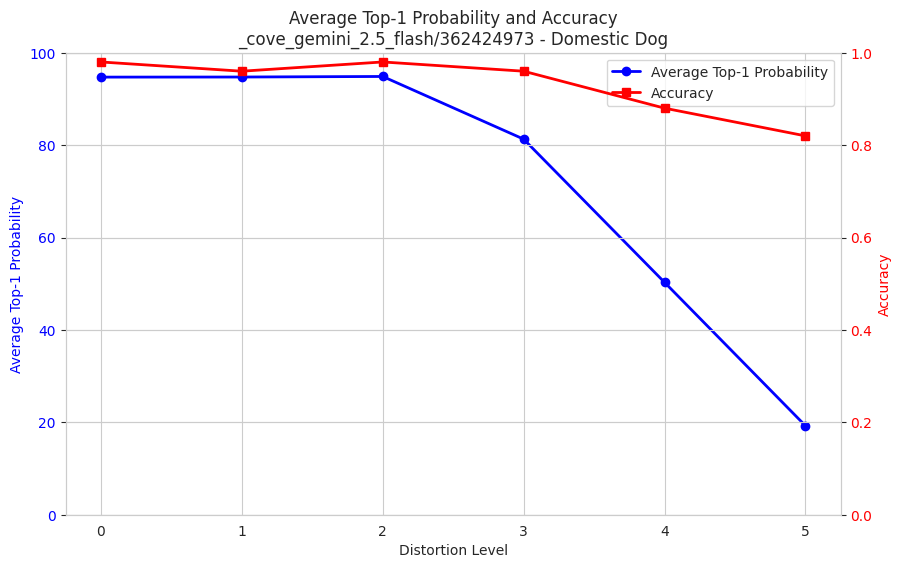





_best_gemini_2.5_flash


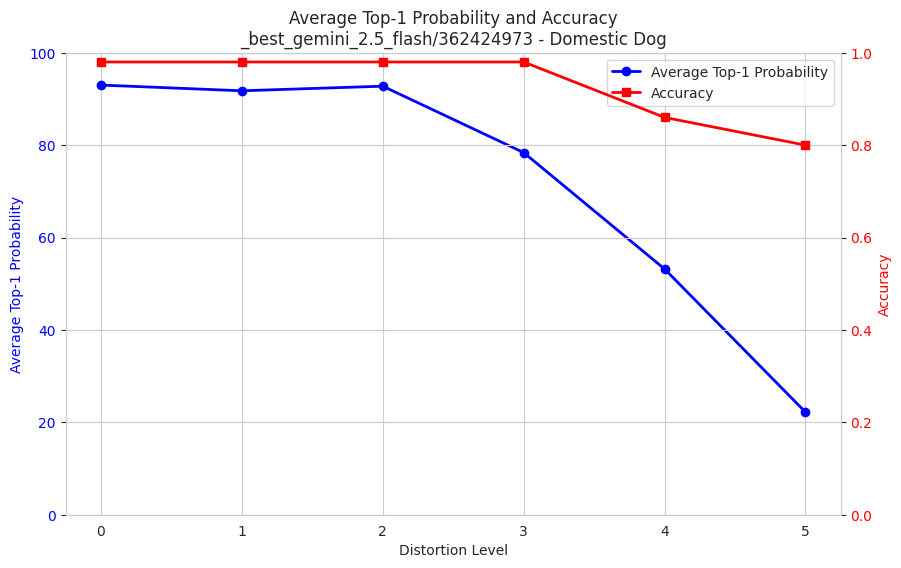





362588731
_baseline_gemini_2.5_flash


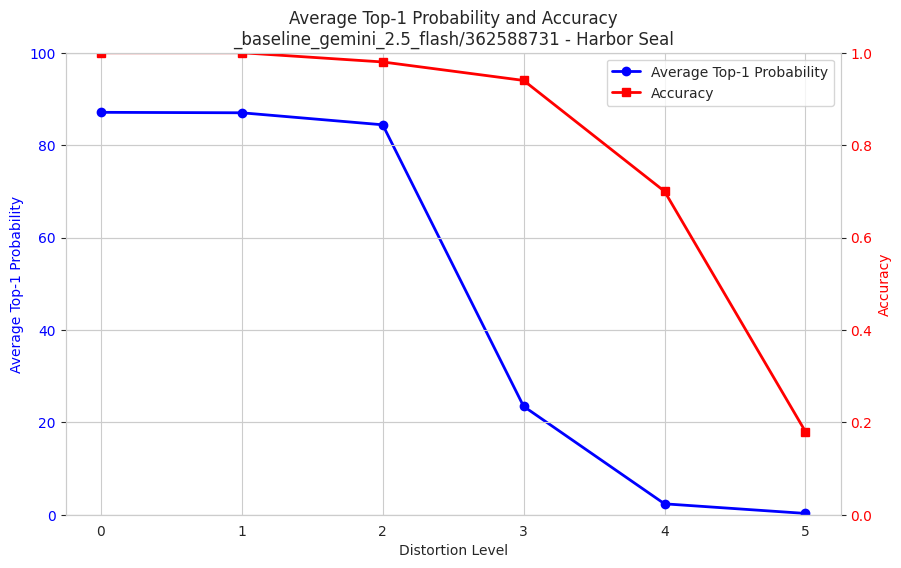





_metadata_gemini_2.5_flash


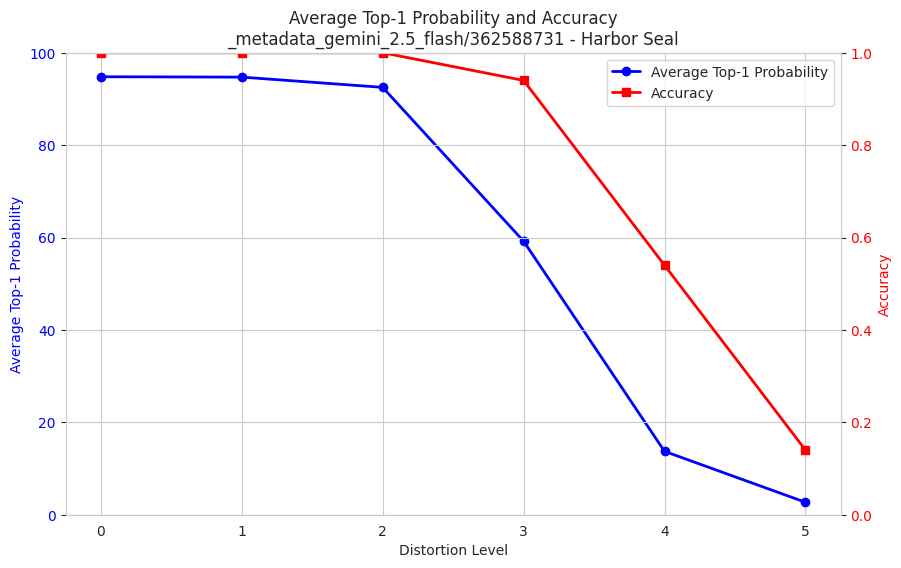





_ssot_gemini_2.5_flash


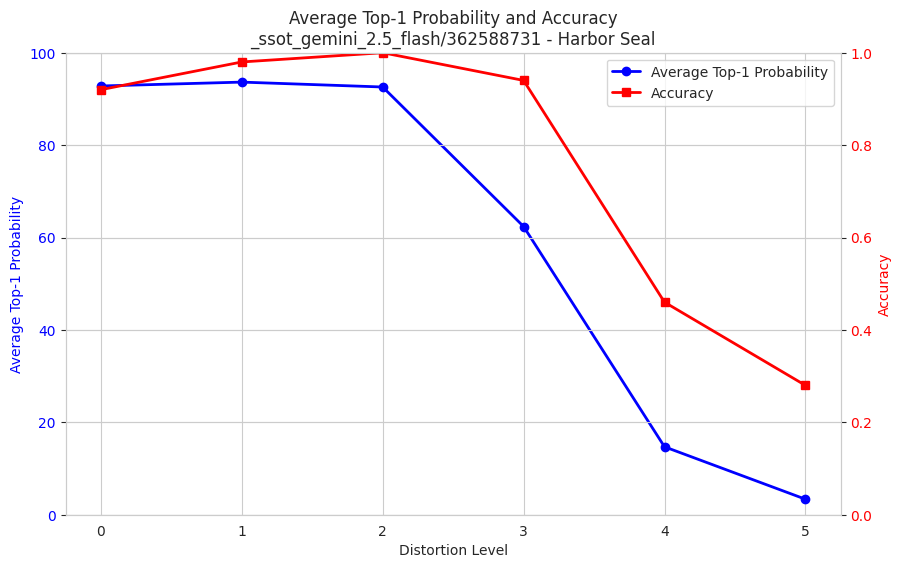





_cdrl_gemini_2.5_flash


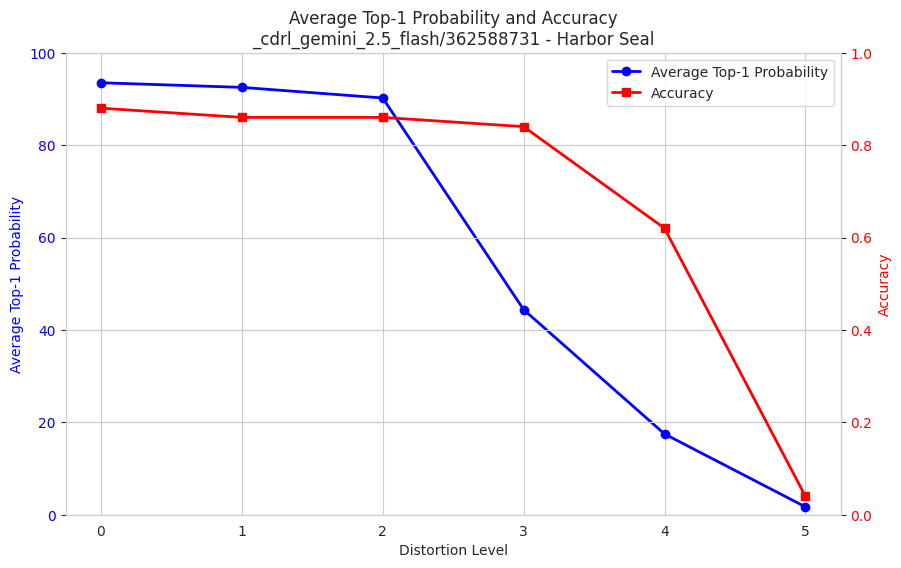





_far_gemini_2.5_flash


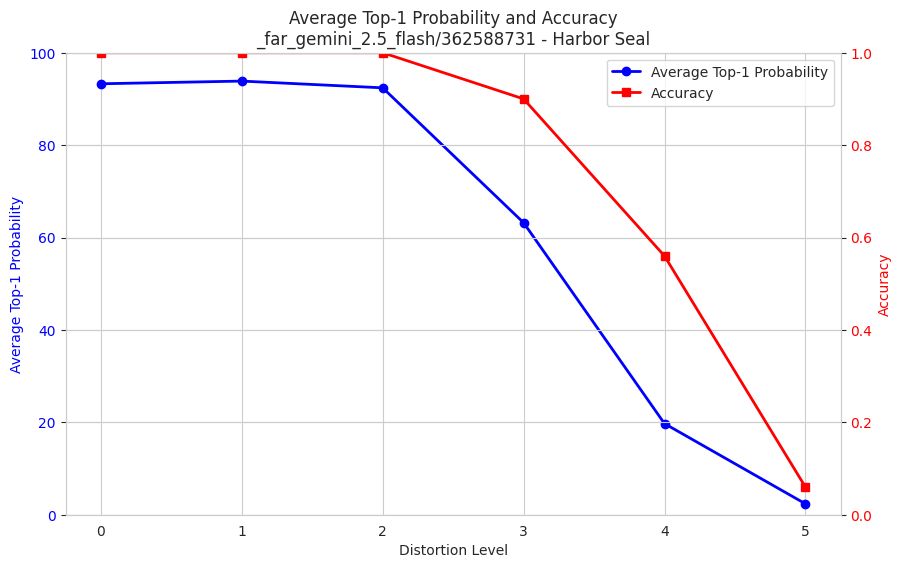





_cove_gemini_2.5_flash


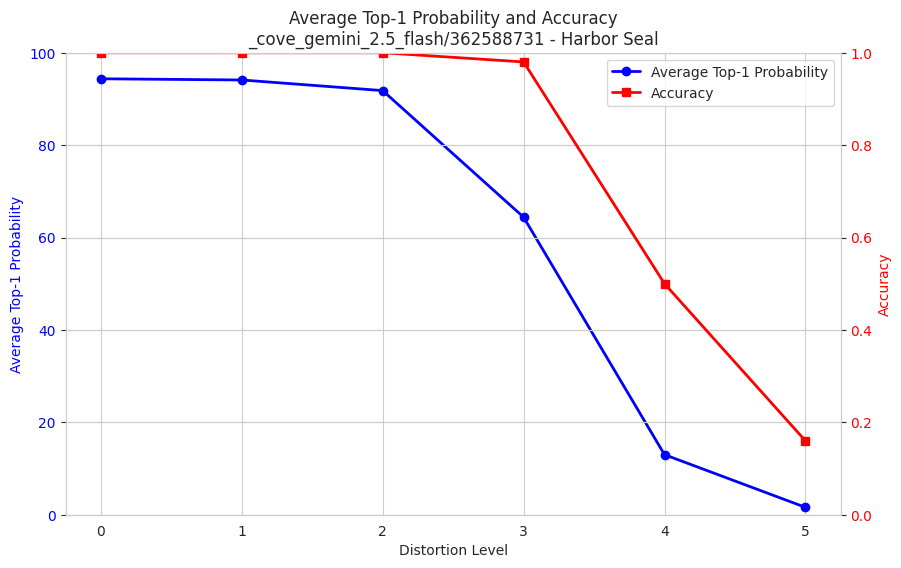





_best_gemini_2.5_flash


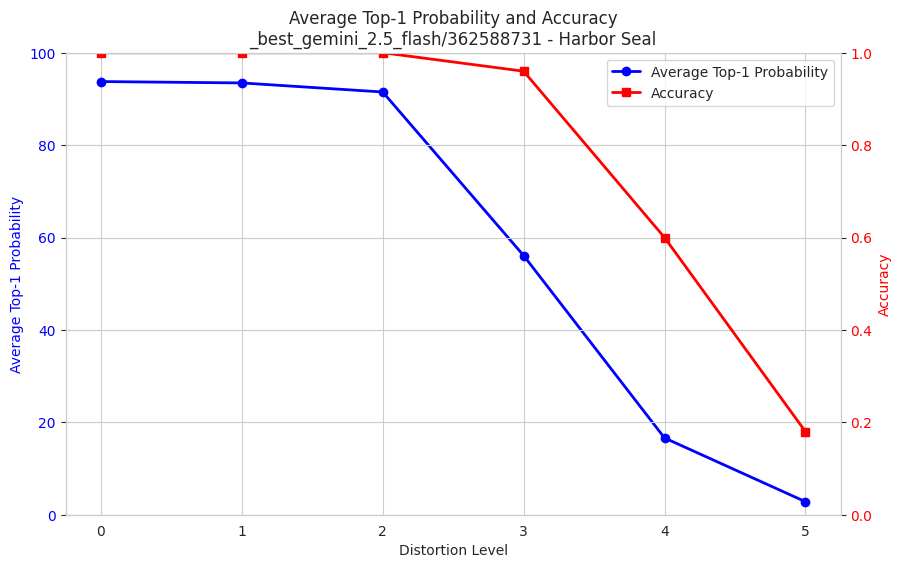

In [47]:
TARGET_IDS = [361231332, 362234822, 362471929, 362424973, 362588731]
folder_names = ['_baseline_gemini_2.5_flash', '_metadata_gemini_2.5_flash',  '_ssot_gemini_2.5_flash', '_cdrl_gemini_2.5_flash', '_far_gemini_2.5_flash', '_cove_gemini_2.5_flash', '_best_gemini_2.5_flash']
for i in TARGET_IDS:
    print(i)
    for folder in folder_names:
        print(folder)
        create_charts_line(f'{folder}/{i}_distribution_results.csv')
        print('\n')
        print('\n')

In [32]:
def all_hurt_images_analysis(file_path):
    df = pd.read_csv(file_path)
    df['top1_prob'] = pd.to_numeric(df['top1_prob'], errors='coerce')
    
    #for testing
    acceptable_matches = {
        ("zalophus californianus", "californianus"),
        ("mirounga angustirostris", "angustirostris"),
        ("caretta caretta", "caretta caretta"),
        ("caretta caretta", "chelonia mydas"),
        ("caretta caretta", "mydas"),
        ("delphinus delphis", "delphinus capensis"),
        ("delphinus delphis", "truncatus"),
        ("delphinus delphis", "capensis"),
        ("delphinus delphis", "delphis"),
        ("delphinus delphis", "lagenorhynchus albirostris"),
        ("delphinus delphis", "phocoena phocoena"),
        ("delphinus delphis", "tursiops truncatus"),
        ("delphinus delphis", "stenella longirostris"),
        ("canis familiaris", "familiaris"),
        ("canis familiaris", "canis lupus familiaris"),
        ("castor canadensis", "canadensis"),
        ("odocoileus virginianus", "virginianus"),
        ("haemorhous mexicanus", "mexicanus"),
        ("canis latrans", "latrans"),
    }
    
    # Normalize
    actual = df["actual_species"].astype(str).str.lower().str.strip()
    pred = df["top1_species"].astype(str).str.lower().str.strip()
    
    # Accuracy check
    df["accurate"] = [
        (a == p) or ((a, p) in acceptable_matches)
        for a, p in zip(actual, pred)
    ]
    
    # Drop missing
    df = df.dropna(subset=["distortion_level", "top1_prob"])
    
    # Create output folder
    OUTPUT_DIR = Path("charts_all_images")
    OUTPUT_DIR.mkdir(exist_ok=True)
    
    sns.set_style("whitegrid")
    
    # =====================================================
    # 1. OVERALL LINE PLOT
    # =====================================================
    
    summary = (
        df.groupby("distortion_level")
        .agg(
            accuracy=("accurate", "mean"),
            avg_confidence=("top1_prob", "mean")
        )
        .reset_index()
        .sort_values("distortion_level")
    )
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # =====================================================
    # LEFT AXIS = CONFIDENCE (BLUE)
    # =====================================================
    
    line1 = ax1.plot(
        summary["distortion_level"],
        summary["avg_confidence"],
        marker="s",
        linewidth=2,
        color="blue",
        label="Average Confidence"
    )
    
    ax1.set_xlabel("Distortion Level")
    ax1.set_ylabel("Average Confidence", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    
    ax1.set_ylim(0, 100)
    ax1.set_xlim(0, 5)
    ax1.set_xticks(range(0, 5))
    
    # =====================================================
    # RIGHT AXIS = ACCURACY (RED)
    # =====================================================
    
    ax2 = ax1.twinx()
    
    line2 = ax2.plot(
        summary["distortion_level"],
        summary["accuracy"] * 100,
        marker="o",
        linewidth=2,
        color="red",
        label="Accuracy"
    )
    
    ax2.set_ylabel("Accuracy (%)", color="red")
    ax2.tick_params(axis="y", labelcolor="red")
    
    ax2.set_ylim(0, 100)
    
    # =====================================================
    # LEGEND
    # =====================================================
    
    lines = line1 + line2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="best")
    
    ax1.legend(lines, labels, loc="best")
    
    plt.title("Accuracy and Average Confidence by Distortion Level")
    
    # plt.savefig(
    #     OUTPUT_DIR / "overall_accuracy_confidence.png",
    #     dpi=300,
    #     bbox_inches="tight"
    # )
    
    plt.show()
    
    plt.close()
    
    # # =====================================================
    # # 2. ONE CHART PER actual_name
    # # =====================================================
    
    # species_list = sorted(df["actual_name"].dropna().unique())
    
    # for species in species_list:
    
    #     species_df = df[df["actual_name"] == species]
    
    #     # Skip if empty
    #     if len(species_df) == 0:
    #         continue
    
    #     summary = (
    #         species_df.groupby("distortion_level")
    #         .agg(
    #             accuracy=("accurate", "mean"),
    #             avg_confidence=("top1_prob", "mean")
    #         )
    #         .reset_index()
    #         .sort_values("distortion_level")
    #     )
    
    #     fig, ax1 = plt.subplots(figsize=(10, 6))
    
    #     # =====================================================
    #     # LEFT AXIS = CONFIDENCE (BLUE)
    #     # =====================================================
        
    #     line1 = ax1.plot(
    #         summary["distortion_level"],
    #         summary["avg_confidence"],
    #         marker="s",
    #         linewidth=2,
    #         color="blue",
    #         label="Average Confidence"
    #     )
        
    #     ax1.set_xlabel("Distortion Level")
    #     ax1.set_ylabel("Average Confidence", color="blue")
    #     ax1.tick_params(axis="y", labelcolor="blue")
        
    #     ax1.set_ylim(0, 100)
    #     ax1.set_xlim(0, 5)
    #     ax1.set_xticks(range(0, 5))
        
    #     # =====================================================
    #     # RIGHT AXIS = ACCURACY (RED)
    #     # =====================================================
        
    #     ax2 = ax1.twinx()
        
    #     line2 = ax2.plot(
    #         summary["distortion_level"],
    #         summary["accuracy"] * 100,
    #         marker="o",
    #         linewidth=2,
    #         color="red",
    #         label="Accuracy"
    #     )
        
    #     ax2.set_ylabel("Accuracy (%)", color="red")
    #     ax2.tick_params(axis="y", labelcolor="red")
        
    #     ax2.set_ylim(0, 100)
        
    #     # =====================================================
    #     # LEGEND
    #     # =====================================================
        
    #     lines = line1 + line2
    #     labels = [line.get_label() for line in lines]
    #     ax1.legend(lines, labels, loc="best")
    
    #     plt.title(f"{species}\nAccuracy and Confidence by Distortion Level")
    
    #     # Safe filename
    #     safe_name = (
    #         species.replace(" ", "_")
    #         .replace("/", "_")
    #     )
    
    #     # plt.savefig(
    #     #     OUTPUT_DIR / f"{safe_name}_accuracy_confidence.png",
    #     #     dpi=300,
    #     #     bbox_inches="tight"
    #     # )
    
    #     plt.show()
    
    #     plt.close()
    
    # print("Done.")

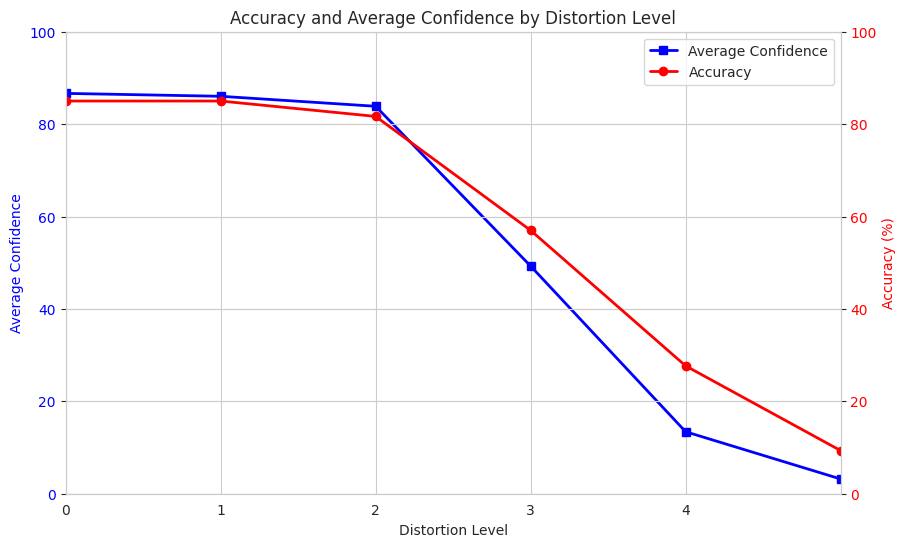

In [35]:
all_hurt_images_analysis('_baseline_gemini_2.5_flash/all_images_distortion_results.csv')

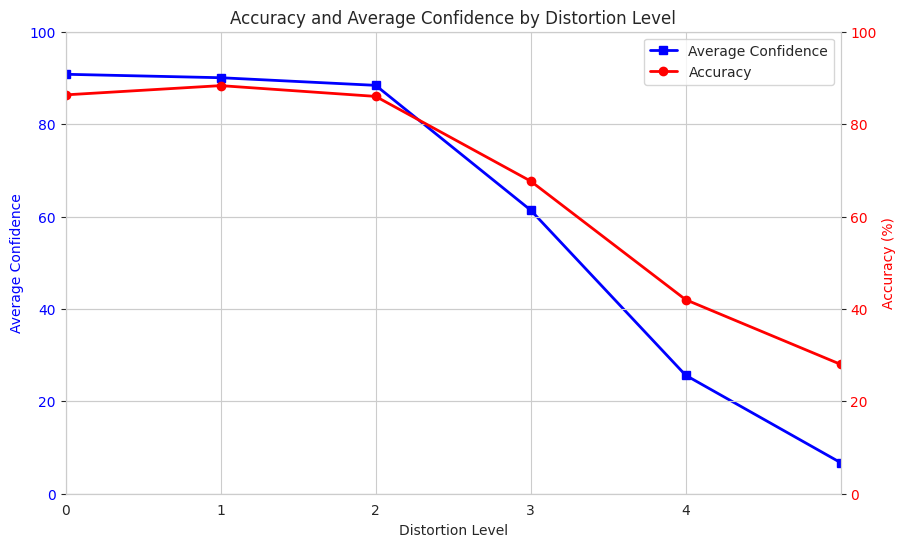

In [36]:
all_hurt_images_analysis('_metadata_gemini_2.5_flash/all_images_distortion_results.csv')

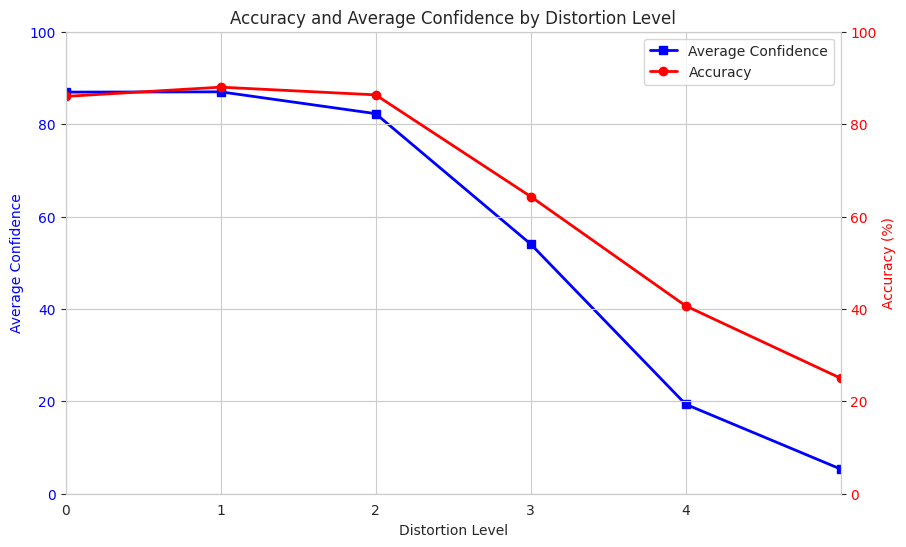

In [37]:
all_hurt_images_analysis('_cdrl_gemini_2.5_flash/all_images_distortion_results.csv')

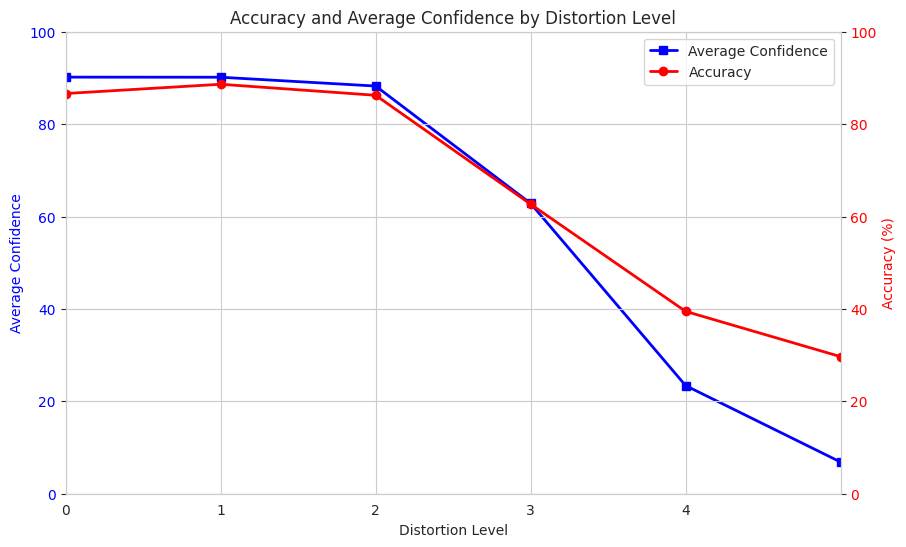

In [38]:
all_hurt_images_analysis('_ssot_gemini_2.5_flash/all_images_distortion_results.csv')

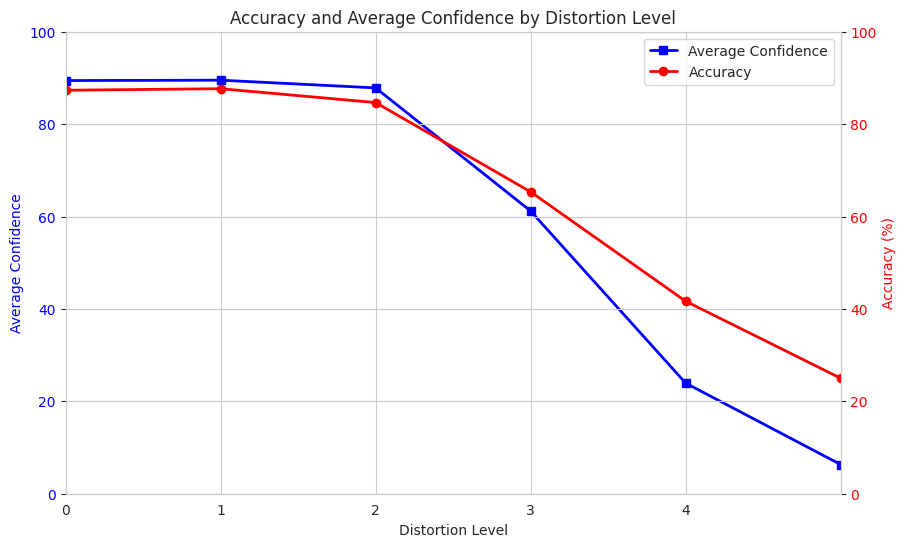

In [39]:
all_hurt_images_analysis('_cove_gemini_2.5_flash/all_images_distortion_results.csv')

_baseline_gemini_2.5_flash


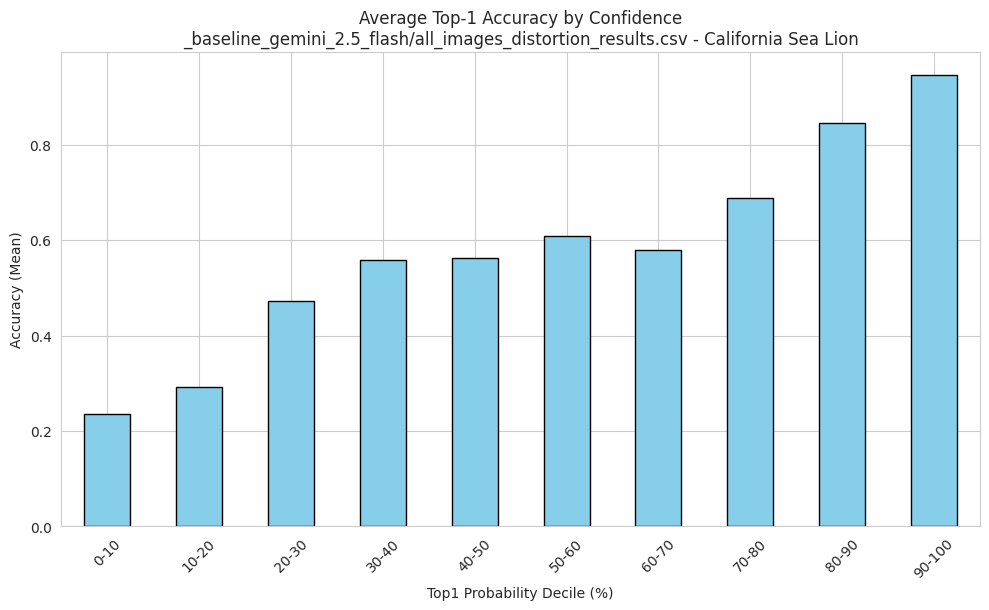





_metadata_gemini_2.5_flash


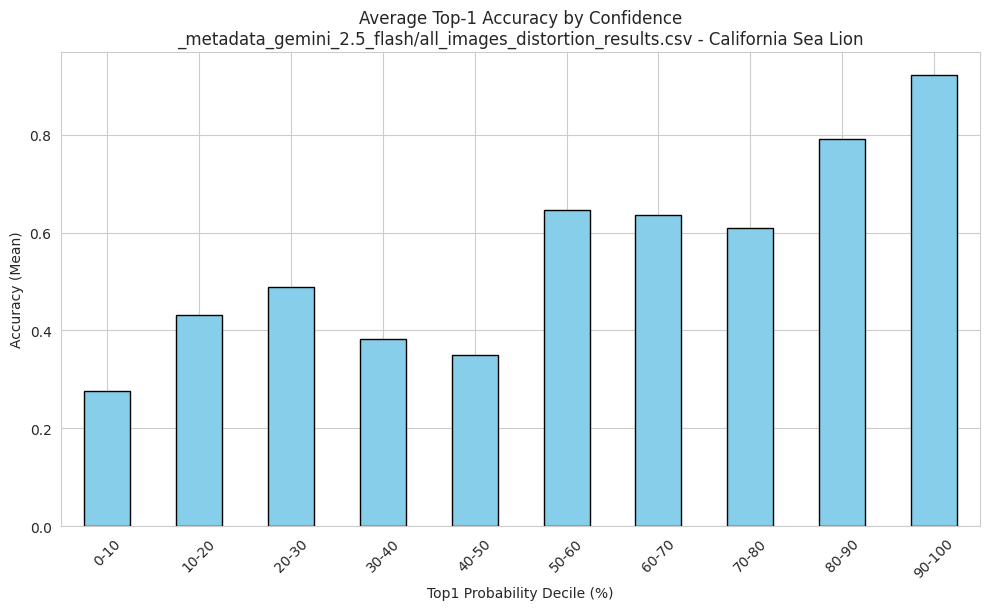





_ssot_gemini_2.5_flash


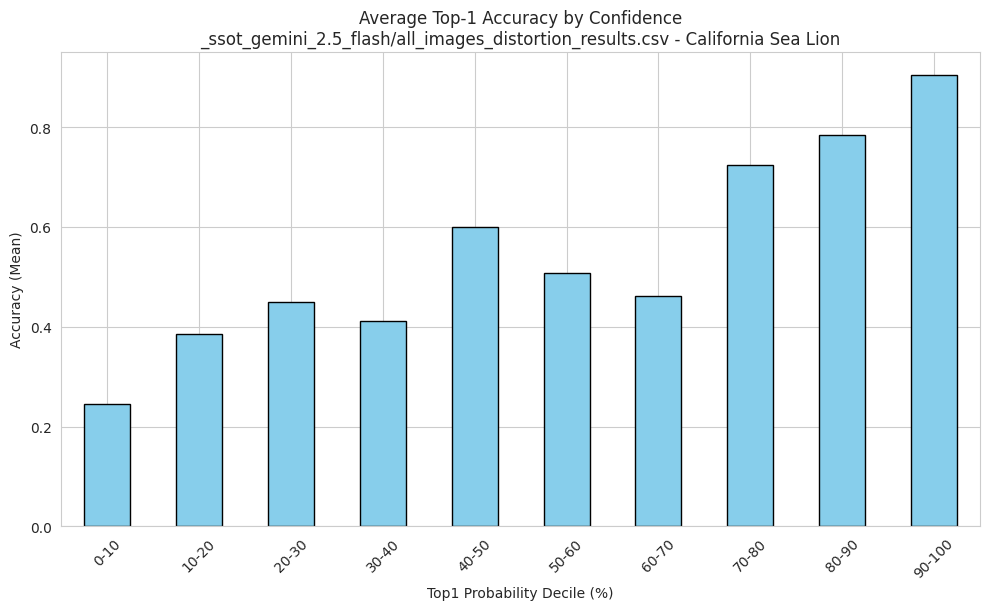





_cdrl_gemini_2.5_flash


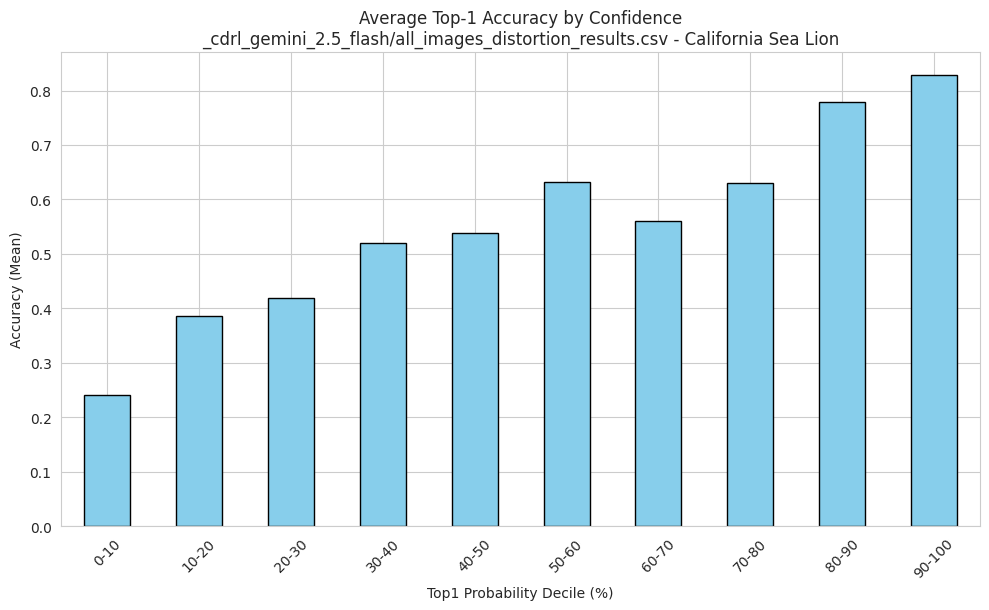





_far_gemini_2.5_flash


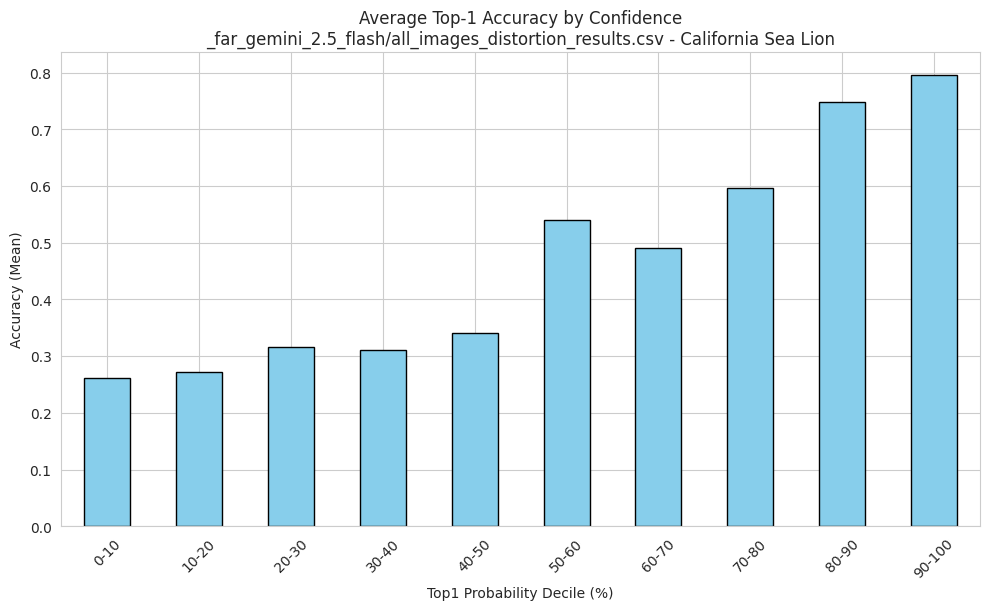





_cove_gemini_2.5_flash


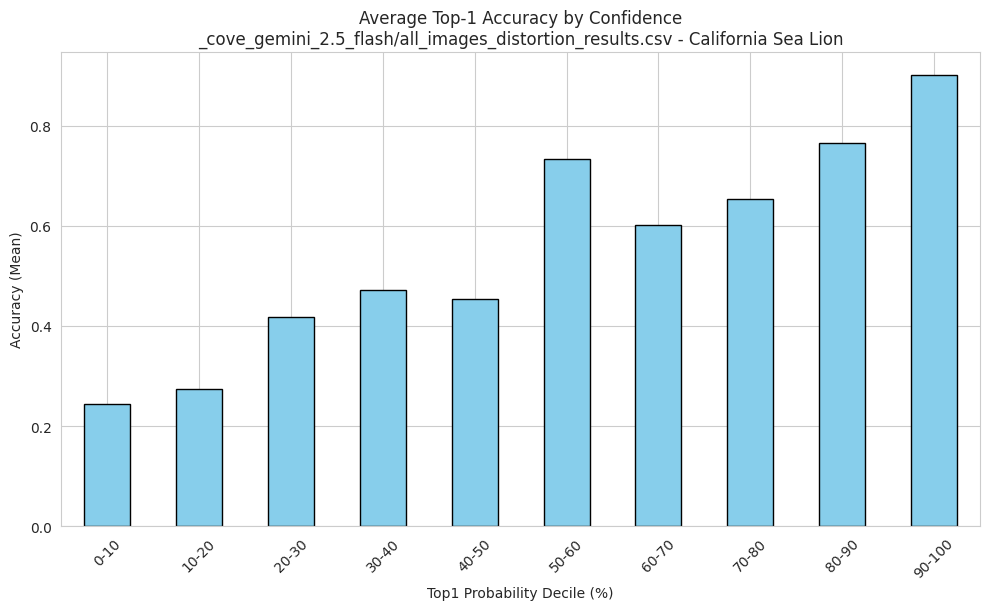

In [62]:

folder_names = ['_baseline_gemini_2.5_flash', '_metadata_gemini_2.5_flash',  '_ssot_gemini_2.5_flash', '_cdrl_gemini_2.5_flash', '_far_gemini_2.5_flash', '_cove_gemini_2.5_flash']
for folder in folder_names:
    print(folder)
    create_charts_accuracy(f'{folder}/all_images_distortion_results.csv')
    print('\n')
    print('\n')